# Domain Construction

## Loading

In [14]:
import sys
import os
from pathlib import Path

import pandas as pd

sys.path.append(os.path.abspath("../../../"))
PROJECT_ROOT = Path("../../../").resolve()

import preprocessing.general.feature_extraction as fe


# ============================================================
# General configuration
# ============================================================

ELECTRODE_SETUP = "setup_01"

METADATA_COLUMNS = [
    "dataset",
    "subject",
    "session",
    "trial_index",
    "label",
]

TRIAL_IDENTIFIER_COLUMNS = [
    "dataset",
    "subject",
    "session",
    "trial_index",
]


# ============================================================
# Input paths
# ============================================================

bci_csv = (
    PROJECT_ROOT
    / "Datasets/MotorImagery/processed"
    / f"bci_features_{ELECTRODE_SETUP}.csv"
)

physionet_csv = (
    PROJECT_ROOT
    / "Datasets/EEG Motor Movement/processed"
    / f"EEG_MM_features_{ELECTRODE_SETUP}.csv"
)


# ============================================================
# Check files
# ============================================================

if not bci_csv.exists():
    raise FileNotFoundError(
        f"BCI feature file not found: {bci_csv}"
    )

if not physionet_csv.exists():
    raise FileNotFoundError(
        f"PhysioNet feature file not found: {physionet_csv}"
    )


# ============================================================
# Load datasets
# ============================================================

bci_df = pd.read_csv(bci_csv)
physionet_df = pd.read_csv(physionet_csv)

print(f"BCI shape: {bci_df.shape}")
print(f"PhysioNet shape: {physionet_df.shape}")


# ============================================================
# Validate individual datasets
# ============================================================

fe.validate_feature_dataframe(bci_df)
fe.validate_feature_dataframe(physionet_df)

if set(bci_df["dataset"].unique()) != {"bci_iv_2a"}:
    raise ValueError(
        "Unexpected dataset identifier in the BCI CSV: "
        f"{bci_df['dataset'].unique().tolist()}"
    )

if set(physionet_df["dataset"].unique()) != {"eegmmidb"}:
    raise ValueError(
        "Unexpected dataset identifier in the PhysioNet CSV: "
        f"{physionet_df['dataset'].unique().tolist()}"
    )

print("✅ Individual dataset validation passed.")


# ============================================================
# Identify feature columns
# ============================================================

bci_feature_columns = [
    column
    for column in bci_df.columns
    if column not in METADATA_COLUMNS
]

physionet_feature_columns = [
    column
    for column in physionet_df.columns
    if column not in METADATA_COLUMNS
]

common_feature_columns = [
    column
    for column in bci_feature_columns
    if column in physionet_feature_columns
]

bci_only_feature_columns = [
    column
    for column in bci_feature_columns
    if column not in physionet_feature_columns
]

physionet_only_feature_columns = [
    column
    for column in physionet_feature_columns
    if column not in bci_feature_columns
]


# ============================================================
# Report feature compatibility
# ============================================================

print("\nFeature schema")
print(f"BCI features: {len(bci_feature_columns)}")
print(
    f"PhysioNet features: "
    f"{len(physionet_feature_columns)}"
)
print(f"Common features: {len(common_feature_columns)}")
print(
    f"BCI-only features: "
    f"{len(bci_only_feature_columns)}"
)
print(
    f"PhysioNet-only features: "
    f"{len(physionet_only_feature_columns)}"
)

if bci_only_feature_columns:
    print(
        "BCI-only examples:",
        bci_only_feature_columns[:10],
    )

if physionet_only_feature_columns:
    print(
        "PhysioNet-only examples:",
        physionet_only_feature_columns[:10],
    )


# ============================================================
# Create union of feature columns
# ============================================================

feature_columns = bci_feature_columns.copy()

feature_columns.extend([
    column
    for column in physionet_feature_columns
    if column not in feature_columns
])


# ============================================================
# Merge datasets
# ============================================================

combined_df = pd.concat(
    [
        bci_df,
        physionet_df,
    ],
    ignore_index=True,
    sort=False,
)

# Missing features from one dataset remain NaN.
combined_df = combined_df[
    METADATA_COLUMNS + feature_columns
]


# ============================================================
# Validate merged metadata
# ============================================================

if combined_df[METADATA_COLUMNS].isna().any().any():
    invalid_columns = (
        combined_df[METADATA_COLUMNS]
        .columns[
            combined_df[METADATA_COLUMNS]
            .isna()
            .any()
        ]
        .tolist()
    )

    raise ValueError(
        "Missing metadata after merging in columns: "
        f"{invalid_columns}"
    )

duplicate_trials = combined_df.duplicated(
    subset=TRIAL_IDENTIFIER_COLUMNS,
    keep=False,
)

if duplicate_trials.any():
    examples = (
        combined_df.loc[
            duplicate_trials,
            TRIAL_IDENTIFIER_COLUMNS,
        ]
        .drop_duplicates()
        .head(10)
        .to_dict("records")
    )

    raise ValueError(
        "Duplicated trial identifiers after merging. "
        f"Examples: {examples}"
    )


# ============================================================
# Report merged data
# ============================================================

print(
    f"\n✅ Combined dataset created: "
    f"{combined_df.shape}"
)

print(
    f"✅ Datasets: "
    f"{combined_df['dataset'].unique().tolist()}"
)

print(
    f"✅ Total subjects: "
    f"{combined_df.groupby('dataset')['subject'].nunique().sum()}"
)

display(combined_df.head())

BCI shape: (5184, 95)
PhysioNet shape: (19673, 95)
✅ Individual dataset validation passed.

Feature schema
BCI features: 90
PhysioNet features: 90
Common features: 90
BCI-only features: 0
PhysioNet-only features: 0

✅ Combined dataset created: (24857, 95)
✅ Datasets: ['bci_iv_2a', 'eegmmidb']
✅ Total subjects: 118


,dataset,subject,session,trial_index,label,b8_12_mean_C3,b8_12_mean_Cz,b8_12_mean_C4,b8_12_std_C3,b8_12_std_Cz,...,b13_30_q_1_C4,b13_30_q_2_C3,b13_30_q_2_Cz,b13_30_q_2_C4,b13_30_q_3_C3,b13_30_q_3_Cz,b13_30_q_3_C4,b13_30_logvar_C3,b13_30_logvar_Cz,b13_30_logvar_C4
0,bci_iv_2a,A01,session_01,0,tongue_imagery,6.628982e-09,-2.770257e-08,8.171160e-10,0.000002,0.000003,...,2.083999e-08,3.014338e-08,3.604521e-08,-2.125241e-08,-5.205597e-09,-2.993853e-08,-3.390606e-08,-25.160662,-24.961687,-25.039858
1,bci_iv_2a,A01,session_01,1,both_feet_imagery,5.556458e-08,5.848129e-08,5.225703e-08,0.000004,0.000004,...,8.526831e-08,-1.014640e-08,-3.665703e-08,-2.253099e-08,8.930448e-08,1.509851e-07,1.000519e-07,-25.358910,-25.109524,-24.992792
2,bci_iv_2a,A01,session_01,2,right_hand_imagery,4.961544e-09,1.173579e-08,2.111302e-08,0.000002,0.000003,...,6.735552e-08,-5.209813e-09,-5.477280e-09,2.947687e-08,-1.845828e-08,-1.485296e-08,-1.963981e-08,-25.272942,-25.033789,-25.192879
3,bci_iv_2a,A01,session_01,3,left_hand_imagery,-8.338073e-08,-6.672642e-08,-3.774150e-08,0.000003,0.000003,...,5.061478e-08,-9.388884e-09,-5.350012e-08,-4.387143e-08,-2.301171e-08,1.181291e-08,6.863667e-11,-25.134298,-25.061962,-25.328821
4,bci_iv_2a,A01,session_01,4,left_hand_imagery,3.510155e-09,-8.964781e-09,-6.915561e-09,0.000002,0.000002,...,-2.910713e-08,-5.453906e-08,-9.668239e-08,-2.637220e-08,7.831463e-08,1.139543e-07,1.991119e-08,-25.495483,-25.204264,-25.121435


## Filtering

In [15]:
# ============================================================
# Initial data filters
# ============================================================

# None means that no filter is applied.
# Values may be scalars or lists.
DATA_FILTERS = {
    "dataset": None,
    "subject": None,
    "session": None,
    "label": None,
}

# Examples:
#
# Only BCI:
# DATA_FILTERS["dataset"] = "bci_iv_2a"
#
# Only selected labels:
# DATA_FILTERS["label"] = [
#     "left_hand_imagery",
#     "right_hand_imagery",
# ]


# ============================================================
# Elementary-domain definition
# ============================================================

# These columns jointly define one elementary domain.
DOMAIN_COLUMNS = [
    "dataset",
    "subject",
    "session",
]

# Other possibilities:
#
# One domain per dataset:
# DOMAIN_COLUMNS = ["dataset"]
#
# One domain per subject:
# DOMAIN_COLUMNS = ["subject"]
#
# One domain per subject-session pair:
# DOMAIN_COLUMNS = ["subject", "session"]
#
# One domain per dataset-subject-session:
# DOMAIN_COLUMNS = [
#     "dataset",
#     "subject",
#     "session",
# ]


# ============================================================
# Filtering function
# ============================================================

def apply_dataframe_filters(
    dataframe,
    filters,
):
    """
    Filter a DataFrame using scalar values, collections, or None.
    """
    filtered = dataframe.copy()

    for column, values in filters.items():
        if values is None:
            continue

        if column not in filtered.columns:
            raise KeyError(
                f"Filter column not found: {column}"
            )

        if isinstance(values, str) or not isinstance(
            values,
            (list, tuple, set),
        ):
            values = [values]

        filtered = filtered.loc[
            filtered[column].isin(values)
        ]

    return filtered.reset_index(drop=True)


# ============================================================
# Apply filters
# ============================================================

domain_df = apply_dataframe_filters(
    dataframe=combined_df,
    filters=DATA_FILTERS,
)

if domain_df.empty:
    raise ValueError(
        "No rows remain after applying DATA_FILTERS."
    )


# ============================================================
# Validate domain definition
# ============================================================

if not DOMAIN_COLUMNS:
    raise ValueError(
        "DOMAIN_COLUMNS cannot be empty."
    )

missing_domain_columns = [
    column
    for column in DOMAIN_COLUMNS
    if column not in domain_df.columns
]

if missing_domain_columns:
    raise ValueError(
        "Missing domain-definition columns: "
        f"{missing_domain_columns}"
    )

if domain_df[DOMAIN_COLUMNS].isna().any().any():
    raise ValueError(
        "Missing values were found in DOMAIN_COLUMNS."
    )


# ============================================================
# Create elementary-domain identifiers
# ============================================================

domain_df["domain_id"] = (
    domain_df[DOMAIN_COLUMNS]
    .astype(str)
    .agg("_".join, axis=1)
)


# ============================================================
# Reorder columns
# ============================================================

domain_metadata_columns = [
    "dataset",
    "domain_id",
    "subject",
    "session",
    "trial_index",
    "label",
]

domain_df = domain_df[
    domain_metadata_columns + feature_columns
]


# ============================================================
# Create domain summary
# ============================================================

domain_summary = (
    domain_df
    .groupby(
        "domain_id",
        as_index=False,
    )
    .agg(
        n_trials=("label", "size"),
        n_datasets=("dataset", "nunique"),
        n_subjects=("subject", "nunique"),
        n_sessions=("session", "nunique"),
        n_labels=("label", "nunique"),
    )
    .sort_values("domain_id")
    .reset_index(drop=True)
)


# ============================================================
# Report
# ============================================================

print(
    f"✅ Rows after filtering: {len(domain_df)}"
)

print(
    f"✅ Elementary domains: "
    f"{domain_df['domain_id'].nunique()}"
)

print(
    f"✅ Domain definition: {DOMAIN_COLUMNS}"
)

display(domain_summary.head(20))

✅ Rows after filtering: 24857
✅ Elementary domains: 127
✅ Domain definition: ['dataset', 'subject', 'session']


,domain_id,n_trials,n_datasets,n_subjects,n_sessions,n_labels
0,bci_iv_2a_A01_session_01,288,1,1,1,4
1,bci_iv_2a_A01_session_02,288,1,1,1,4
2,bci_iv_2a_A02_session_01,288,1,1,1,4
3,bci_iv_2a_A02_session_02,288,1,1,1,4
4,bci_iv_2a_A03_session_01,288,1,1,1,4
5,bci_iv_2a_A03_session_02,288,1,1,1,4
6,bci_iv_2a_A04_session_01,288,1,1,1,4
7,bci_iv_2a_A04_session_02,288,1,1,1,4
8,bci_iv_2a_A05_session_01,288,1,1,1,4
9,bci_iv_2a_A05_session_02,288,1,1,1,4


## Constructing Domains

within_subject_pooled

within_session

cross_dataset_leave_one_out

cross_dataset_pairwise

cross_session_pooled

cross_session_within_subject

leave_one_subject_out

pairwise_subjects

increasing_source_domains

In [16]:
# ============================================================
# Common split helpers
# ============================================================

from itertools import permutations

import numpy as np


AVAILABLE_DATASETS = sorted(
    domain_df["dataset"]
    .unique()
    .tolist()
)


def select_datasets(
    dataframe,
    datasets=None,
):
    """
    Select the datasets used by a domain-split strategy.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Domain DataFrame.

    datasets : str, list of str, or None
        Datasets to retain. None retains all available datasets.
    """
    if datasets is None:
        selected = dataframe.copy()

    else:
        if isinstance(datasets, str):
            datasets = [datasets]

        unknown_datasets = (
            set(datasets)
            - set(dataframe["dataset"].unique())
        )

        if unknown_datasets:
            raise ValueError(
                "Unknown datasets: "
                f"{sorted(unknown_datasets)}"
            )

        selected = dataframe.loc[
            dataframe["dataset"].isin(datasets)
        ].copy()

    if selected.empty:
        raise ValueError(
            "No rows remain after selecting datasets."
        )

    return selected.reset_index(drop=True)


def get_domain_ids(
    dataframe,
    dataset=None,
    subject=None,
    session=None,
):
    """
    Return domain IDs matching the supplied metadata values.
    """
    filters = {
        "dataset": dataset,
        "subject": subject,
        "session": session,
    }

    selected = apply_dataframe_filters(
        dataframe=dataframe,
        filters=filters,
    )

    return sorted(
        selected["domain_id"]
        .unique()
        .tolist()
    )


def create_split_record(
    strategy,
    split_id,
    source_domain_ids=None,
    target_domain_ids=None,
    shared_domain_ids=None,
    metadata=None,
    seed=None,
    repetition=None,
):
    """
    Create one standardized domain-split record.

    For ordinary domain-transfer strategies, source_domain_ids
    and target_domain_ids contain complete elementary domains.

    For within-domain strategies, shared_domain_ids contains the
    domains whose trials will later be divided into source and
    target subsets.
    """
    source_domain_ids = sorted(
        set(source_domain_ids or [])
    )

    target_domain_ids = sorted(
        set(target_domain_ids or [])
    )

    shared_domain_ids = sorted(
        set(shared_domain_ids or [])
    )

    is_within_domain = bool(shared_domain_ids)

    if is_within_domain:
        if source_domain_ids or target_domain_ids:
            raise ValueError(
                "Within-domain records should use only "
                "shared_domain_ids."
            )

    else:
        if not source_domain_ids:
            raise ValueError(
                f"Split '{split_id}' has no source domains."
            )

        if not target_domain_ids:
            raise ValueError(
                f"Split '{split_id}' has no target domains."
            )

        overlapping_domains = (
            set(source_domain_ids)
            & set(target_domain_ids)
        )

        if overlapping_domains:
            raise ValueError(
                f"Split '{split_id}' contains overlapping "
                f"source and target domains: "
                f"{sorted(overlapping_domains)}"
            )

    return {
        "split_id": split_id,
        "strategy": strategy,
        "source_domain_ids": source_domain_ids,
        "target_domain_ids": target_domain_ids,
        "shared_domain_ids": shared_domain_ids,
        "requires_trial_split": is_within_domain,
        "n_source_domains": len(source_domain_ids),
        "n_target_domains": len(target_domain_ids),
        "n_shared_domains": len(shared_domain_ids),
        "seed": seed,
        "repetition": repetition,
        "metadata": metadata or {},
    }


def validate_domain_splits(
    splits,
    dataframe,
):
    """
    Validate a list of generated split records.
    """
    if not splits:
        raise ValueError(
            "No domain splits were generated."
        )

    available_domain_ids = set(
        dataframe["domain_id"].unique()
    )

    split_ids = [
        split["split_id"]
        for split in splits
    ]

    duplicated_split_ids = sorted({
        split_id
        for split_id in split_ids
        if split_ids.count(split_id) > 1
    })

    if duplicated_split_ids:
        raise ValueError(
            "Duplicated split identifiers found: "
            f"{duplicated_split_ids[:10]}"
        )

    for split in splits:
        referenced_domains = (
            set(split["source_domain_ids"])
            | set(split["target_domain_ids"])
            | set(split["shared_domain_ids"])
        )

        unknown_domains = (
            referenced_domains
            - available_domain_ids
        )

        if unknown_domains:
            raise ValueError(
                f"Split '{split['split_id']}' references "
                f"unknown domains: {sorted(unknown_domains)}"
            )

    return True


def create_split_summary(
    splits,
):
    """
    Convert generated split records into a summary DataFrame.
    """
    rows = []

    for split in splits:
        row = {
            "split_id": split["split_id"],
            "strategy": split["strategy"],
            "n_source_domains": split["n_source_domains"],
            "n_target_domains": split["n_target_domains"],
            "n_shared_domains": split["n_shared_domains"],
            "requires_trial_split": (
                split["requires_trial_split"]
            ),
            "seed": split["seed"],
            "repetition": split["repetition"],
        }

        row.update(split["metadata"])
        rows.append(row)

    return pd.DataFrame(rows)


def materialize_domain_split(
    dataframe,
    split,
):
    """
    Materialize one split.

    Ordinary strategies return source_df and target_df.

    Within-domain strategies return within_df because their
    source-target trial division belongs to the later training
    and evaluation stage.
    """
    if split["requires_trial_split"]:
        within_df = (
            dataframe.loc[
                dataframe["domain_id"].isin(
                    split["shared_domain_ids"]
                )
            ]
            .copy()
            .reset_index(drop=True)
        )

        return {
            "source_df": None,
            "target_df": None,
            "within_df": within_df,
        }

    source_df = (
        dataframe.loc[
            dataframe["domain_id"].isin(
                split["source_domain_ids"]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    target_df = (
        dataframe.loc[
            dataframe["domain_id"].isin(
                split["target_domain_ids"]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    return {
        "source_df": source_df,
        "target_df": target_df,
        "within_df": None,
    }


print(
    f"✅ Available datasets: {AVAILABLE_DATASETS}"
)

✅ Available datasets: ['bci_iv_2a', 'eegmmidb']


In [17]:
# ============================================================
# Within-domain strategies
# ============================================================

def generate_within_subject_pooled_splits(
    dataframe,
    datasets=None,
):
    """
    Create one split specification per subject.

    All sessions belonging to the subject are pooled. The trials
    will later be divided into source and target subsets.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = (
        selected_df[
            [
                "dataset",
                "subject",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
            ]
        )
    )

    splits = []

    for dataset, subject in subject_units.itertuples(
        index=False,
        name=None,
    ):
        shared_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=dataset,
            subject=subject,
        )

        split_id = (
            f"within_subject_pooled__"
            f"{dataset}__{subject}"
        )

        splits.append(
            create_split_record(
                strategy="within_subject_pooled",
                split_id=split_id,
                shared_domain_ids=shared_domain_ids,
                metadata={
                    "dataset": dataset,
                    "subject": subject,
                    "n_sessions": len(
                        selected_df.loc[
                            (
                                selected_df["dataset"]
                                == dataset
                            )
                            & (
                                selected_df["subject"]
                                == subject
                            ),
                            "session",
                        ].unique()
                    ),
                },
            )
        )

    return splits


def generate_within_session_splits(
    dataframe,
    datasets=None,
):
    """
    Create one split specification per subject-session domain.

    Trials from the same session will later be divided into
    source and target subsets.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    session_units = (
        selected_df[
            [
                "dataset",
                "subject",
                "session",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
                "session",
            ]
        )
    )

    splits = []

    for (
        dataset,
        subject,
        session,
    ) in session_units.itertuples(
        index=False,
        name=None,
    ):
        shared_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=dataset,
            subject=subject,
            session=session,
        )

        split_id = (
            f"within_session__"
            f"{dataset}__{subject}__{session}"
        )

        splits.append(
            create_split_record(
                strategy="within_session",
                split_id=split_id,
                shared_domain_ids=shared_domain_ids,
                metadata={
                    "dataset": dataset,
                    "subject": subject,
                    "session": session,
                },
            )
        )

    return splits

In [18]:
# ============================================================
# Dataset-level strategies
# ============================================================

def generate_cross_dataset_leave_one_out_splits(
    dataframe,
    datasets=None,
):
    """
    Use one complete dataset as target and every other selected
    dataset as source.

    With datasets A, B, and C:

        A + B -> C
        A + C -> B
        B + C -> A
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    dataset_values = sorted(
        selected_df["dataset"]
        .unique()
        .tolist()
    )

    if len(dataset_values) < 2:
        raise ValueError(
            "Cross-dataset analysis requires at least "
            "two datasets."
        )

    splits = []

    for target_dataset in dataset_values:
        source_datasets = [
            dataset
            for dataset in dataset_values
            if dataset != target_dataset
        ]

        source_domain_ids = get_domain_ids(
            dataframe=selected_df.loc[
                selected_df["dataset"].isin(
                    source_datasets
                )
            ]
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
        )

        split_id = (
            "cross_dataset_leave_one_out__"
            f"target_{target_dataset}"
        )

        splits.append(
            create_split_record(
                strategy=(
                    "cross_dataset_leave_one_out"
                ),
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "source_datasets": ",".join(
                        source_datasets
                    ),
                    "target_dataset": target_dataset,
                },
            )
        )

    return splits


def generate_cross_dataset_pairwise_splits(
    dataframe,
    datasets=None,
):
    """
    Generate every ordered dataset transfer pair.

    With datasets A, B, and C:

        A -> B
        B -> A
        A -> C
        C -> A
        B -> C
        C -> B
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    dataset_values = sorted(
        selected_df["dataset"]
        .unique()
        .tolist()
    )

    if len(dataset_values) < 2:
        raise ValueError(
            "Cross-dataset pairwise analysis requires "
            "at least two datasets."
        )

    splits = []

    for (
        source_dataset,
        target_dataset,
    ) in permutations(
        dataset_values,
        2,
    ):
        source_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=source_dataset,
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
        )

        split_id = (
            "cross_dataset_pairwise__"
            f"{source_dataset}_to_{target_dataset}"
        )

        splits.append(
            create_split_record(
                strategy="cross_dataset_pairwise",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "source_dataset": source_dataset,
                    "target_dataset": target_dataset,
                },
            )
        )

    return splits

In [19]:
# ============================================================
# Subject-level strategies
# ============================================================

def _get_subject_units(
    dataframe,
):
    """
    Return unique dataset-subject units.
    """
    return (
        dataframe[
            [
                "dataset",
                "subject",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "dataset",
                "subject",
            ]
        )
        .reset_index(drop=True)
    )


def generate_leave_one_subject_out_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
):
    """
    Use one subject as target and every other eligible subject
    as source.

    When same_dataset_only=True, sources must come from the same
    dataset as the target subject.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(selected_df)
    splits = []

    for (
        target_dataset,
        target_subject,
    ) in subject_units.itertuples(
        index=False,
        name=None,
    ):
        candidate_sources = subject_units.loc[
            ~(
                (
                    subject_units["dataset"]
                    == target_dataset
                )
                & (
                    subject_units["subject"]
                    == target_subject
                )
            )
        ].copy()

        if same_dataset_only:
            candidate_sources = (
                candidate_sources.loc[
                    candidate_sources["dataset"]
                    == target_dataset
                ]
            )

        if candidate_sources.empty:
            continue

        source_domain_ids = []

        for (
            source_dataset,
            source_subject,
        ) in candidate_sources.itertuples(
            index=False,
            name=None,
        ):
            source_domain_ids.extend(
                get_domain_ids(
                    dataframe=selected_df,
                    dataset=source_dataset,
                    subject=source_subject,
                )
            )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        split_id = (
            "leave_one_subject_out__"
            f"target_{target_dataset}_{target_subject}"
        )

        splits.append(
            create_split_record(
                strategy="leave_one_subject_out",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                metadata={
                    "target_dataset": target_dataset,
                    "target_subject": target_subject,
                    "same_dataset_only": (
                        same_dataset_only
                    ),
                    "n_source_subjects": len(
                        candidate_sources
                    ),
                },
            )
        )

    return splits


def generate_pairwise_subject_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
    max_pairs=None,
    seed=42,
):
    """
    Generate ordered source-subject -> target-subject pairs.

    max_pairs may be used to randomly restrict the number of
    generated pairs.
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = list(
        _get_subject_units(selected_df)
        .itertuples(
            index=False,
            name=None,
        )
    )

    subject_pairs = []

    for source_unit in subject_units:
        for target_unit in subject_units:
            if source_unit == target_unit:
                continue

            if (
                same_dataset_only
                and source_unit[0] != target_unit[0]
            ):
                continue

            subject_pairs.append(
                (
                    source_unit,
                    target_unit,
                )
            )

    if max_pairs is not None:
        if max_pairs <= 0:
            raise ValueError(
                "max_pairs must be positive."
            )

        if len(subject_pairs) > max_pairs:
            rng = np.random.default_rng(seed)

            selected_indices = rng.choice(
                len(subject_pairs),
                size=max_pairs,
                replace=False,
            )

            subject_pairs = [
                subject_pairs[index]
                for index in selected_indices
            ]

    splits = []

    for (
        (
            source_dataset,
            source_subject,
        ),
        (
            target_dataset,
            target_subject,
        ),
    ) in subject_pairs:
        source_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=source_dataset,
            subject=source_subject,
        )

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        split_id = (
            "pairwise_subjects__"
            f"{source_dataset}_{source_subject}"
            f"_to_"
            f"{target_dataset}_{target_subject}"
        )

        splits.append(
            create_split_record(
                strategy="pairwise_subjects",
                split_id=split_id,
                source_domain_ids=source_domain_ids,
                target_domain_ids=target_domain_ids,
                seed=seed,
                metadata={
                    "source_dataset": source_dataset,
                    "source_subject": source_subject,
                    "target_dataset": target_dataset,
                    "target_subject": target_subject,
                    "same_dataset_only": (
                        same_dataset_only
                    ),
                },
            )
        )

    return splits


def generate_increasing_source_domain_splits(
    dataframe,
    datasets=None,
    same_dataset_only=False,
    n_repetitions=1,
    min_sources=1,
    max_sources=None,
    seed=42,
):
    """
    Fix one target subject and progressively add source subjects.

    Each repetition uses a different randomized but nested source
    ordering:

        {S1} -> T
        {S1, S2} -> T
        {S1, S2, S3} -> T
        ...
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(selected_df)
    splits = []

    for target_index, (
        target_dataset,
        target_subject,
    ) in enumerate(
        subject_units.itertuples(
            index=False,
            name=None,
        )
    ):
        candidate_sources = subject_units.loc[
            ~(
                (
                    subject_units["dataset"]
                    == target_dataset
                )
                & (
                    subject_units["subject"]
                    == target_subject
                )
            )
        ].copy()

        if same_dataset_only:
            candidate_sources = (
                candidate_sources.loc[
                    candidate_sources["dataset"]
                    == target_dataset
                ]
            )

        candidate_sources = list(
            candidate_sources.itertuples(
                index=False,
                name=None,
            )
        )

        if not candidate_sources:
            continue

        current_max_sources = (
            len(candidate_sources)
            if max_sources is None
            else min(
                max_sources,
                len(candidate_sources),
            )
        )

        if min_sources > current_max_sources:
            continue

        target_domain_ids = get_domain_ids(
            dataframe=selected_df,
            dataset=target_dataset,
            subject=target_subject,
        )

        for repetition in range(n_repetitions):
            split_seed = (
                seed
                + target_index * n_repetitions
                + repetition
            )

            rng = np.random.default_rng(
                split_seed
            )

            source_order = [
                candidate_sources[index]
                for index in rng.permutation(
                    len(candidate_sources)
                )
            ]

            for n_sources in range(
                min_sources,
                current_max_sources + 1,
            ):
                selected_sources = source_order[
                    :n_sources
                ]

                source_domain_ids = []

                for (
                    source_dataset,
                    source_subject,
                ) in selected_sources:
                    source_domain_ids.extend(
                        get_domain_ids(
                            dataframe=selected_df,
                            dataset=source_dataset,
                            subject=source_subject,
                        )
                    )

                split_id = (
                    "increasing_source_domains__"
                    f"target_"
                    f"{target_dataset}_{target_subject}"
                    f"__n_{n_sources}"
                    f"__rep_{repetition}"
                )

                splits.append(
                    create_split_record(
                        strategy=(
                            "increasing_source_domains"
                        ),
                        split_id=split_id,
                        source_domain_ids=(
                            source_domain_ids
                        ),
                        target_domain_ids=(
                            target_domain_ids
                        ),
                        seed=split_seed,
                        repetition=repetition,
                        metadata={
                            "target_dataset": (
                                target_dataset
                            ),
                            "target_subject": (
                                target_subject
                            ),
                            "n_source_subjects": (
                                n_sources
                            ),
                            "same_dataset_only": (
                                same_dataset_only
                            ),
                        },
                    )
                )

    return splits

In [20]:
# ============================================================
# Session-level strategies
# ============================================================

def generate_cross_session_pooled_splits(
    dataframe,
    datasets=None,
):
    """
    Pool subjects within each dataset and transfer from one
    session to another.

    Example:

        all session_01 domains -> all session_02 domains
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    splits = []

    for dataset in sorted(
        selected_df["dataset"].unique()
    ):
        dataset_df = selected_df.loc[
            selected_df["dataset"] == dataset
        ]

        sessions = sorted(
            dataset_df["session"]
            .unique()
            .tolist()
        )

        if len(sessions) < 2:
            print(
                f"Skipping {dataset}: fewer than "
                "two sessions."
            )
            continue

        for (
            source_session,
            target_session,
        ) in permutations(
            sessions,
            2,
        ):
            source_domain_ids = get_domain_ids(
                dataframe=dataset_df,
                dataset=dataset,
                session=source_session,
            )

            target_domain_ids = get_domain_ids(
                dataframe=dataset_df,
                dataset=dataset,
                session=target_session,
            )

            split_id = (
                "cross_session_pooled__"
                f"{dataset}__"
                f"{source_session}_to_{target_session}"
            )

            splits.append(
                create_split_record(
                    strategy="cross_session_pooled",
                    split_id=split_id,
                    source_domain_ids=(
                        source_domain_ids
                    ),
                    target_domain_ids=(
                        target_domain_ids
                    ),
                    metadata={
                        "dataset": dataset,
                        "source_session": (
                            source_session
                        ),
                        "target_session": (
                            target_session
                        ),
                    },
                )
            )

    return splits


def generate_cross_session_within_subject_splits(
    dataframe,
    datasets=None,
):
    """
    Transfer between sessions belonging to the same subject.

    Example:

        A01 session_01 -> A01 session_02
        A01 session_02 -> A01 session_01
    """
    selected_df = select_datasets(
        dataframe=dataframe,
        datasets=datasets,
    )

    subject_units = _get_subject_units(
        selected_df
    )

    splits = []

    for (
        dataset,
        subject,
    ) in subject_units.itertuples(
        index=False,
        name=None,
    ):
        subject_df = selected_df.loc[
            (
                selected_df["dataset"]
                == dataset
            )
            & (
                selected_df["subject"]
                == subject
            )
        ]

        sessions = sorted(
            subject_df["session"]
            .unique()
            .tolist()
        )

        if len(sessions) < 2:
            continue

        for (
            source_session,
            target_session,
        ) in permutations(
            sessions,
            2,
        ):
            source_domain_ids = get_domain_ids(
                dataframe=subject_df,
                dataset=dataset,
                subject=subject,
                session=source_session,
            )

            target_domain_ids = get_domain_ids(
                dataframe=subject_df,
                dataset=dataset,
                subject=subject,
                session=target_session,
            )

            split_id = (
                "cross_session_within_subject__"
                f"{dataset}__{subject}__"
                f"{source_session}_to_{target_session}"
            )

            splits.append(
                create_split_record(
                    strategy=(
                        "cross_session_within_subject"
                    ),
                    split_id=split_id,
                    source_domain_ids=(
                        source_domain_ids
                    ),
                    target_domain_ids=(
                        target_domain_ids
                    ),
                    metadata={
                        "dataset": dataset,
                        "subject": subject,
                        "source_session": (
                            source_session
                        ),
                        "target_session": (
                            target_session
                        ),
                    },
                )
            )

    return splits

In [21]:
# ============================================================
# Strategy configuration
# ============================================================

STRATEGY = "cross_dataset_leave_one_out"

# None uses every available dataset.
SELECTED_DATASETS = None


# ============================================================
# Generate split specifications
# ============================================================

if STRATEGY == "within_subject_pooled":

    domain_splits = (
        generate_within_subject_pooled_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "within_session":

    domain_splits = generate_within_session_splits(
        dataframe=domain_df,
        datasets=SELECTED_DATASETS,
    )


elif STRATEGY == "cross_dataset_leave_one_out":

    domain_splits = (
        generate_cross_dataset_leave_one_out_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_dataset_pairwise":

    domain_splits = (
        generate_cross_dataset_pairwise_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_session_pooled":

    domain_splits = (
        generate_cross_session_pooled_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "cross_session_within_subject":

    domain_splits = (
        generate_cross_session_within_subject_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
        )
    )


elif STRATEGY == "leave_one_subject_out":

    domain_splits = (
        generate_leave_one_subject_out_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,

            # True restricts source subjects to the
            # target subject's dataset.
            same_dataset_only=False,
        )
    )


elif STRATEGY == "pairwise_subjects":

    domain_splits = (
        generate_pairwise_subject_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
            same_dataset_only=False,

            # None generates every ordered pair.
            max_pairs=None,
            seed=42,
        )
    )


elif STRATEGY == "increasing_source_domains":

    domain_splits = (
        generate_increasing_source_domain_splits(
            dataframe=domain_df,
            datasets=SELECTED_DATASETS,
            same_dataset_only=False,
            n_repetitions=1,
            min_sources=1,
            max_sources=None,
            seed=42,
        )
    )


else:
    raise ValueError(
        f"Unknown strategy: {STRATEGY}"
    )


# ============================================================
# Validate and summarize generated splits
# ============================================================

validate_domain_splits(
    splits=domain_splits,
    dataframe=domain_df,
)

split_summary = create_split_summary(
    domain_splits
)

print(
    f"✅ Strategy: {STRATEGY}"
)

print(
    f"✅ Generated splits: "
    f"{len(domain_splits)}"
)

display(split_summary.head(20))


# ============================================================
# Select one split for inspection
# ============================================================

SPLIT_INDEX = 0

if not 0 <= SPLIT_INDEX < len(domain_splits):
    raise IndexError(
        f"SPLIT_INDEX must be between 0 and "
        f"{len(domain_splits) - 1}."
    )

selected_split = domain_splits[
    SPLIT_INDEX
]

print("\nSelected split")
display(
    pd.Series(selected_split)
)


# ============================================================
# Materialize selected split
# ============================================================

materialized = materialize_domain_split(
    dataframe=domain_df,
    split=selected_split,
)

source_df = materialized["source_df"]
target_df = materialized["target_df"]
within_df = materialized["within_df"]


if selected_split["requires_trial_split"]:

    print(
        "\nThis is a within-domain strategy."
    )

    print(
        "The trials will be divided into source and target "
        "later using a training/evaluation split."
    )

    print(
        f"Available trials: {len(within_df)}"
    )

    display(
        within_df[
            [
                "dataset",
                "domain_id",
                "subject",
                "session",
                "label",
            ]
        ]
        .head()
    )


else:

    print(
        f"\nSource trials: {len(source_df)}"
    )

    print(
        f"Target trials: {len(target_df)}"
    )

    print(
        f"Source elementary domains: "
        f"{source_df['domain_id'].nunique()}"
    )

    print(
        f"Target elementary domains: "
        f"{target_df['domain_id'].nunique()}"
    )

    print("\nSource labels")
    display(
        source_df["label"]
        .value_counts()
        .sort_index()
        .rename("n_trials")
    )

    print("Target labels")
    display(
        target_df["label"]
        .value_counts()
        .sort_index()
        .rename("n_trials")
    )

✅ Strategy: cross_dataset_leave_one_out
✅ Generated splits: 2


,split_id,strategy,n_source_domains,n_target_domains,n_shared_domains,requires_trial_split,seed,repetition,source_datasets,target_dataset
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,109,18,0,False,None,None,eegmmidb,bci_iv_2a
1,cross_dataset_leave_one_out__target_eegmmidb,cross_dataset_leave_one_out,18,109,0,False,None,None,bci_iv_2a,eegmmidb



Selected split


split_id                    cross_dataset_leave_one_out__target_bci_iv_2a
strategy                                      cross_dataset_leave_one_out
source_domain_ids       [eegmmidb_S001_session_01, eegmmidb_S002_sessi...
target_domain_ids       [bci_iv_2a_A01_session_01, bci_iv_2a_A01_sessi...
shared_domain_ids                                                      []
requires_trial_split                                                False
n_source_domains                                                      109
n_target_domains                                                       18
n_shared_domains                                                        0
seed                                                                 None
repetition                                                           None
metadata                {'source_datasets': 'eegmmidb', 'target_datase...
dtype: object


Source trials: 19673
Target trials: 5184
Source elementary domains: 109
Target elementary domains: 18

Source labels


label
both_feet_execution     2469
both_feet_imagery       2455
both_fists_execution    2440
both_fists_imagery      2465
left_fist_execution     2471
left_fist_imagery       2479
right_fist_execution    2456
right_fist_imagery      2438
Name: n_trials, dtype: int64

Target labels


label
both_feet_imagery     1296
left_hand_imagery     1296
right_hand_imagery    1296
tongue_imagery        1296
Name: n_trials, dtype: int64

# Domain Analysis

In [22]:
# ============================================================
# Stage 1 — Prepare and harmonize source and target domains
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler


# ============================================================
# Label harmonization
# ============================================================

# Dataset-specific labels are mapped to a common semantic label.
# Imagery and execution remain distinct.
LABEL_MAP = {
    # BCI Competition IV 2a
    "left_hand_imagery": "left_upper_limb_imagery",
    "right_hand_imagery": "right_upper_limb_imagery",
    "both_feet_imagery": "both_feet_imagery",
    "tongue_imagery": "tongue_imagery",

    # PhysioNet imagery
    "left_fist_imagery": "left_upper_limb_imagery",
    "right_fist_imagery": "right_upper_limb_imagery",
    "both_fists_imagery": "both_upper_limbs_imagery",

    # PhysioNet execution
    "left_fist_execution": "left_upper_limb_execution",
    "right_fist_execution": "right_upper_limb_execution",
    "both_fists_execution": "both_upper_limbs_execution",
    "both_feet_execution": "both_feet_execution",
}


# None automatically retains labels available in both domains.
#
# Example:
#
# SELECTED_ANALYSIS_LABELS = [
#     "left_upper_limb_imagery",
#     "right_upper_limb_imagery",
# ]
SELECTED_ANALYSIS_LABELS = None


# ============================================================
# Feature-realization configuration
# ============================================================

FEATURE_REALIZATION = {
    "id": "all_compatible",
    "mode": "all",

    # Used only when mode == "random".
    "n_features": None,

    # Used only when mode == "predefined".
    "features": None,

    "seed": 42,
}

# Other examples:
#
# FEATURE_REALIZATION = {
#     "id": "random_20_seed_42",
#     "mode": "random",
#     "n_features": 20,
#     "features": None,
#     "seed": 42,
# }
#
# FEATURE_REALIZATION = {
#     "id": "selected_features",
#     "mode": "predefined",
#     "features": [
#         "b8_12_logvar_C3",
#         "b8_12_logvar_Cz",
#         "b8_12_logvar_C4",
#     ],
#     "n_features": None,
#     "seed": None,
# }


# ============================================================
# Standardization configuration
# ============================================================

# Options:
#     "source_standard" -> fit StandardScaler on source only
#     "none"            -> keep original feature values
STANDARDIZATION = "source_standard"


# ============================================================
# Label-preparation function
# ============================================================

def harmonize_domain_labels(
    source_dataframe,
    target_dataframe,
    label_map,
    selected_labels=None,
):
    """
    Map dataset-specific labels into common semantic labels and
    retain labels available in both source and target domains.

    The original label is preserved in 'original_label'.
    """
    source = source_dataframe.copy()
    target = target_dataframe.copy()

    source["original_label"] = (
        source["label"].astype(str)
    )

    target["original_label"] = (
        target["label"].astype(str)
    )

    source["analysis_label"] = (
        source["original_label"].map(label_map)
    )

    target["analysis_label"] = (
        target["original_label"].map(label_map)
    )

    # --------------------------------------------------------
    # Check unmapped labels
    # --------------------------------------------------------

    unmapped_source = sorted(
        source.loc[
            source["analysis_label"].isna(),
            "original_label",
        ]
        .unique()
        .tolist()
    )

    unmapped_target = sorted(
        target.loc[
            target["analysis_label"].isna(),
            "original_label",
        ]
        .unique()
        .tolist()
    )

    if unmapped_source:
        raise ValueError(
            "Unmapped source labels: "
            f"{unmapped_source}"
        )

    if unmapped_target:
        raise ValueError(
            "Unmapped target labels: "
            f"{unmapped_target}"
        )

    # --------------------------------------------------------
    # Identify common labels
    # --------------------------------------------------------

    common_labels = sorted(
        set(source["analysis_label"].unique())
        & set(target["analysis_label"].unique())
    )

    if not common_labels:
        raise ValueError(
            "Source and target have no common analysis labels."
        )

    if selected_labels is None:
        labels_to_use = common_labels

    else:
        if isinstance(selected_labels, str):
            selected_labels = [selected_labels]

        unavailable_labels = (
            set(selected_labels)
            - set(common_labels)
        )

        if unavailable_labels:
            raise ValueError(
                "Selected labels are not available in both "
                f"domains: {sorted(unavailable_labels)}"
            )

        labels_to_use = list(selected_labels)

    # --------------------------------------------------------
    # Filter both domains
    # --------------------------------------------------------

    source = (
        source.loc[
            source["analysis_label"].isin(
                labels_to_use
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    target = (
        target.loc[
            target["analysis_label"].isin(
                labels_to_use
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    if source.empty:
        raise ValueError(
            "The source domain is empty after label filtering."
        )

    if target.empty:
        raise ValueError(
            "The target domain is empty after label filtering."
        )

    return source, target, labels_to_use


# ============================================================
# Compatible-feature function
# ============================================================

def identify_compatible_features(
    source_dataframe,
    target_dataframe,
    candidate_feature_columns,
):
    """
    Identify numerical features that are valid in both domains.

    Features are removed when:
        - they are absent from either DataFrame;
        - they contain NaN or infinite values;
        - they are constant in the source domain.
    """
    missing_from_source = [
        column
        for column in candidate_feature_columns
        if column not in source_dataframe.columns
    ]

    missing_from_target = [
        column
        for column in candidate_feature_columns
        if column not in target_dataframe.columns
    ]

    present_in_both = [
        column
        for column in candidate_feature_columns
        if (
            column in source_dataframe.columns
            and column in target_dataframe.columns
        )
    ]

    if not present_in_both:
        raise ValueError(
            "No candidate features are present in both domains."
        )

    # Convert feature values to numeric form.
    source_numeric = source_dataframe[
        present_in_both
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    target_numeric = target_dataframe[
        present_in_both
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    source_values = source_numeric.to_numpy(
        dtype=np.float64
    )

    target_values = target_numeric.to_numpy(
        dtype=np.float64
    )

    source_valid_mask = np.isfinite(
        source_values
    ).all(axis=0)

    target_valid_mask = np.isfinite(
        target_values
    ).all(axis=0)

    valid_mask = (
        source_valid_mask
        & target_valid_mask
    )

    invalid_features = [
        present_in_both[index]
        for index in np.where(~valid_mask)[0]
    ]

    valid_features = [
        present_in_both[index]
        for index in np.where(valid_mask)[0]
    ]

    # Constant-feature detection uses source data only.
    constant_source_features = [
        column
        for column in valid_features
        if source_numeric[column].nunique() <= 1
    ]

    compatible_features = [
        column
        for column in valid_features
        if column not in constant_source_features
    ]

    if not compatible_features:
        raise ValueError(
            "No compatible non-constant features remain."
        )

    removal_report = {
        "missing_from_source": missing_from_source,
        "missing_from_target": missing_from_target,
        "invalid_features": invalid_features,
        "constant_source_features": (
            constant_source_features
        ),
    }

    return (
        compatible_features,
        source_numeric,
        target_numeric,
        removal_report,
    )


# ============================================================
# Feature-realization function
# ============================================================

def create_feature_realization(
    available_features,
    realization_config,
):
    """
    Create one feature realization.

    Supported modes:
        all
        random
        predefined
    """
    mode = realization_config["mode"]
    realization_id = realization_config["id"]

    if mode == "all":
        selected_features = list(
            available_features
        )

    elif mode == "random":
        n_features = realization_config.get(
            "n_features"
        )

        if n_features is None:
            raise ValueError(
                "'n_features' is required for random mode."
            )

        if not 1 <= n_features <= len(
            available_features
        ):
            raise ValueError(
                "'n_features' must be between 1 and "
                f"{len(available_features)}."
            )

        seed = realization_config.get(
            "seed",
            42,
        )

        rng = np.random.default_rng(seed)

        selected_indices = rng.choice(
            len(available_features),
            size=n_features,
            replace=False,
        )

        selected_indices = sorted(
            selected_indices.tolist()
        )

        selected_features = [
            available_features[index]
            for index in selected_indices
        ]

    elif mode == "predefined":
        selected_features = realization_config.get(
            "features"
        )

        if not selected_features:
            raise ValueError(
                "'features' is required for predefined mode."
            )

        unavailable_features = [
            feature
            for feature in selected_features
            if feature not in available_features
        ]

        if unavailable_features:
            raise ValueError(
                "Predefined features are unavailable: "
                f"{unavailable_features}"
            )

        selected_features = list(
            selected_features
        )

    else:
        raise ValueError(
            f"Unknown feature-realization mode: {mode}"
        )

    return realization_id, selected_features


# ============================================================
# Standardization function
# ============================================================

def standardize_domain_features(
    source_features,
    target_features,
    feature_names,
    method="source_standard",
):
    """
    Standardize source and target features.

    For source_standard, the scaler is fitted using only source
    observations and then applied unchanged to target data.
    """
    if method == "none":
        scaler = None

        X_source = source_features[
            feature_names
        ].to_numpy(
            dtype=np.float64
        )

        X_target = target_features[
            feature_names
        ].to_numpy(
            dtype=np.float64
        )

    elif method == "source_standard":
        scaler = StandardScaler()

        X_source = scaler.fit_transform(
            source_features[feature_names]
        )

        X_target = scaler.transform(
            target_features[feature_names]
        )

    else:
        raise ValueError(
            f"Unknown standardization method: {method}"
        )

    if not np.isfinite(X_source).all():
        raise ValueError(
            "Invalid values found in standardized source data."
        )

    if not np.isfinite(X_target).all():
        raise ValueError(
            "Invalid values found in standardized target data."
        )

    X_source = pd.DataFrame(
        X_source,
        columns=feature_names,
    )

    X_target = pd.DataFrame(
        X_target,
        columns=feature_names,
    )

    return X_source, X_target, scaler


# ============================================================
# Complete preparation function
# ============================================================

def prepare_domain_pair(
    source_dataframe,
    target_dataframe,
    candidate_feature_columns,
    label_map,
    selected_labels=None,
    feature_realization=None,
    standardization="source_standard",
    split=None,
):
    """
    Prepare one source-target pair for domain analysis.
    """
    if source_dataframe is None:
        raise ValueError(
            "source_dataframe cannot be None."
        )

    if target_dataframe is None:
        raise ValueError(
            "target_dataframe cannot be None."
        )

    # --------------------------------------------------------
    # Harmonize labels
    # --------------------------------------------------------

    source_prepared, target_prepared, labels_used = (
        harmonize_domain_labels(
            source_dataframe=source_dataframe,
            target_dataframe=target_dataframe,
            label_map=label_map,
            selected_labels=selected_labels,
        )
    )

    # --------------------------------------------------------
    # Identify compatible features
    # --------------------------------------------------------

    (
        compatible_features,
        source_numeric,
        target_numeric,
        feature_removal_report,
    ) = identify_compatible_features(
        source_dataframe=source_prepared,
        target_dataframe=target_prepared,
        candidate_feature_columns=(
            candidate_feature_columns
        ),
    )

    # --------------------------------------------------------
    # Create feature realization
    # --------------------------------------------------------

    if feature_realization is None:
        feature_realization = {
            "id": "all_compatible",
            "mode": "all",
        }

    (
        feature_realization_id,
        selected_features,
    ) = create_feature_realization(
        available_features=compatible_features,
        realization_config=feature_realization,
    )

    # --------------------------------------------------------
    # Standardize
    # --------------------------------------------------------

    X_source, X_target, scaler = (
        standardize_domain_features(
            source_features=source_numeric,
            target_features=target_numeric,
            feature_names=selected_features,
            method=standardization,
        )
    )

    # --------------------------------------------------------
    # Prepare labels and metadata
    # --------------------------------------------------------

    y_source = (
        source_prepared["analysis_label"]
        .copy()
        .reset_index(drop=True)
    )

    y_target = (
        target_prepared["analysis_label"]
        .copy()
        .reset_index(drop=True)
    )

    metadata_columns = [
        "dataset",
        "domain_id",
        "subject",
        "session",
        "trial_index",
        "original_label",
        "analysis_label",
    ]

    source_metadata = (
        source_prepared[metadata_columns]
        .copy()
        .reset_index(drop=True)
    )

    target_metadata = (
        target_prepared[metadata_columns]
        .copy()
        .reset_index(drop=True)
    )

    split_id = (
        split["split_id"]
        if split is not None
        else None
    )

    strategy = (
        split["strategy"]
        if split is not None
        else None
    )

    return {
        "split_id": split_id,
        "strategy": strategy,

        "X_source": X_source,
        "X_target": X_target,

        "y_source": y_source,
        "y_target": y_target,

        "source_metadata": source_metadata,
        "target_metadata": target_metadata,

        "labels_used": labels_used,

        "feature_realization_id": (
            feature_realization_id
        ),
        "feature_names": selected_features,
        "n_features": len(selected_features),

        "standardization": standardization,
        "scaler": scaler,

        "feature_removal_report": (
            feature_removal_report
        ),
    }


# ============================================================
# Prepare the selected source-target pair
# ============================================================

prepared_pair = prepare_domain_pair(
    source_dataframe=source_df,
    target_dataframe=target_df,
    candidate_feature_columns=feature_columns,
    label_map=LABEL_MAP,
    selected_labels=SELECTED_ANALYSIS_LABELS,
    feature_realization=FEATURE_REALIZATION,
    standardization=STANDARDIZATION,
    split=selected_split,
)


# ============================================================
# Report
# ============================================================

print("✅ Source-target preparation complete.")

print(
    f"Split: {prepared_pair['split_id']}"
)

print(
    f"Strategy: {prepared_pair['strategy']}"
)

print(
    f"Labels used: "
    f"{prepared_pair['labels_used']}"
)

print(
    f"Source trials: "
    f"{len(prepared_pair['X_source'])}"
)

print(
    f"Target trials: "
    f"{len(prepared_pair['X_target'])}"
)

print(
    f"Feature realization: "
    f"{prepared_pair['feature_realization_id']}"
)

print(
    f"Features retained: "
    f"{prepared_pair['n_features']}"
)

print(
    f"Standardization: "
    f"{prepared_pair['standardization']}"
)


# ============================================================
# Class-count summary
# ============================================================

class_summary = pd.concat(
    [
        prepared_pair["y_source"]
        .value_counts()
        .rename("source"),

        prepared_pair["y_target"]
        .value_counts()
        .rename("target"),
    ],
    axis=1,
).fillna(0).astype(int)

display(class_summary)


# ============================================================
# Removed-feature summary
# ============================================================

removal_report = prepared_pair[
    "feature_removal_report"
]

print("\nFeature removal")
print(
    "Missing from source:",
    len(removal_report["missing_from_source"]),
)
print(
    "Missing from target:",
    len(removal_report["missing_from_target"]),
)
print(
    "Invalid in at least one domain:",
    len(removal_report["invalid_features"]),
)
print(
    "Constant in source:",
    len(removal_report["constant_source_features"]),
)

✅ Source-target preparation complete.
Split: cross_dataset_leave_one_out__target_bci_iv_2a
Strategy: cross_dataset_leave_one_out
Labels used: ['both_feet_imagery', 'left_upper_limb_imagery', 'right_upper_limb_imagery']
Source trials: 7372
Target trials: 3888
Feature realization: all_compatible
Features retained: 90
Standardization: source_standard


,source,target
analysis_label,,
left_upper_limb_imagery,2479,1296
both_feet_imagery,2455,1296
right_upper_limb_imagery,2438,1296



Feature removal
Missing from source: 0
Missing from target: 0
Invalid in at least one domain: 0
Constant in source: 0


In [35]:
# ============================================================
# Stage 2 — Two-dimensional qualitative domain analysis
# Imports and configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ============================================================
# Projection configuration
# ============================================================

PROJECTION_CONFIG = {
    "methods": [
        "pca_2",
        "umap_2",
    ],

    # For descriptive visualization, pooled fitting creates
    # common axes that represent source and target symmetrically.
    #
    # Options:
    #     "pooled"
    #     "source"
    #
    # These projections are only for visualization and are not
    # reused for model training.
    "fit_scope": "pooled",

    "seed": 42,

    "umap": {
        "n_neighbors": 15,
        "min_dist": 0.1,
        "metric": "euclidean",
    },
}


# ============================================================
# Plot configuration
# ============================================================

PLOT_CONFIG = {
    "figsize": (14, 6),
    "point_size": 30,
    "alpha": 0.65,
    "padding_fraction": 0.08,
}


# ============================================================
# Optional UMAP import
# ============================================================

try:
    import umap

    UMAP_AVAILABLE = True

except ImportError:
    UMAP_AVAILABLE = False

    print(
        "⚠️ UMAP is unavailable. Install 'umap-learn' "
        "to enable the UMAP projection."
    )

In [36]:
# ============================================================
# Create two-dimensional representations
# ============================================================

def create_projection_dataframe(
    source_coordinates,
    target_coordinates,
    source_metadata,
    target_metadata,
    method,
    prepared_pair,
    seed,
    fit_scope,
):
    """
    Create a plot-ready DataFrame containing source and target
    coordinates and the corresponding trial metadata.
    """
    source_projection = (
        source_metadata
        .copy()
        .reset_index(drop=True)
    )

    source_projection["domain_role"] = "source"
    source_projection["projection_method"] = method
    source_projection["component_1"] = (
        source_coordinates[:, 0]
    )
    source_projection["component_2"] = (
        source_coordinates[:, 1]
    )

    target_projection = (
        target_metadata
        .copy()
        .reset_index(drop=True)
    )

    target_projection["domain_role"] = "target"
    target_projection["projection_method"] = method
    target_projection["component_1"] = (
        target_coordinates[:, 0]
    )
    target_projection["component_2"] = (
        target_coordinates[:, 1]
    )

    projection_dataframe = pd.concat(
        [
            source_projection,
            target_projection,
        ],
        ignore_index=True,
    )

    projection_dataframe["split_id"] = (
        prepared_pair["split_id"]
    )

    projection_dataframe["strategy"] = (
        prepared_pair["strategy"]
    )

    projection_dataframe[
        "feature_realization_id"
    ] = prepared_pair["feature_realization_id"]

    projection_dataframe["n_features"] = (
        prepared_pair["n_features"]
    )

    projection_dataframe[
        "projection_fit_scope"
    ] = fit_scope

    projection_dataframe[
        "projection_seed"
    ] = seed

    preferred_columns = [
        "split_id",
        "strategy",
        "projection_method",
        "projection_fit_scope",
        "projection_seed",
        "feature_realization_id",
        "n_features",
        "domain_role",
        "dataset",
        "domain_id",
        "subject",
        "session",
        "trial_index",
        "original_label",
        "analysis_label",
        "component_1",
        "component_2",
    ]

    remaining_columns = [
        column
        for column in projection_dataframe.columns
        if column not in preferred_columns
    ]

    return projection_dataframe[
        preferred_columns + remaining_columns
    ]


def create_2d_representations(
    prepared_pair,
    config,
):
    """
    Create enabled two-dimensional representations.

    Supported methods:
        pca_2
        umap_2
    """
    X_source = prepared_pair[
        "X_source"
    ].to_numpy(
        dtype=np.float64
    )

    X_target = prepared_pair[
        "X_target"
    ].to_numpy(
        dtype=np.float64
    )

    source_metadata = prepared_pair[
        "source_metadata"
    ].reset_index(drop=True)

    target_metadata = prepared_pair[
        "target_metadata"
    ].reset_index(drop=True)

    if X_source.shape[1] < 2:
        raise ValueError(
            "At least two input features are required."
        )

    fit_scope = config["fit_scope"]
    seed = config["seed"]

    if fit_scope == "pooled":
        X_fit = np.vstack(
            [
                X_source,
                X_target,
            ]
        )

    elif fit_scope == "source":
        X_fit = X_source

    else:
        raise ValueError(
            "Unknown projection fit scope: "
            f"{fit_scope}"
        )

    projection_frames = []

    artifacts = {
        "configuration": config,
        "models": {},
        "diagnostics": {},
    }

    # ========================================================
    # PCA
    # ========================================================

    if "pca_2" in config["methods"]:
        maximum_components = min(
            X_fit.shape[0],
            X_fit.shape[1],
        )

        # Full PCA is retained so that explained variance can
        # also be inspected.
        pca_model = PCA(
            n_components=maximum_components,
        )

        pca_model.fit(X_fit)

        source_pca = (
            pca_model
            .transform(X_source)[:, :2]
        )

        target_pca = (
            pca_model
            .transform(X_target)[:, :2]
        )

        pca_dataframe = (
            create_projection_dataframe(
                source_coordinates=source_pca,
                target_coordinates=target_pca,
                source_metadata=source_metadata,
                target_metadata=target_metadata,
                method="pca_2",
                prepared_pair=prepared_pair,
                seed=seed,
                fit_scope=fit_scope,
            )
        )

        projection_frames.append(
            pca_dataframe
        )

        explained_variance = (
            pca_model.explained_variance_ratio_
        )

        pca_variance_dataframe = pd.DataFrame(
            {
                "component": np.arange(
                    1,
                    len(explained_variance) + 1,
                ),
                "explained_variance_ratio": (
                    explained_variance
                ),
                "cumulative_explained_variance": (
                    np.cumsum(explained_variance)
                ),
            }
        )

        artifacts["models"]["pca_2"] = (
            pca_model
        )

        artifacts["diagnostics"][
            "pca_variance"
        ] = pca_variance_dataframe

        artifacts["diagnostics"][
            "pca_2_explained_variance"
        ] = float(
            explained_variance[:2].sum()
        )

    # ========================================================
    # UMAP
    # ========================================================

    if "umap_2" in config["methods"]:
        if not UMAP_AVAILABLE:
            print(
                "⚠️ Skipping UMAP because "
                "'umap-learn' is unavailable."
            )

        else:
            if len(X_fit) < 3:
                raise ValueError(
                    "UMAP requires at least three samples."
                )

            umap_config = config["umap"]

            n_neighbors = min(
                umap_config["n_neighbors"],
                len(X_fit) - 1,
            )

            n_neighbors = max(
                2,
                n_neighbors,
            )

            umap_model = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=umap_config["min_dist"],
                metric=umap_config["metric"],
                random_state=seed,
                transform_seed=seed,
            )

            umap_model.fit(X_fit)

            source_umap = umap_model.transform(
                X_source
            )

            target_umap = umap_model.transform(
                X_target
            )

            umap_dataframe = (
                create_projection_dataframe(
                    source_coordinates=source_umap,
                    target_coordinates=target_umap,
                    source_metadata=source_metadata,
                    target_metadata=target_metadata,
                    method="umap_2",
                    prepared_pair=prepared_pair,
                    seed=seed,
                    fit_scope=fit_scope,
                )
            )

            projection_frames.append(
                umap_dataframe
            )

            artifacts["models"]["umap_2"] = (
                umap_model
            )

            artifacts["diagnostics"][
                "umap_n_neighbors"
            ] = n_neighbors

    if not projection_frames:
        raise ValueError(
            "No two-dimensional representations "
            "were created."
        )

    projection_dataframe = pd.concat(
        projection_frames,
        ignore_index=True,
    )

    return projection_dataframe, artifacts


# ============================================================
# Run representation creation
# ============================================================

projection_df, projection_artifacts = (
    create_2d_representations(
        prepared_pair=prepared_pair,
        config=PROJECTION_CONFIG,
    )
)


print(
    "✅ Two-dimensional representations created."
)

print(
    "Methods:",
    sorted(
        projection_df[
            "projection_method"
        ]
        .unique()
        .tolist()
    ),
)

print(
    "Rows per projection:",
    projection_df.groupby(
        "projection_method"
    ).size().to_dict(),
)

display(
    projection_df.head()
)

/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Two-dimensional representations created.
Methods: ['pca_2', 'umap_2']
Rows per projection: {'pca_2': 11260, 'umap_2': 11260}


,split_id,strategy,projection_method,projection_fit_scope,projection_seed,feature_realization_id,n_features,domain_role,dataset,domain_id,subject,session,trial_index,original_label,analysis_label,component_1,component_2
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,15,right_fist_imagery,right_upper_limb_imagery,2.987771,-1.089390
1,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,16,left_fist_imagery,left_upper_limb_imagery,2.531333,-0.527837
2,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,17,left_fist_imagery,left_upper_limb_imagery,2.225205,1.623356
3,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,18,right_fist_imagery,right_upper_limb_imagery,1.379991,-3.503664
4,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,pca_2,pooled,42,all_compatible,90,source,eegmmidb,eegmmidb_S001_session_01,S001,session_01,19,right_fist_imagery,right_upper_limb_imagery,2.562836,2.001292


In [37]:
# ============================================================
# Side-by-side source and target visualization
# ============================================================

def create_label_color_map(
    projection_dataframe,
):
    """
    Assign one consistent color to each analysis label.
    """
    labels = sorted(
        projection_dataframe[
            "analysis_label"
        ]
        .unique()
        .tolist()
    )

    default_colors = plt.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]

    return {
        label: default_colors[
            index % len(default_colors)
        ]
        for index, label in enumerate(labels)
    }


def get_shared_axis_limits(
    projection_dataframe,
    padding_fraction=0.08,
):
    """
    Calculate common axis limits using both source and target
    coordinates.
    """
    x_min = projection_dataframe[
        "component_1"
    ].min()

    x_max = projection_dataframe[
        "component_1"
    ].max()

    y_min = projection_dataframe[
        "component_2"
    ].min()

    y_max = projection_dataframe[
        "component_2"
    ].max()

    x_range = max(
        x_max - x_min,
        1e-8,
    )

    y_range = max(
        y_max - y_min,
        1e-8,
    )

    x_padding = (
        padding_fraction * x_range
    )

    y_padding = (
        padding_fraction * y_range
    )

    return {
        "x": (
            x_min - x_padding,
            x_max + x_padding,
        ),
        "y": (
            y_min - y_padding,
            y_max + y_padding,
        ),
    }


def get_projection_axis_labels(
    method,
):
    """
    Return readable axis labels for each projection method.
    """
    if method == "pca_2":
        return "Principal component 1", "Principal component 2"

    if method == "umap_2":
        return "UMAP dimension 1", "UMAP dimension 2"

    return "Component 1", "Component 2"


def plot_source_target_by_label(
    projection_dataframe,
    method,
    label_color_map,
    plot_config,
):
    """
    Plot source and target domains in separate side-by-side
    panels. Labels use the same colors in both panels.
    """
    method_dataframe = (
        projection_dataframe.loc[
            projection_dataframe[
                "projection_method"
            ] == method
        ]
        .copy()
        .reset_index(drop=True)
    )

    if method_dataframe.empty:
        raise ValueError(
            f"No projection data found for '{method}'."
        )

    axis_limits = get_shared_axis_limits(
        projection_dataframe=method_dataframe,
        padding_fraction=plot_config[
            "padding_fraction"
        ],
    )

    x_label, y_label = (
        get_projection_axis_labels(method)
    )

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=plot_config["figsize"],
        sharex=True,
        sharey=True,
    )

    roles = [
        ("source", "Source domain"),
        ("target", "Target domain"),
    ]

    labels = sorted(
        method_dataframe[
            "analysis_label"
        ]
        .unique()
        .tolist()
    )

    for axis, (
        domain_role,
        panel_title,
    ) in zip(
        axes,
        roles,
    ):
        domain_dataframe = (
            method_dataframe.loc[
                method_dataframe[
                    "domain_role"
                ] == domain_role
            ]
        )

        for label in labels:
            label_dataframe = (
                domain_dataframe.loc[
                    domain_dataframe[
                        "analysis_label"
                    ] == label
                ]
            )

            if label_dataframe.empty:
                continue

            axis.scatter(
                label_dataframe[
                    "component_1"
                ],
                label_dataframe[
                    "component_2"
                ],
                label=label,
                color=label_color_map[label],
                s=plot_config["point_size"],
                alpha=plot_config["alpha"],
            )

        axis.set_title(
            f"{panel_title}\n"
            f"n = {len(domain_dataframe)}"
        )

        axis.set_xlabel(x_label)

        axis.set_xlim(
            axis_limits["x"]
        )

        axis.set_ylim(
            axis_limits["y"]
        )

        axis.grid(alpha=0.2)

    axes[0].set_ylabel(y_label)

    legend_handles = []

    for label in labels:
        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=(
                    label_color_map[label]
                ),
                markeredgecolor=(
                    label_color_map[label]
                ),
                label=label,
                markersize=7,
            )
        )

    figure.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(
            len(labels),
            4,
        ),
        bbox_to_anchor=(0.5, -0.01),
    )

    split_id = method_dataframe[
        "split_id"
    ].iloc[0]

    figure.suptitle(
        f"{method.upper()} domain visualization\n"
        f"{split_id}",
        y=1.02,
    )

    figure.tight_layout(
        rect=[
            0,
            0.08,
            1,
            0.96,
        ]
    )

    plt.show()

    return figure, axes


# One color mapping is reused for PCA and UMAP.
LABEL_COLOR_MAP = create_label_color_map(
    projection_dataframe=projection_df
)


print(
    "✅ Plotting functions prepared."
)

print(
    "Label colors defined for:",
    sorted(LABEL_COLOR_MAP),
)

✅ Plotting functions prepared.
Label colors defined for: ['both_feet_imagery', 'left_upper_limb_imagery', 'right_upper_limb_imagery']


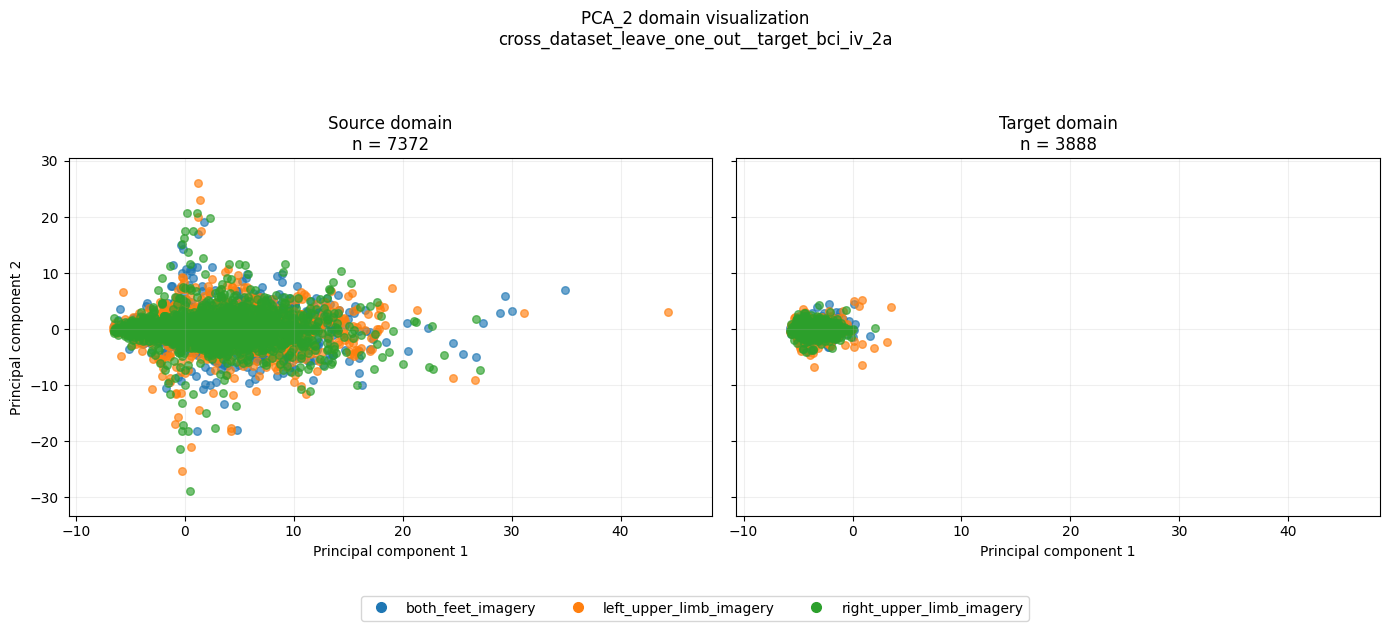

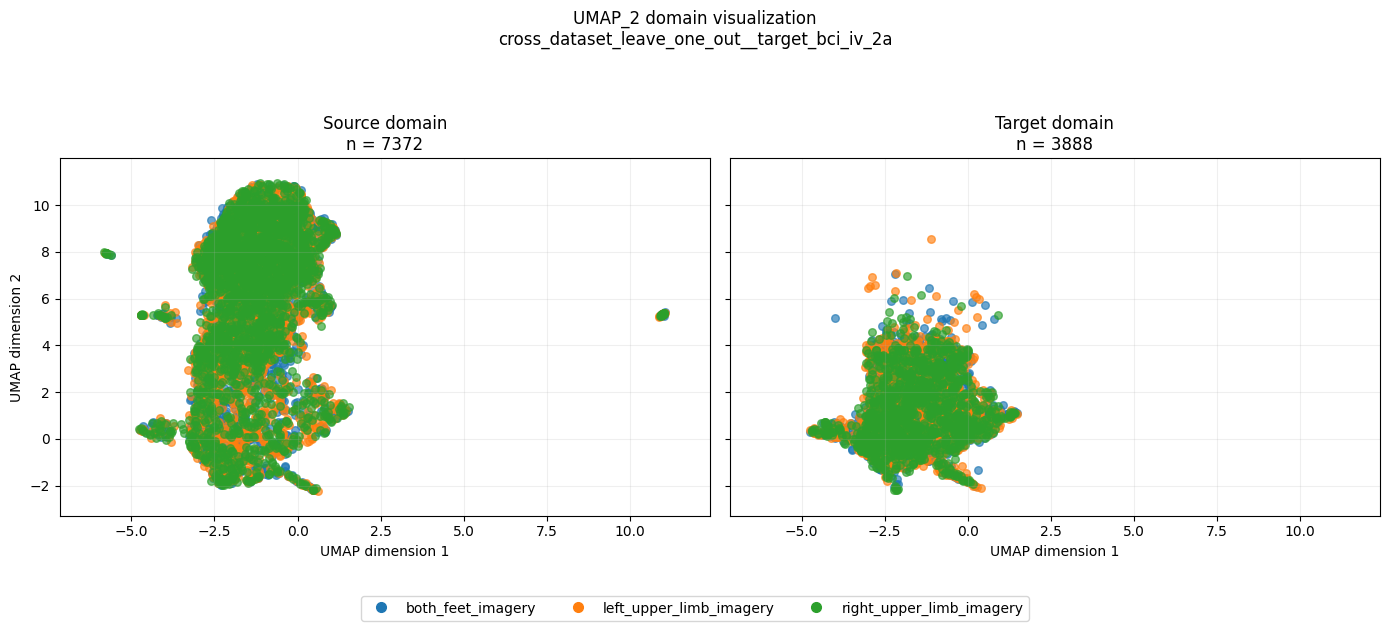

Variance explained by the first two principal components: 40.55%


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.338378,0.338378
1,2,0.067124,0.405502
2,3,0.064813,0.470315
3,4,0.056312,0.526627
4,5,0.048927,0.575554
5,6,0.045790,0.621344
6,7,0.044088,0.665431
7,8,0.033920,0.699351
8,9,0.031683,0.731035
9,10,0.030314,0.761348


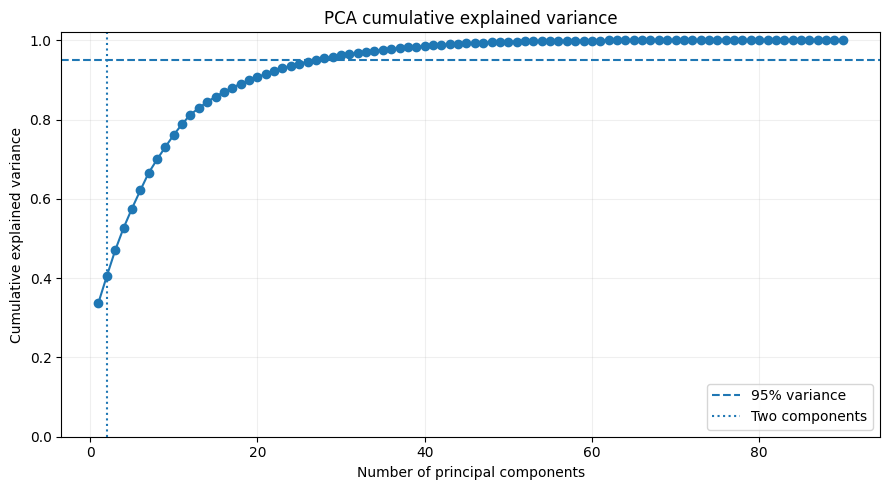

✅ Qualitative domain analysis complete.
Projection data shape: (22520, 17)
Stored projection methods: ['pca_2', 'umap_2']


In [38]:
# ============================================================
# Generate qualitative plots
# ============================================================

AVAILABLE_PROJECTIONS = sorted(
    projection_df[
        "projection_method"
    ]
    .unique()
    .tolist()
)


for projection_method in AVAILABLE_PROJECTIONS:
    plot_source_target_by_label(
        projection_dataframe=projection_df,
        method=projection_method,
        label_color_map=LABEL_COLOR_MAP,
        plot_config=PLOT_CONFIG,
    )


# ============================================================
# PCA explained-variance diagnostics
# ============================================================

if (
    "pca_variance"
    in projection_artifacts["diagnostics"]
):
    pca_variance_df = (
        projection_artifacts[
            "diagnostics"
        ]["pca_variance"]
    )

    pca_2_explained_variance = (
        projection_artifacts[
            "diagnostics"
        ]["pca_2_explained_variance"]
    )

    print(
        "Variance explained by the first two "
        f"principal components: "
        f"{pca_2_explained_variance:.2%}"
    )

    display(
        pca_variance_df.head(20)
    )

    figure, axis = plt.subplots(
        figsize=(9, 5)
    )

    axis.plot(
        pca_variance_df[
            "component"
        ],
        pca_variance_df[
            "cumulative_explained_variance"
        ],
        marker="o",
    )

    axis.axhline(
        y=0.95,
        linestyle="--",
        label="95% variance",
    )

    axis.axvline(
        x=2,
        linestyle=":",
        label="Two components",
    )

    axis.set_title(
        "PCA cumulative explained variance"
    )

    axis.set_xlabel(
        "Number of principal components"
    )

    axis.set_ylabel(
        "Cumulative explained variance"
    )

    axis.set_ylim(
        0,
        1.02,
    )

    axis.grid(alpha=0.2)
    axis.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Store qualitative-analysis outputs
# ============================================================

qualitative_analysis = {
    "split_id": prepared_pair["split_id"],
    "strategy": prepared_pair["strategy"],

    # One row per trial and projection method.
    "projection_data": projection_df,

    # Fitted PCA and UMAP objects and diagnostics.
    "projection_artifacts": (
        projection_artifacts
    ),

    # Reproducibility configurations.
    "projection_config": (
        PROJECTION_CONFIG
    ),
    "plot_config": PLOT_CONFIG,

    # Consistent label-color mapping.
    "label_color_map": (
        LABEL_COLOR_MAP
    ),

    # Features and preprocessing used.
    "feature_realization_id": (
        prepared_pair[
            "feature_realization_id"
        ]
    ),
    "feature_names": prepared_pair[
        "feature_names"
    ],
    "scaler": prepared_pair[
        "scaler"
    ],
}


print(
    "✅ Qualitative domain analysis complete."
)

print(
    "Projection data shape:",
    qualitative_analysis[
        "projection_data"
    ].shape,
)

print(
    "Stored projection methods:",
    sorted(
        qualitative_analysis[
            "projection_data"
        ]["projection_method"]
        .unique()
        .tolist()
    ),
)

In [49]:
# ============================================================
# Stage 3 — Quantitative domain analysis
# Imports and configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance, entropy

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)


QUANTITATIVE_CONFIG = {
    # --------------------------------------------------------
    # Comparisons
    # --------------------------------------------------------

    "analyze_marginal": True,
    "analyze_class_conditional": True,

    # Comparisons with fewer samples are skipped.
    "min_samples_per_domain": 20,

    # Equal numbers of source and target samples are used.
    # None means use every sample from the smaller domain.
    "sampling_mode": "all",  # "all" or "balanced"
    "max_samples_per_domain": None,

    # Initially small for development. Increase later.
    "n_repetitions": 1,

    "seed": 42,

    # --------------------------------------------------------
    # Sample-based distances
    # --------------------------------------------------------

    "sample_distances": [
        "rbf_mmd",
        "energy_distance",
        "sliced_wasserstein",
    ],

    "rbf_mmd": {
        # Median heuristic estimated for each realization.
        "sigma": "median",
    },

    "sliced_wasserstein": {
        "n_projections": 100,
    },

    # --------------------------------------------------------
    # Direct density-ratio estimators
    # --------------------------------------------------------

    "ratio_estimators": [
        "classifier",
        "ulsif",
        "kliep",
    ],

    "ratio_measures": [
        "pearson_divergence",
        "relative_ess",
        "weight_variance",
    ],

    "classifier": {
        "regularization_C": 1.0,
        "n_folds": 5,
        "max_iter": 2000,
        "probability_epsilon": 1e-6,
    },

    "kernel_ratio": {
        # Number of target observations used as kernel centers.
        "n_basis": 100,
        "sigma": "median",
    },

    "ulsif": {
        "regularization": 1e-3,
    },

    "kliep": {
        "learning_rate": 0.1,
        "max_iter": 500,
        "tolerance": 1e-7,
        "epsilon": 1e-10,
    },
}


print("✅ Quantitative-analysis configuration prepared.")

✅ Quantitative-analysis configuration prepared.


In [50]:
# ============================================================
# Sample-based distance functions
# ============================================================

def domain_subsample(
    X_source,
    X_target,
    sampling_mode,
    max_samples_per_domain,
    seed,
):
    """
    Select samples for the quantitative comparison.

    Modes
    -----
    all:
        Use every available source and target sample. The two
        domains may have different sample sizes.

    balanced:
        Randomly select the same number of samples from each
        domain. The number is optionally limited by
        max_samples_per_domain.
    """
    X_source = np.asarray(
        X_source,
        dtype=np.float64,
    )

    X_target = np.asarray(
        X_target,
        dtype=np.float64,
    )

    if len(X_source) == 0 or len(X_target) == 0:
        raise ValueError(
            "Source and target must contain samples."
        )

    # ========================================================
    # Use all available observations
    # ========================================================

    if sampling_mode == "all":
        return (
            X_source,
            X_target,
            np.arange(len(X_source)),
            np.arange(len(X_target)),
        )

    # ========================================================
    # Balanced random subsampling
    # ========================================================

    if sampling_mode == "balanced":
        n_samples = min(
            len(X_source),
            len(X_target),
        )

        if max_samples_per_domain is not None:
            if max_samples_per_domain < 1:
                raise ValueError(
                    "max_samples_per_domain must be "
                    "positive or None."
                )

            n_samples = min(
                n_samples,
                max_samples_per_domain,
            )

        rng = np.random.default_rng(seed)

        source_indices = rng.choice(
            len(X_source),
            size=n_samples,
            replace=False,
        )

        target_indices = rng.choice(
            len(X_target),
            size=n_samples,
            replace=False,
        )

        return (
            X_source[source_indices],
            X_target[target_indices],
            source_indices,
            target_indices,
        )

    raise ValueError(
        f"Unknown sampling mode: {sampling_mode}. "
        "Use 'all' or 'balanced'."
    )


def median_heuristic_sigma(
    X_source,
    X_target,
    seed=42,
    max_points=1000,
):
    """
    Estimate an RBF bandwidth from pooled pairwise distances.
    """
    pooled = np.vstack(
        [
            X_source,
            X_target,
        ]
    )

    if len(pooled) > max_points:
        rng = np.random.default_rng(seed)

        indices = rng.choice(
            len(pooled),
            size=max_points,
            replace=False,
        )

        pooled = pooled[indices]

    squared_distances = pdist(
        pooled,
        metric="sqeuclidean",
    )

    positive_distances = squared_distances[
        squared_distances > 0
    ]

    if len(positive_distances) == 0:
        return 1.0

    sigma = np.sqrt(
        np.median(positive_distances)
    )

    return max(
        float(sigma),
        1e-8,
    )


def rbf_kernel_matrix(
    X,
    Y,
    sigma,
):
    """
    Calculate an RBF-kernel matrix.
    """
    squared_distances = cdist(
        X,
        Y,
        metric="sqeuclidean",
    )

    return np.exp(
        -squared_distances
        / (2.0 * sigma**2)
    )


def calculate_rbf_mmd(
    X_source,
    X_target,
    sigma=None,
    seed=42,
):
    """
    Calculate the nonnegative biased estimate of RBF MMD².
    """
    if sigma is None:
        sigma = median_heuristic_sigma(
            X_source=X_source,
            X_target=X_target,
            seed=seed,
        )

    K_source_source = rbf_kernel_matrix(
        X_source,
        X_source,
        sigma,
    )

    K_target_target = rbf_kernel_matrix(
        X_target,
        X_target,
        sigma,
    )

    K_source_target = rbf_kernel_matrix(
        X_source,
        X_target,
        sigma,
    )

    mmd_squared = (
        K_source_source.mean()
        + K_target_target.mean()
        - 2.0 * K_source_target.mean()
    )

    return max(
        float(mmd_squared),
        0.0,
    ), {
        "sigma": sigma,
    }


def calculate_energy_distance(
    X_source,
    X_target,
):
    """
    Calculate the multivariate energy discrepancy.

    Larger values indicate greater distributional difference.
    """
    source_target_distances = cdist(
        X_source,
        X_target,
        metric="euclidean",
    )

    source_source_distances = cdist(
        X_source,
        X_source,
        metric="euclidean",
    )

    target_target_distances = cdist(
        X_target,
        X_target,
        metric="euclidean",
    )

    value = (
        2.0 * source_target_distances.mean()
        - source_source_distances.mean()
        - target_target_distances.mean()
    )

    return max(
        float(value),
        0.0,
    ), {}


def calculate_sliced_wasserstein(
    X_source,
    X_target,
    n_projections=100,
    seed=42,
):
    """
    Approximate multivariate Wasserstein discrepancy by
    averaging one-dimensional Wasserstein distances over random
    projection directions.
    """
    if X_source.shape[1] != X_target.shape[1]:
        raise ValueError(
            "Source and target must have the same dimension."
        )

    rng = np.random.default_rng(seed)

    directions = rng.normal(
        size=(
            n_projections,
            X_source.shape[1],
        )
    )

    direction_norms = np.linalg.norm(
        directions,
        axis=1,
        keepdims=True,
    )

    directions = directions / np.maximum(
        direction_norms,
        1e-12,
    )

    source_projections = (
        X_source @ directions.T
    )

    target_projections = (
        X_target @ directions.T
    )

    projection_distances = []

    for projection_index in range(
        n_projections
    ):
        value = wasserstein_distance(
            source_projections[
                :,
                projection_index,
            ],
            target_projections[
                :,
                projection_index,
            ],
        )

        projection_distances.append(
            value
        )

    return float(
        np.mean(projection_distances)
    ), {
        "n_projections": n_projections,
    }


def calculate_sample_distances(
    X_source,
    X_target,
    config,
    seed,
):
    """
    Calculate every enabled sample-based distance.
    """
    results = []

    for metric in config["sample_distances"]:
        if metric == "rbf_mmd":
            value, parameters = (
                calculate_rbf_mmd(
                    X_source=X_source,
                    X_target=X_target,
                    sigma=None,
                    seed=seed,
                )
            )

        elif metric == "energy_distance":
            value, parameters = (
                calculate_energy_distance(
                    X_source=X_source,
                    X_target=X_target,
                )
            )

        elif metric == "sliced_wasserstein":
            value, parameters = (
                calculate_sliced_wasserstein(
                    X_source=X_source,
                    X_target=X_target,
                    n_projections=config[
                        "sliced_wasserstein"
                    ]["n_projections"],
                    seed=seed,
                )
            )

        else:
            raise ValueError(
                f"Unknown sample distance: {metric}"
            )

        results.append(
            {
                "metric": metric,
                "value": value,
                "parameters": parameters,
            }
        )

    return results


print("✅ Sample-based distance functions prepared.")

✅ Sample-based distance functions prepared.


In [51]:
# ============================================================
# Direct density-ratio estimation
# ============================================================

def stabilize_density_ratio(
    weights,
    epsilon=1e-10,
):
    """
    Ensure positive finite weights and normalize their source
    mean to one.

    Theoretical importance weights satisfy E_source[w(X)] = 1.
    """
    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    weights = np.nan_to_num(
        weights,
        nan=epsilon,
        posinf=1.0 / epsilon,
        neginf=epsilon,
    )

    weights = np.maximum(
        weights,
        epsilon,
    )

    mean_weight = weights.mean()

    if (
        not np.isfinite(mean_weight)
        or mean_weight <= epsilon
    ):
        return np.ones_like(weights)

    return weights / mean_weight


def estimate_classifier_ratio(
    X_source,
    X_target,
    config,
    seed,
):
    """
    Estimate p_target(x) / p_source(x) through domain
    classification using out-of-fold probabilities.
    """
    X_combined = np.vstack(
        [
            X_source,
            X_target,
        ]
    )

    domain_labels = np.concatenate(
        [
            np.zeros(
                len(X_source),
                dtype=int,
            ),
            np.ones(
                len(X_target),
                dtype=int,
            ),
        ]
    )

    requested_folds = config["n_folds"]

    maximum_folds = min(
        np.bincount(domain_labels)
    )

    n_folds = min(
        requested_folds,
        maximum_folds,
    )

    if n_folds < 2:
        raise ValueError(
            "Classifier ratio estimation requires at "
            "least two samples from each domain."
        )

    cross_validation = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=seed,
    )

    model = LogisticRegression(
        C=config["regularization_C"],
        penalty="l2",
        solver="lbfgs",
        max_iter=config["max_iter"],
        random_state=seed,
    )

    target_probability = cross_val_predict(
        estimator=model,
        X=X_combined,
        y=domain_labels,
        cv=cross_validation,
        method="predict_proba",
    )[:, 1]

    epsilon = config[
        "probability_epsilon"
    ]

    target_probability = np.clip(
        target_probability,
        epsilon,
        1.0 - epsilon,
    )

    source_target_probability = (
        target_probability[
            :len(X_source)
        ]
    )

    # Prior correction:
    #
    # p_t(x) / p_s(x)
    # =
    # P(D=t|x) / P(D=s|x)
    # × P(D=s) / P(D=t)
    prior_correction = (
        len(X_source)
        / len(X_target)
    )

    source_weights = (
        source_target_probability
        / (
            1.0
            - source_target_probability
        )
        * prior_correction
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "n_folds": n_folds,
        "regularization_C": (
            config["regularization_C"]
        ),
    }


def select_kernel_centers(
    X_target,
    n_basis,
    seed,
):
    """
    Select target observations as Gaussian-kernel centers.
    """
    n_basis = min(
        n_basis,
        len(X_target),
    )

    rng = np.random.default_rng(seed)

    indices = rng.choice(
        len(X_target),
        size=n_basis,
        replace=False,
    )

    return X_target[indices]


def create_rbf_basis(
    X,
    centers,
    sigma,
):
    """
    Create Gaussian RBF basis values.
    """
    return rbf_kernel_matrix(
        X=X,
        Y=centers,
        sigma=sigma,
    )


def estimate_ulsif_ratio(
    X_source,
    X_target,
    kernel_config,
    ulsif_config,
    seed,
):
    """
    Estimate density ratios using unconstrained least-squares
    importance fitting.
    """
    sigma = median_heuristic_sigma(
        X_source=X_source,
        X_target=X_target,
        seed=seed,
    )

    centers = select_kernel_centers(
        X_target=X_target,
        n_basis=kernel_config[
            "n_basis"
        ],
        seed=seed,
    )

    basis_source = create_rbf_basis(
        X=X_source,
        centers=centers,
        sigma=sigma,
    )

    basis_target = create_rbf_basis(
        X=X_target,
        centers=centers,
        sigma=sigma,
    )

    H = (
        basis_source.T
        @ basis_source
        / len(X_source)
    )

    h = basis_target.mean(
        axis=0
    )

    regularization = ulsif_config[
        "regularization"
    ]

    regularized_H = (
        H
        + regularization
        * np.eye(H.shape[0])
    )

    try:
        alpha = np.linalg.solve(
            regularized_H,
            h,
        )

    except np.linalg.LinAlgError:
        alpha = np.linalg.pinv(
            regularized_H
        ) @ h

    alpha = np.maximum(
        alpha,
        0.0,
    )

    source_weights = (
        basis_source @ alpha
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "sigma": sigma,
        "n_basis": len(centers),
        "regularization": regularization,
    }


def estimate_kliep_ratio(
    X_source,
    X_target,
    kernel_config,
    kliep_config,
    seed,
):
    """
    Estimate density ratios using a kernel KLIEP objective.

    The optimization maximizes target log-likelihood subject to
    nonnegative ratios with mean source weight equal to one.
    """
    sigma = median_heuristic_sigma(
        X_source=X_source,
        X_target=X_target,
        seed=seed,
    )

    centers = select_kernel_centers(
        X_target=X_target,
        n_basis=kernel_config[
            "n_basis"
        ],
        seed=seed,
    )

    basis_source = create_rbf_basis(
        X=X_source,
        centers=centers,
        sigma=sigma,
    )

    basis_target = create_rbf_basis(
        X=X_target,
        centers=centers,
        sigma=sigma,
    )

    epsilon = kliep_config["epsilon"]

    source_basis_mean = basis_source.mean(
        axis=0
    )

    alpha = np.ones(
        basis_source.shape[1],
        dtype=np.float64,
    )

    normalization = (
        source_basis_mean @ alpha
    )

    alpha = alpha / max(
        normalization,
        epsilon,
    )

    previous_objective = -np.inf

    for iteration in range(
        kliep_config["max_iter"]
    ):
        target_ratio = (
            basis_target @ alpha
        )

        target_ratio = np.maximum(
            target_ratio,
            epsilon,
        )

        gradient = np.mean(
            basis_target
            / target_ratio[:, None],
            axis=0,
        )

        step_size = (
            kliep_config[
                "learning_rate"
            ]
            / np.sqrt(iteration + 1.0)
        )

        alpha = (
            alpha
            + step_size * gradient
        )

        alpha = np.maximum(
            alpha,
            0.0,
        )

        normalization = (
            source_basis_mean @ alpha
        )

        if normalization <= epsilon:
            alpha = np.ones_like(alpha)

            normalization = (
                source_basis_mean @ alpha
            )

        alpha = alpha / max(
            normalization,
            epsilon,
        )

        target_ratio = np.maximum(
            basis_target @ alpha,
            epsilon,
        )

        objective = np.mean(
            np.log(target_ratio)
        )

        if (
            np.isfinite(previous_objective)
            and abs(
                objective
                - previous_objective
            )
            < kliep_config["tolerance"]
        ):
            break

        previous_objective = objective

    source_weights = (
        basis_source @ alpha
    )

    source_weights = stabilize_density_ratio(
        source_weights
    )

    return source_weights, {
        "sigma": sigma,
        "n_basis": len(centers),
        "iterations": iteration + 1,
        "objective": objective,
    }


def estimate_density_ratio(
    estimator,
    X_source,
    X_target,
    config,
    seed,
):
    """
    Run one enabled density-ratio estimator.
    """
    if estimator == "classifier":
        return estimate_classifier_ratio(
            X_source=X_source,
            X_target=X_target,
            config=config["classifier"],
            seed=seed,
        )

    if estimator == "ulsif":
        return estimate_ulsif_ratio(
            X_source=X_source,
            X_target=X_target,
            kernel_config=config[
                "kernel_ratio"
            ],
            ulsif_config=config["ulsif"],
            seed=seed,
        )

    if estimator == "kliep":
        return estimate_kliep_ratio(
            X_source=X_source,
            X_target=X_target,
            kernel_config=config[
                "kernel_ratio"
            ],
            kliep_config=config["kliep"],
            seed=seed,
        )

    raise ValueError(
        f"Unknown ratio estimator: {estimator}"
    )


# ============================================================
# Density-ratio-based measures
# ============================================================

def calculate_ratio_measures(
    source_weights,
):
    """
    Calculate IW-aligned domain-discrepancy diagnostics.
    """
    weights = np.asarray(
        source_weights,
        dtype=np.float64,
    )

    pearson_divergence = (
        0.5
        * np.mean(
            (weights - 1.0) ** 2
        )
    )

    effective_sample_size = (
        weights.sum() ** 2
        / np.sum(weights**2)
    )

    relative_ess = (
        effective_sample_size
        / len(weights)
    )

    weight_variance = np.var(
        weights,
        ddof=0,
    )

    return {
        "pearson_divergence": float(
            pearson_divergence
        ),
        "relative_ess": float(
            relative_ess
        ),
        "weight_variance": float(
            weight_variance
        ),
    }


def summarize_weights(
    weights,
):
    """
    Store additional information about the estimated ratios.
    """
    weights = np.asarray(
        weights,
        dtype=np.float64,
    )

    return {
        "weight_mean": float(
            weights.mean()
        ),
        "weight_std": float(
            weights.std(ddof=0)
        ),
        "weight_min": float(
            weights.min()
        ),
        "weight_q05": float(
            np.quantile(weights, 0.05)
        ),
        "weight_q25": float(
            np.quantile(weights, 0.25)
        ),
        "weight_median": float(
            np.quantile(weights, 0.50)
        ),
        "weight_q75": float(
            np.quantile(weights, 0.75)
        ),
        "weight_q95": float(
            np.quantile(weights, 0.95)
        ),
        "weight_max": float(
            weights.max()
        ),
    }


print("✅ Density-ratio functions prepared.")

✅ Density-ratio functions prepared.


In [52]:
# ============================================================
# Construct marginal and class-conditional comparisons
# ============================================================

def construct_quantitative_comparisons(
    prepared_pair,
    config,
):
    """
    Construct:
        1. one marginal source-target comparison;
        2. one comparison for every common class.
    """
    X_source = prepared_pair[
        "X_source"
    ].to_numpy(
        dtype=np.float64
    )

    X_target = prepared_pair[
        "X_target"
    ].to_numpy(
        dtype=np.float64
    )

    y_source = prepared_pair[
        "y_source"
    ].to_numpy()

    y_target = prepared_pair[
        "y_target"
    ].to_numpy()

    comparisons = []

    if config["analyze_marginal"]:
        comparisons.append(
            {
                "comparison_id": "marginal",
                "comparison_type": "marginal",
                "analysis_label": None,
                "X_source": X_source,
                "X_target": X_target,
            }
        )

    if config["analyze_class_conditional"]:
        common_labels = sorted(
            set(y_source)
            & set(y_target)
        )

        for class_label in common_labels:
            source_mask = (
                y_source == class_label
            )

            target_mask = (
                y_target == class_label
            )

            comparisons.append(
                {
                    "comparison_id": (
                        f"class__{class_label}"
                    ),
                    "comparison_type": (
                        "class_conditional"
                    ),
                    "analysis_label": (
                        class_label
                    ),
                    "X_source": (
                        X_source[source_mask]
                    ),
                    "X_target": (
                        X_target[target_mask]
                    ),
                }
            )

    return comparisons


def run_quantitative_domain_analysis(
    prepared_pair,
    config,
):
    """
    Run sample-based and density-ratio-based analyses for every
    comparison and repetition.
    """
    comparisons = (
        construct_quantitative_comparisons(
            prepared_pair=prepared_pair,
            config=config,
        )
    )

    result_records = []
    weight_records = []
    skipped_records = []

    base_seed = config["seed"]

    for comparison_index, comparison in enumerate(
        comparisons
    ):
        X_source_full = comparison[
            "X_source"
        ]

        X_target_full = comparison[
            "X_target"
        ]

        n_source_full = len(
            X_source_full
        )

        n_target_full = len(
            X_target_full
        )

        minimum_samples = config[
            "min_samples_per_domain"
        ]

        if (
            n_source_full < minimum_samples
            or n_target_full < minimum_samples
        ):
            skipped_records.append(
                {
                    "comparison_id": comparison[
                        "comparison_id"
                    ],
                    "comparison_type": comparison[
                        "comparison_type"
                    ],
                    "analysis_label": comparison[
                        "analysis_label"
                    ],
                    "n_source": n_source_full,
                    "n_target": n_target_full,
                    "reason": (
                        "insufficient_samples"
                    ),
                }
            )

            continue

        for repetition in range(
            config["n_repetitions"]
        ):
            repetition_seed = (
                base_seed
                + 10_000 * comparison_index
                + repetition
            )

            (
                X_source,
                X_target,
                source_indices,
                target_indices,
            ) = domain_subsample(
                X_source=X_source_full,
                X_target=X_target_full,
                sampling_mode=config["sampling_mode"],
                max_samples_per_domain=config[
                    "max_samples_per_domain"
                ],
                seed=repetition_seed,
            )

            common_information = {
                "split_id": prepared_pair[
                    "split_id"
                ],
                "strategy": prepared_pair[
                    "strategy"
                ],
                "feature_realization_id": (
                    prepared_pair[
                        "feature_realization_id"
                    ]
                ),
                "n_features": prepared_pair[
                    "n_features"
                ],
                "comparison_id": comparison[
                    "comparison_id"
                ],
                "comparison_type": comparison[
                    "comparison_type"
                ],
                "analysis_label": comparison[
                    "analysis_label"
                ],
                "repetition": repetition,
                "seed": repetition_seed,
                "n_source_full": n_source_full,
                "n_target_full": n_target_full,
                "n_source": len(X_source),
                "n_target": len(X_target),
            }

            # =================================================
            # Sample-based distances
            # =================================================

            sample_results = (
                calculate_sample_distances(
                    X_source=X_source,
                    X_target=X_target,
                    config=config,
                    seed=repetition_seed,
                )
            )

            for sample_result in sample_results:
                result_records.append(
                    {
                        **common_information,
                        "metric_family": (
                            "sample_distance"
                        ),
                        "estimator": None,
                        "metric": sample_result[
                            "metric"
                        ],
                        "value": sample_result[
                            "value"
                        ],
                        "parameters": sample_result[
                            "parameters"
                        ],
                        "status": "ok",
                        "error": None,
                    }
                )

            # =================================================
            # Density-ratio estimators and diagnostics
            # =================================================

            for estimator_index, estimator in enumerate(
                config["ratio_estimators"]
            ):
                estimator_seed = (
                    repetition_seed
                    + 100 * estimator_index
                )

                try:
                    weights, estimator_parameters = (
                        estimate_density_ratio(
                            estimator=estimator,
                            X_source=X_source,
                            X_target=X_target,
                            config=config,
                            seed=estimator_seed,
                        )
                    )

                    ratio_measures = (
                        calculate_ratio_measures(
                            source_weights=weights
                        )
                    )

                    for measure in config[
                        "ratio_measures"
                    ]:
                        result_records.append(
                            {
                                **common_information,
                                "metric_family": (
                                    "ratio_diagnostic"
                                ),
                                "estimator": estimator,
                                "metric": measure,
                                "value": ratio_measures[
                                    measure
                                ],
                                "parameters": (
                                    estimator_parameters
                                ),
                                "status": "ok",
                                "error": None,
                            }
                        )

                    weight_records.append(
                        {
                            **common_information,
                            "estimator": estimator,
                            **summarize_weights(
                                weights
                            ),
                            "parameters": (
                                estimator_parameters
                            ),
                            "status": "ok",
                            "error": None,
                        }
                    )

                except Exception as exception:
                    for measure in config[
                        "ratio_measures"
                    ]:
                        result_records.append(
                            {
                                **common_information,
                                "metric_family": (
                                    "ratio_diagnostic"
                                ),
                                "estimator": estimator,
                                "metric": measure,
                                "value": np.nan,
                                "parameters": {},
                                "status": "failed",
                                "error": str(
                                    exception
                                ),
                            }
                        )

                    weight_records.append(
                        {
                            **common_information,
                            "estimator": estimator,
                            "status": "failed",
                            "error": str(exception),
                        }
                    )

    results_dataframe = pd.DataFrame(
        result_records
    )

    weights_dataframe = pd.DataFrame(
        weight_records
    )

    skipped_dataframe = pd.DataFrame(
        skipped_records
    )

    return {
        "results": results_dataframe,
        "weight_diagnostics": (
            weights_dataframe
        ),
        "skipped_comparisons": (
            skipped_dataframe
        ),
        "configuration": config,
        "comparisons": comparisons,
    }


# ============================================================
# Run quantitative analysis
# ============================================================

quantitative_analysis = (
    run_quantitative_domain_analysis(
        prepared_pair=prepared_pair,
        config=QUANTITATIVE_CONFIG,
    )
)

quantitative_results_df = (
    quantitative_analysis["results"]
)

weight_diagnostics_df = (
    quantitative_analysis[
        "weight_diagnostics"
    ]
)

skipped_comparisons_df = (
    quantitative_analysis[
        "skipped_comparisons"
    ]
)


print("✅ Quantitative domain analysis complete.")

print(
    "Result rows:",
    len(quantitative_results_df),
)

print(
    "Successful rows:",
    (
        quantitative_results_df["status"]
        == "ok"
    ).sum(),
)

print(
    "Failed rows:",
    (
        quantitative_results_df["status"]
        == "failed"
    ).sum(),
)

display(
    quantitative_results_df.head(20)
)

if not skipped_comparisons_df.empty:
    print("\nSkipped comparisons")
    display(skipped_comparisons_df)

✅ Quantitative domain analysis complete.
Result rows: 48
Successful rows: 48
Failed rows: 0


,split_id,strategy,feature_realization_id,n_features,comparison_id,comparison_type,analysis_label,repetition,seed,n_source_full,n_target_full,n_source,n_target,metric_family,estimator,metric,value,parameters,status,error
0,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,rbf_mmd,0.205180,{'sigma': 8.983361549746144},ok,None
1,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,energy_distance,3.671414,{},ok,None
2,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,sample_distance,None,sliced_wasserstein,0.613489,{'n_projections': 100},ok,None
3,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,pearson_divergence,179.916781,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
4,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,relative_ess,0.002771,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
5,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,classifier,weight_variance,359.833561,"{'n_folds': 5, 'regularization_C': 1.0}",ok,None
6,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,pearson_divergence,0.105153,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
7,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,relative_ess,0.826237,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
8,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,ulsif,weight_variance,0.210306,"{'sigma': 9.054428802078586, 'n_basis': 100, '...",ok,None
9,cross_dataset_leave_one_out__target_bci_iv_2a,cross_dataset_leave_one_out,all_compatible,90,marginal,marginal,None,0,42,7372,3888,7372,3888,ratio_diagnostic,kliep,pearson_divergence,0.101757,"{'sigma': 8.992877098024753, 'n_basis': 100, '...",ok,None


Label proportions


,analysis_label,source_probability,target_probability
0,both_feet_imagery,0.333017,0.333333
1,left_upper_limb_imagery,0.336272,0.333333
2,right_upper_limb_imagery,0.330711,0.333333


Label-distribution discrepancy


,metric,value
0,label_total_variation,0.002939
1,label_jensen_shannon,0.000006


Quantitative summary


,metric_family,estimator,metric,comparison_id,comparison_type,analysis_label,n_repetitions,mean,std,median,q025,q975,minimum,maximum
0,ratio_diagnostic,classifier,pearson_divergence,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,13.304339,0.0,13.304339,13.304339,13.304339,13.304339,13.304339
1,ratio_diagnostic,classifier,pearson_divergence,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,93.484289,0.0,93.484289,93.484289,93.484289,93.484289,93.484289
2,ratio_diagnostic,classifier,pearson_divergence,class__right_upper_limb_imagery,class_conditional,right_upper_limb_imagery,1.0,48.900168,0.0,48.900168,48.900168,48.900168,48.900168,48.900168
3,ratio_diagnostic,classifier,pearson_divergence,marginal,marginal,NaN,1.0,179.916781,0.0,179.916781,179.916781,179.916781,179.916781,179.916781
4,ratio_diagnostic,classifier,relative_ess,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,0.036220,0.0,0.036220,0.036220,0.036220,0.036220,0.036220
5,ratio_diagnostic,classifier,relative_ess,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,0.005320,0.0,0.005320,0.005320,0.005320,0.005320,0.005320
6,ratio_diagnostic,classifier,relative_ess,class__right_upper_limb_imagery,class_conditional,right_upper_limb_imagery,1.0,0.010121,0.0,0.010121,0.010121,0.010121,0.010121,0.010121
7,ratio_diagnostic,classifier,relative_ess,marginal,marginal,NaN,1.0,0.002771,0.0,0.002771,0.002771,0.002771,0.002771,0.002771
8,ratio_diagnostic,classifier,weight_variance,class__both_feet_imagery,class_conditional,both_feet_imagery,1.0,26.608679,0.0,26.608679,26.608679,26.608679,26.608679,26.608679
9,ratio_diagnostic,classifier,weight_variance,class__left_upper_limb_imagery,class_conditional,left_upper_limb_imagery,1.0,186.968579,0.0,186.968579,186.968579,186.968579,186.968579,186.968579


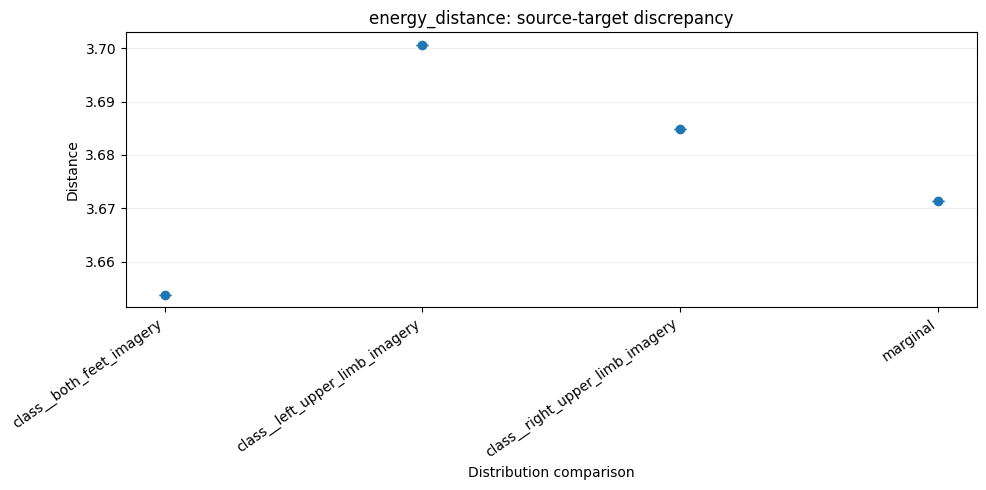

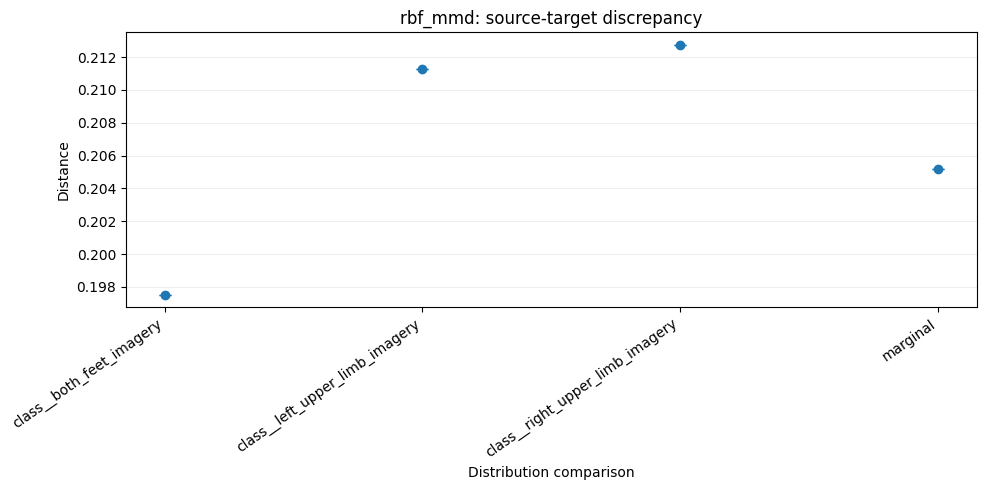

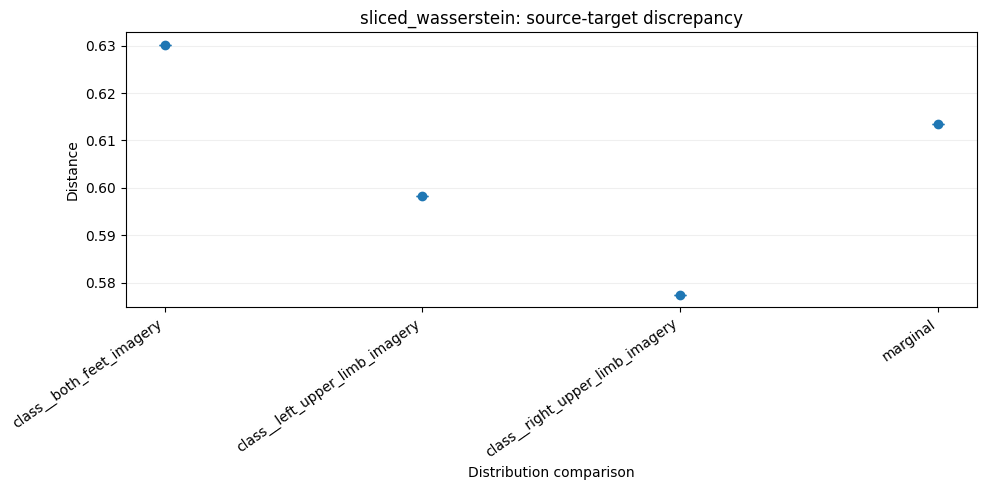

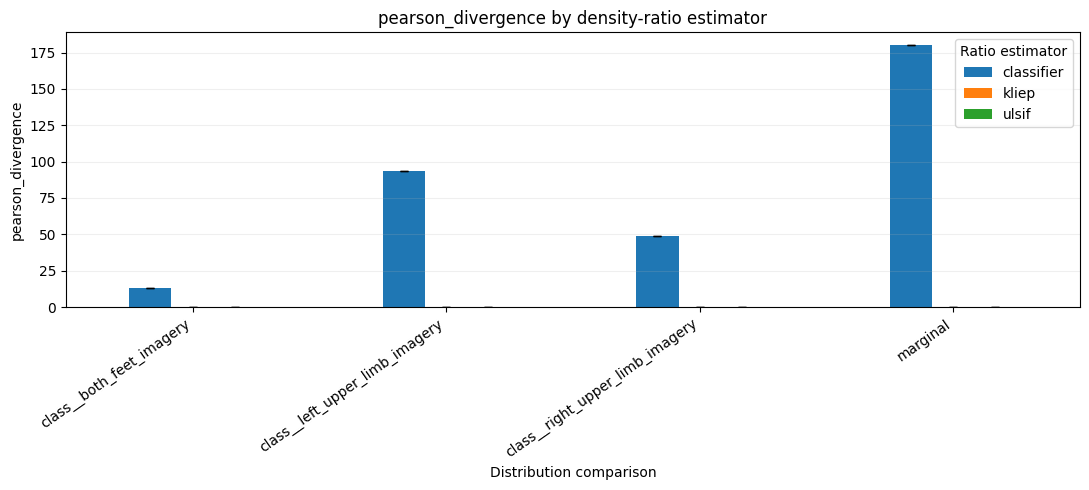

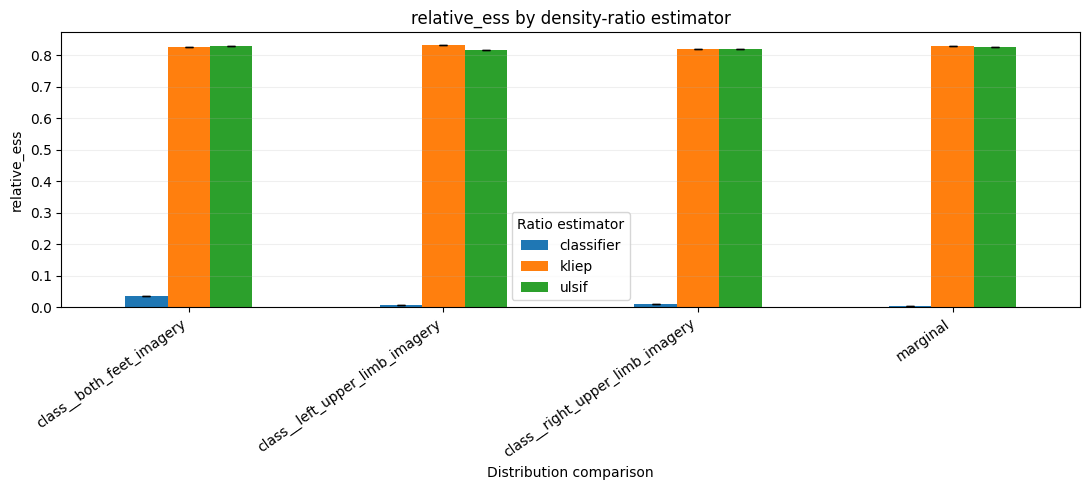

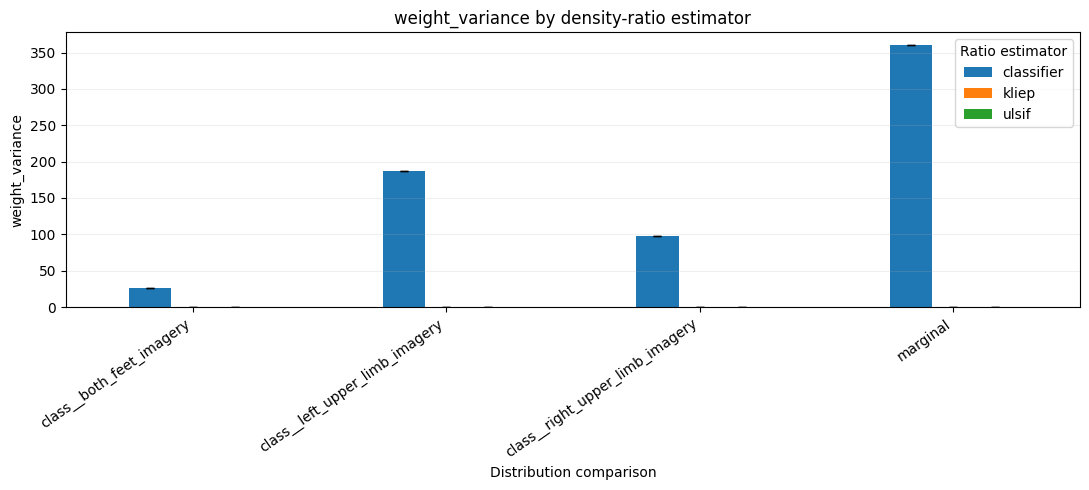

✅ Quantitative summaries and plots created.


In [53]:
# ============================================================
# Compare source and target label distributions
# ============================================================

def calculate_label_shift(
    y_source,
    y_target,
):
    """
    Compare P_source(Y) and P_target(Y).
    """
    labels = sorted(
        set(y_source)
        | set(y_target)
    )

    source_counts = pd.Series(
        y_source
    ).value_counts()

    target_counts = pd.Series(
        y_target
    ).value_counts()

    source_probabilities = np.array(
        [
            source_counts.get(
                label,
                0,
            )
            / len(y_source)
            for label in labels
        ]
    )

    target_probabilities = np.array(
        [
            target_counts.get(
                label,
                0,
            )
            / len(y_target)
            for label in labels
        ]
    )

    distribution_dataframe = pd.DataFrame(
        {
            "analysis_label": labels,
            "source_probability": (
                source_probabilities
            ),
            "target_probability": (
                target_probabilities
            ),
        }
    )

    total_variation = (
        0.5
        * np.abs(
            source_probabilities
            - target_probabilities
        ).sum()
    )

    mixture = (
        0.5
        * (
            source_probabilities
            + target_probabilities
        )
    )

    jensen_shannon = (
        0.5
        * entropy(
            source_probabilities,
            mixture,
        )
        + 0.5
        * entropy(
            target_probabilities,
            mixture,
        )
    )

    metrics_dataframe = pd.DataFrame(
        {
            "metric": [
                "label_total_variation",
                "label_jensen_shannon",
            ],
            "value": [
                total_variation,
                jensen_shannon,
            ],
        }
    )

    return (
        distribution_dataframe,
        metrics_dataframe,
    )


(
    label_distribution_df,
    label_shift_metrics_df,
) = calculate_label_shift(
    y_source=prepared_pair[
        "y_source"
    ],
    y_target=prepared_pair[
        "y_target"
    ],
)


print("Label proportions")
display(label_distribution_df)

print("Label-distribution discrepancy")
display(label_shift_metrics_df)


# ============================================================
# Summarize repeated quantitative results
# ============================================================

successful_results = (
    quantitative_results_df.loc[
        quantitative_results_df[
            "status"
        ] == "ok"
    ]
    .copy()
)


def summarize_metric_group(group):
    values = group[
        "value"
    ].to_numpy()

    return pd.Series(
        {
            "n_repetitions": len(values),
            "mean": np.mean(values),
            "std": (
                np.std(values, ddof=1)
                if len(values) > 1
                else 0.0
            ),
            "median": np.median(values),
            "q025": np.quantile(
                values,
                0.025,
            ),
            "q975": np.quantile(
                values,
                0.975,
            ),
            "minimum": np.min(values),
            "maximum": np.max(values),
        }
    )


quantitative_summary_df = (
    successful_results
    .groupby(
        [
            "metric_family",
            "estimator",
            "metric",
            "comparison_id",
            "comparison_type",
            "analysis_label",
        ],
        dropna=False,
    )
    .apply(
        summarize_metric_group,
        include_groups=False,
    )
    .reset_index()
)


print("Quantitative summary")
display(
    quantitative_summary_df
)


# ============================================================
# Plot sample-based distances
# ============================================================

sample_summary = (
    quantitative_summary_df.loc[
        quantitative_summary_df[
            "metric_family"
        ] == "sample_distance"
    ]
)


for metric in sorted(
    sample_summary["metric"].unique()
):
    plot_dataframe = (
        sample_summary.loc[
            sample_summary["metric"]
            == metric
        ]
        .sort_values(
            "comparison_id"
        )
    )

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    axis.errorbar(
        x=np.arange(
            len(plot_dataframe)
        ),
        y=plot_dataframe["mean"],
        yerr=plot_dataframe["std"],
        marker="o",
        linestyle="",
        capsize=4,
    )

    axis.set_xticks(
        np.arange(
            len(plot_dataframe)
        )
    )

    axis.set_xticklabels(
        plot_dataframe[
            "comparison_id"
        ],
        rotation=35,
        ha="right",
    )

    axis.set_title(
        f"{metric}: source-target discrepancy"
    )

    axis.set_xlabel(
        "Distribution comparison"
    )

    axis.set_ylabel(
        "Distance"
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Plot density-ratio diagnostics
# ============================================================

ratio_summary = (
    quantitative_summary_df.loc[
        quantitative_summary_df[
            "metric_family"
        ] == "ratio_diagnostic"
    ]
)


for metric in sorted(
    ratio_summary["metric"].unique()
):
    metric_dataframe = (
        ratio_summary.loc[
            ratio_summary["metric"]
            == metric
        ]
    )

    mean_table = metric_dataframe.pivot(
        index="comparison_id",
        columns="estimator",
        values="mean",
    )

    std_table = metric_dataframe.pivot(
        index="comparison_id",
        columns="estimator",
        values="std",
    )

    axis = mean_table.plot(
        kind="bar",
        yerr=std_table,
        capsize=3,
        figsize=(11, 5),
    )

    axis.set_title(
        f"{metric} by density-ratio estimator"
    )

    axis.set_xlabel(
        "Distribution comparison"
    )

    axis.set_ylabel(
        metric
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    axis.legend(
        title="Ratio estimator"
    )

    plt.xticks(
        rotation=35,
        ha="right",
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Add final outputs to the stored analysis object
# ============================================================

quantitative_analysis[
    "summary"
] = quantitative_summary_df

quantitative_analysis[
    "label_distribution"
] = label_distribution_df

quantitative_analysis[
    "label_shift_metrics"
] = label_shift_metrics_df


print("✅ Quantitative summaries and plots created.")

# Experimental Scenarios

### Define train test split

training_data = {
    # Source
    "X_source": ...,
    "y_source": ...,
    "source_domains": ...,

    # Target available during training/adaptation
    "X_target_train": ...,
    "y_target_train": ...,
    "target_train_domains": ...,

    # Target held out for evaluation
    "X_target_test": ...,
    "y_target_test": ...,
    "target_test_domains": ...,
}

In [54]:
# ============================================================
# Stage 4 — Build training data
# Target train/test split configuration
# ============================================================

TARGET_SPLIT_CONFIG = {
    # --------------------------------------------------------
    # Split mode
    # --------------------------------------------------------
    #
    # "sample_holdout"
    #     Pool all target samples and randomly split them.
    #
    # "per_domain_sample_holdout"
    #     Split samples independently inside every target domain.
    #
    # "domain_holdout"
    #     Entire target domains are assigned either to train
    #     or test.
    #
    "mode": "per_domain_sample_holdout",

    # --------------------------------------------------------
    # Sample-based split settings
    # --------------------------------------------------------

    # Used by:
    #     sample_holdout
    #     per_domain_sample_holdout
    "train_fraction": 0.20,

    # Preserve class proportions when possible.
    "stratify_by_label": True,

    # --------------------------------------------------------
    # Domain-holdout settings
    # --------------------------------------------------------

    # Used only when mode == "domain_holdout".
    #
    # If explicit_train_domains is provided, it takes priority.
    #
    # Otherwise n_train_domains is used.
    "n_train_domains": 1,

    # Example:
    # ["PhysioNet__S001__session_01"]
    #
    # None means select randomly.
    "explicit_train_domains": None,

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    "seed": 42,
}


print("✅ Target split configuration prepared.")

✅ Target split configuration prepared.


In [55]:
# ============================================================
# Target train/test splitting functions
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


def validate_target_split_inputs(
    X_target,
    y_target,
    target_metadata,
):
    """
    Validate alignment between target features, labels,
    and metadata.
    """
    if len(X_target) != len(y_target):
        raise ValueError(
            "X_target and y_target have different lengths."
        )

    if len(X_target) != len(target_metadata):
        raise ValueError(
            "X_target and target_metadata have different lengths."
        )

    if "domain_id" not in target_metadata.columns:
        raise ValueError(
            "target_metadata must contain 'domain_id'."
        )

    if len(X_target) < 2:
        raise ValueError(
            "At least two target samples are required."
        )


def safe_train_test_indices(
    indices,
    labels,
    train_fraction,
    stratify_by_label,
    seed,
):
    """
    Split a set of sample indices into train and test.

    Stratification is used when requested and feasible.
    """
    indices = np.asarray(indices)

    if not 0 < train_fraction < 1:
        raise ValueError(
            "train_fraction must be between 0 and 1."
        )

    if len(indices) < 2:
        raise ValueError(
            "At least two samples are required "
            "to create train/test subsets."
        )

    labels = np.asarray(labels)

    stratify = None

    if stratify_by_label:
        unique_labels, counts = np.unique(
            labels,
            return_counts=True,
        )

        # Stratification requires at least two observations
        # from every class.
        if (
            len(unique_labels) > 1
            and np.all(counts >= 2)
        ):
            stratify = labels

    try:
        train_indices, test_indices = (
            train_test_split(
                indices,
                train_size=train_fraction,
                random_state=seed,
                shuffle=True,
                stratify=stratify,
            )
        )

    except ValueError:
        # A small domain can make stratification impossible
        # even when every class has at least two samples.
        train_indices, test_indices = (
            train_test_split(
                indices,
                train_size=train_fraction,
                random_state=seed,
                shuffle=True,
                stratify=None,
            )
        )

    return (
        np.asarray(train_indices),
        np.asarray(test_indices),
    )


def split_target_sample_holdout(
    y_target,
    config,
):
    """
    Randomly split all target samples, ignoring domain identity
    during the split.
    """
    all_indices = np.arange(
        len(y_target)
    )

    return safe_train_test_indices(
        indices=all_indices,
        labels=y_target,
        train_fraction=config[
            "train_fraction"
        ],
        stratify_by_label=config[
            "stratify_by_label"
        ],
        seed=config["seed"],
    )


def split_target_per_domain(
    y_target,
    target_metadata,
    config,
):
    """
    Split samples independently inside every target domain.

    Every target domain therefore contributes observations to
    both target training and target testing.
    """
    train_indices = []
    test_indices = []

    target_metadata = (
        target_metadata
        .reset_index(drop=True)
    )

    y_target = np.asarray(
        y_target
    )

    domains = sorted(
        target_metadata[
            "domain_id"
        ]
        .unique()
        .tolist()
    )

    for domain_number, domain_id in enumerate(
        domains
    ):
        domain_indices = np.flatnonzero(
            target_metadata[
                "domain_id"
            ].to_numpy()
            == domain_id
        )

        if len(domain_indices) < 2:
            raise ValueError(
                f"Domain '{domain_id}' contains fewer "
                "than two samples and cannot be split "
                "between train and test."
            )

        domain_labels = (
            y_target[
                domain_indices
            ]
        )

        domain_seed = (
            config["seed"]
            + domain_number
        )

        (
            domain_train_indices,
            domain_test_indices,
        ) = safe_train_test_indices(
            indices=domain_indices,
            labels=domain_labels,
            train_fraction=config[
                "train_fraction"
            ],
            stratify_by_label=config[
                "stratify_by_label"
            ],
            seed=domain_seed,
        )

        train_indices.extend(
            domain_train_indices.tolist()
        )

        test_indices.extend(
            domain_test_indices.tolist()
        )

    return (
        np.asarray(
            train_indices,
            dtype=int,
        ),
        np.asarray(
            test_indices,
            dtype=int,
        ),
    )


def split_target_domain_holdout(
    target_metadata,
    config,
):
    """
    Assign complete target domains to either training or test.
    """
    target_metadata = (
        target_metadata
        .reset_index(drop=True)
    )

    available_domains = sorted(
        target_metadata[
            "domain_id"
        ]
        .unique()
        .tolist()
    )

    if len(available_domains) < 2:
        raise ValueError(
            "Domain holdout requires at least two "
            "target domains."
        )

    explicit_train_domains = config[
        "explicit_train_domains"
    ]

    # ========================================================
    # Explicit domain selection
    # ========================================================

    if explicit_train_domains is not None:
        train_domains = list(
            explicit_train_domains
        )

        unknown_domains = (
            set(train_domains)
            - set(available_domains)
        )

        if unknown_domains:
            raise ValueError(
                "Unknown target training domains: "
                f"{sorted(unknown_domains)}"
            )

    # ========================================================
    # Random domain selection
    # ========================================================

    else:
        n_train_domains = config[
            "n_train_domains"
        ]

        if n_train_domains is None:
            raise ValueError(
                "n_train_domains must be defined for "
                "random domain holdout."
            )

        if not (
            1
            <= n_train_domains
            < len(available_domains)
        ):
            raise ValueError(
                "n_train_domains must be at least 1 "
                "and smaller than the number of "
                "available target domains."
            )

        rng = np.random.default_rng(
            config["seed"]
        )

        train_domains = (
            rng.choice(
                available_domains,
                size=n_train_domains,
                replace=False,
            )
            .tolist()
        )

    test_domains = sorted(
        set(available_domains)
        - set(train_domains)
    )

    if len(test_domains) == 0:
        raise ValueError(
            "Domain holdout produced no test domains."
        )

    domain_values = target_metadata[
        "domain_id"
    ].to_numpy()

    train_indices = np.flatnonzero(
        np.isin(
            domain_values,
            train_domains,
        )
    )

    test_indices = np.flatnonzero(
        np.isin(
            domain_values,
            test_domains,
        )
    )

    return (
        train_indices,
        test_indices,
    )


def split_target_data(
    X_target,
    y_target,
    target_metadata,
    config,
):
    """
    Main target-splitting dispatcher.

    Returns target train/test indices plus information about
    the split.
    """
    X_target = (
        X_target
        .reset_index(drop=True)
        if isinstance(X_target, pd.DataFrame)
        else np.asarray(X_target)
    )

    y_target = np.asarray(
        y_target
    )

    target_metadata = (
        target_metadata
        .copy()
        .reset_index(drop=True)
    )

    validate_target_split_inputs(
        X_target=X_target,
        y_target=y_target,
        target_metadata=target_metadata,
    )

    mode = config["mode"]

    # ========================================================
    # Global sample holdout
    # ========================================================

    if mode == "sample_holdout":
        (
            train_indices,
            test_indices,
        ) = split_target_sample_holdout(
            y_target=y_target,
            config=config,
        )

    # ========================================================
    # Sample holdout within every domain
    # ========================================================

    elif mode == "per_domain_sample_holdout":
        (
            train_indices,
            test_indices,
        ) = split_target_per_domain(
            y_target=y_target,
            target_metadata=target_metadata,
            config=config,
        )

    # ========================================================
    # Entire-domain holdout
    # ========================================================

    elif mode == "domain_holdout":
        (
            train_indices,
            test_indices,
        ) = split_target_domain_holdout(
            target_metadata=target_metadata,
            config=config,
        )

    else:
        raise ValueError(
            f"Unknown target split mode: '{mode}'."
        )

    # ========================================================
    # Safety checks
    # ========================================================

    train_indices = np.asarray(
        train_indices,
        dtype=int,
    )

    test_indices = np.asarray(
        test_indices,
        dtype=int,
    )

    if len(train_indices) == 0:
        raise ValueError(
            "Target training subset is empty."
        )

    if len(test_indices) == 0:
        raise ValueError(
            "Target test subset is empty."
        )

    overlap = np.intersect1d(
        train_indices,
        test_indices,
    )

    if len(overlap) > 0:
        raise RuntimeError(
            "Target train/test leakage detected."
        )

    train_domains = sorted(
        target_metadata.iloc[
            train_indices
        ]["domain_id"]
        .unique()
        .tolist()
    )

    test_domains = sorted(
        target_metadata.iloc[
            test_indices
        ]["domain_id"]
        .unique()
        .tolist()
    )

    split_information = {
        "mode": mode,
        "seed": config["seed"],
        "n_target_total": len(
            target_metadata
        ),
        "n_target_train": len(
            train_indices
        ),
        "n_target_test": len(
            test_indices
        ),
        "train_fraction_realized": (
            len(train_indices)
            / len(target_metadata)
        ),
        "train_domains": (
            train_domains
        ),
        "test_domains": (
            test_domains
        ),
        "n_train_domains": len(
            train_domains
        ),
        "n_test_domains": len(
            test_domains
        ),
    }

    return (
        train_indices,
        test_indices,
        split_information,
    )


print("✅ Target splitting functions prepared.")

✅ Target splitting functions prepared.


In [56]:
# ============================================================
# Build standardized training-data object
# ============================================================

def select_rows(
    data,
    indices,
):
    """
    Select rows while supporting both pandas and NumPy inputs.
    """
    if isinstance(
        data,
        (
            pd.DataFrame,
            pd.Series,
        ),
    ):
        return (
            data
            .iloc[indices]
            .reset_index(drop=True)
        )

    return np.asarray(data)[
        indices
    ]


def build_training_data(
    prepared_pair,
    target_split_config,
):
    """
    Build the common data object used by all training
    scenarios.

    Target labels are retained internally. Later, unlabeled
    target scenarios simply do not receive y_target_train.
    """
    # ========================================================
    # Source
    # ========================================================

    X_source = (
        prepared_pair[
            "X_source"
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_source = np.asarray(
        prepared_pair[
            "y_source"
        ]
    )

    source_metadata = (
        prepared_pair[
            "source_metadata"
        ]
        .copy()
        .reset_index(drop=True)
    )

    source_domains = (
        source_metadata[
            "domain_id"
        ]
        .to_numpy()
    )

    # ========================================================
    # Full target pool
    # ========================================================

    X_target = (
        prepared_pair[
            "X_target"
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_target = np.asarray(
        prepared_pair[
            "y_target"
        ]
    )

    target_metadata = (
        prepared_pair[
            "target_metadata"
        ]
        .copy()
        .reset_index(drop=True)
    )

    # ========================================================
    # Target train/test split
    # ========================================================

    (
        target_train_indices,
        target_test_indices,
        target_split_information,
    ) = split_target_data(
        X_target=X_target,
        y_target=y_target,
        target_metadata=target_metadata,
        config=target_split_config,
    )

    X_target_train = select_rows(
        X_target,
        target_train_indices,
    )

    y_target_train = select_rows(
        y_target,
        target_train_indices,
    )

    target_train_metadata = select_rows(
        target_metadata,
        target_train_indices,
    )

    target_train_domains = (
        target_train_metadata[
            "domain_id"
        ]
        .to_numpy()
    )

    X_target_test = select_rows(
        X_target,
        target_test_indices,
    )

    y_target_test = select_rows(
        y_target,
        target_test_indices,
    )

    target_test_metadata = select_rows(
        target_metadata,
        target_test_indices,
    )

    target_test_domains = (
        target_test_metadata[
            "domain_id"
        ]
        .to_numpy()
    )

    # ========================================================
    # Common training-data structure
    # ========================================================

    training_data = {
        # ----------------------------------------------------
        # Source available for training
        # ----------------------------------------------------

        "X_source": X_source,
        "y_source": y_source,
        "source_domains": (
            source_domains
        ),

        # ----------------------------------------------------
        # Target available during training/adaptation
        # ----------------------------------------------------

        "X_target_train": (
            X_target_train
        ),
        "y_target_train": (
            y_target_train
        ),
        "target_train_domains": (
            target_train_domains
        ),

        # ----------------------------------------------------
        # Target reserved for evaluation
        # ----------------------------------------------------

        "X_target_test": (
            X_target_test
        ),
        "y_target_test": (
            y_target_test
        ),
        "target_test_domains": (
            target_test_domains
        ),

        # ----------------------------------------------------
        # Useful experiment information
        # ----------------------------------------------------

        "feature_names": prepared_pair[
            "feature_names"
        ],
        "feature_realization_id": (
            prepared_pair[
                "feature_realization_id"
            ]
        ),
        "split_id": prepared_pair[
            "split_id"
        ],
        "strategy": prepared_pair[
            "strategy"
        ],

        "target_split": (
            target_split_information
        ),

        # Keep metadata available for later diagnostics,
        # without requiring training methods to use it.
        "source_metadata": (
            source_metadata
        ),
        "target_train_metadata": (
            target_train_metadata
        ),
        "target_test_metadata": (
            target_test_metadata
        ),
    }

    return training_data


# ============================================================
# Build current training-data realization
# ============================================================

training_data = build_training_data(
    prepared_pair=prepared_pair,
    target_split_config=TARGET_SPLIT_CONFIG,
)


print("✅ Training data created.")

print(
    "\nSource samples:",
    len(training_data["X_source"]),
)

print(
    "Source domains:",
    len(
        np.unique(
            training_data[
                "source_domains"
            ]
        )
    ),
)

print(
    "\nTarget training samples:",
    len(
        training_data[
            "X_target_train"
        ]
    ),
)

print(
    "Target training domains:",
    len(
        np.unique(
            training_data[
                "target_train_domains"
            ]
        )
    ),
)

print(
    "\nTarget test samples:",
    len(
        training_data[
            "X_target_test"
        ]
    ),
)

print(
    "Target test domains:",
    len(
        np.unique(
            training_data[
                "target_test_domains"
            ]
        )
    ),
)

print("\nTarget split information:")
display(
    pd.DataFrame(
        [
            training_data[
                "target_split"
            ]
        ]
    )
)


# ============================================================
# Class-distribution check
# ============================================================

def summarize_training_labels(
    training_data,
):
    records = []

    subsets = {
        "source": (
            training_data[
                "y_source"
            ]
        ),
        "target_train": (
            training_data[
                "y_target_train"
            ]
        ),
        "target_test": (
            training_data[
                "y_target_test"
            ]
        ),
    }

    for subset_name, labels in subsets.items():
        labels = np.asarray(
            labels
        )

        unique_labels, counts = np.unique(
            labels,
            return_counts=True,
        )

        for label, count in zip(
            unique_labels,
            counts,
        ):
            records.append(
                {
                    "subset": subset_name,
                    "label": label,
                    "count": count,
                    "proportion": (
                        count
                        / len(labels)
                    ),
                }
            )

    return pd.DataFrame(
        records
    )


training_label_summary_df = (
    summarize_training_labels(
        training_data
    )
)

print("\nClass distributions:")
display(
    training_label_summary_df
)

✅ Training data created.

Source samples: 7372
Source domains: 109

Target training samples: 774
Target training domains: 18

Target test samples: 3114
Target test domains: 18

Target split information:


,mode,seed,n_target_total,n_target_train,n_target_test,train_fraction_realized,train_domains,test_domains,n_train_domains,n_test_domains
0,per_domain_sample_holdout,42,3888,774,3114,0.199074,"[bci_iv_2a_A01_session_01, bci_iv_2a_A01_sessi...","[bci_iv_2a_A01_session_01, bci_iv_2a_A01_sessi...",18,18



Class distributions:


,subset,label,count,proportion
0,source,both_feet_imagery,2455,0.333017
1,source,left_upper_limb_imagery,2479,0.336272
2,source,right_upper_limb_imagery,2438,0.330711
3,target_train,both_feet_imagery,260,0.335917
4,target_train,left_upper_limb_imagery,254,0.328165
5,target_train,right_upper_limb_imagery,260,0.335917
6,target_test,both_feet_imagery,1036,0.332691
7,target_test,left_upper_limb_imagery,1042,0.334618
8,target_test,right_upper_limb_imagery,1036,0.332691


### Dummy Models

In [57]:
# ============================================================
# Dummy training methods
# ============================================================

import numpy as np
from sklearn.dummy import DummyClassifier


def wrap_dummy_model(model, artifacts=None):
    """
    Standard output expected from every training method.
    """
    return {
        "model": model,
        "predict": model.predict,
        "predict_proba": model.predict_proba,
        "classes": model.classes_,
        "training_history": None,
        "artifacts": artifacts or {},
    }


# ============================================================
# 1. Classical
# ============================================================

def train_dummy_classical(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Train only on source data.
    """

    model = DummyClassifier(
        strategy="prior"
    )

    model.fit(
        X_source,
        y_source
    )

    return wrap_dummy_model(
        model,
        artifacts={
            "scenario": "classical"
        }
    )


# ============================================================
# 2. Domain Generalization
# ============================================================

def train_dummy_domain_generalization(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Train using source data and source-domain information.

    Dummy version does not actually perform DG yet.
    """

    model = DummyClassifier(
        strategy="prior"
    )

    model.fit(
        X_source,
        y_source
    )

    return wrap_dummy_model(
        model,
        artifacts={
            "scenario": "domain_generalization",
            "n_source_domains": len(
                np.unique(source_domains)
            ),
        }
    )


# ============================================================
# 3. Source-Free — Unlabeled Target
# ============================================================

def train_dummy_source_free_unlabeled(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Source-free unlabeled procedure:

    1. Train source model.
    2. After source training, adaptation may use only:
           trained source model
           X_target
           target_domains

    Target labels are not used.

    Dummy version performs no adaptation.
    """

    # --------------------------------------------------------
    # Step 1 — Source training
    # --------------------------------------------------------

    source_model = DummyClassifier(
        strategy="prior"
    )

    source_model.fit(
        X_source,
        y_source
    )

    # --------------------------------------------------------
    # Step 2 — Source-free adaptation
    # --------------------------------------------------------
    #
    # Later:
    # adapted_model = adapt(
    #     source_model,
    #     X_target,
    #     target_domains
    # )
    #
    # Dummy version simply keeps the source model.

    adapted_model = source_model

    return wrap_dummy_model(
        adapted_model,
        artifacts={
            "scenario":
                "source_free_unlabeled",

            "source_model":
                source_model,

            "n_target_samples":
                len(X_target),

            "target_labels_used":
                False,
        }
    )


# ============================================================
# 4. Source-Free — Labeled Target
# ============================================================

def train_dummy_source_free_labeled(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Source-free labeled procedure:

    1. Train source model.
    2. After source training, adaptation may use only:
           trained source model
           X_target
           y_target
           target_domains

    Dummy version replaces the model with a target-trained
    dummy classifier. Later this can become fine-tuning.
    """

    # --------------------------------------------------------
    # Step 1 — Source training
    # --------------------------------------------------------

    source_model = DummyClassifier(
        strategy="prior"
    )

    source_model.fit(
        X_source,
        y_source
    )

    # --------------------------------------------------------
    # Step 2 — Source-free labeled adaptation
    # --------------------------------------------------------

    adapted_model = DummyClassifier(
        strategy="prior"
    )

    adapted_model.fit(
        X_target,
        y_target
    )

    return wrap_dummy_model(
        adapted_model,
        artifacts={
            "scenario":
                "source_free_labeled",

            "source_model":
                source_model,

            "n_target_samples":
                len(X_target),

            "target_labels_used":
                True,
        }
    )


# ============================================================
# 5. Domain Adaptation — Unlabeled Target
# ============================================================

def train_dummy_domain_adaptation_unlabeled(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Source data and unlabeled target data are available
    simultaneously.

    Dummy version does not actually adapt yet.
    """

    model = DummyClassifier(
        strategy="prior"
    )

    model.fit(
        X_source,
        y_source
    )

    return wrap_dummy_model(
        model,
        artifacts={
            "scenario":
                "domain_adaptation_unlabeled",

            "n_target_samples":
                len(X_target),

            "target_labels_used":
                False,
        }
    )


# ============================================================
# 6. Domain Adaptation — Labeled Target
# ============================================================

def train_dummy_domain_adaptation_labeled(
    X_source,
    y_source,
    source_domains,
    X_target=None,
    y_target=None,
    target_domains=None,
    pretrained_model=None,
    **kwargs
):
    """
    Source and labeled target data are available
    simultaneously.

    Dummy version pools them.
    """

    X_train = np.concatenate(
        [
            np.asarray(X_source),
            np.asarray(X_target),
        ],
        axis=0
    )

    y_train = np.concatenate(
        [
            np.asarray(y_source),
            np.asarray(y_target),
        ],
        axis=0
    )

    model = DummyClassifier(
        strategy="prior"
    )

    model.fit(
        X_train,
        y_train
    )

    return wrap_dummy_model(
        model,
        artifacts={
            "scenario":
                "domain_adaptation_labeled",

            "n_target_samples":
                len(X_target),

            "target_labels_used":
                True,
        }
    )


print("✅ Dummy training methods prepared.")

✅ Dummy training methods prepared.


### Training Pipeline

In [58]:
# ============================================================
# Training-method configuration
# ============================================================

TRAINING_METHODS = {

    # ========================================================
    # Classical
    # ========================================================

    "classical": {

        "dummy_classical": {
            "function":
                train_dummy_classical,

            "params": {}
        },
    },


    # ========================================================
    # Domain Generalization
    # ========================================================

    "domain_generalization": {

        "dummy_dg": {
            "function":
                train_dummy_domain_generalization,

            "params": {}
        },
    },


    # ========================================================
    # Source-Free — Unlabeled Target
    # ========================================================

    "source_free_unlabeled": {

        "dummy_sf_unlabeled": {
            "function":
                train_dummy_source_free_unlabeled,

            "params": {}
        },
    },


    # ========================================================
    # Source-Free — Labeled Target
    # ========================================================

    "source_free_labeled": {

        "dummy_sf_labeled": {
            "function":
                train_dummy_source_free_labeled,

            "params": {}
        },
    },


    # ========================================================
    # Domain Adaptation — Unlabeled Target
    # ========================================================

    "domain_adaptation_unlabeled": {

        "dummy_da_unlabeled": {
            "function":
                train_dummy_domain_adaptation_unlabeled,

            "params": {}
        },
    },


    # ========================================================
    # Domain Adaptation — Labeled Target
    # ========================================================

    "domain_adaptation_labeled": {

        "dummy_da_labeled": {
            "function":
                train_dummy_domain_adaptation_labeled,

            "params": {}
        },
    },
}


print("✅ Training-method configuration prepared.")

✅ Training-method configuration prepared.


In [59]:
# ============================================================
# Main training pipeline
# ============================================================

import time
import pandas as pd


def train_models(
    training_data,
    training_methods,
):
    """
    Run all configured training scenarios and methods.
    """

    training_records = []
    trained_models = {}

    # ========================================================
    # Common inputs
    # ========================================================

    X_source = training_data[
        "X_source"
    ]

    y_source = training_data[
        "y_source"
    ]

    source_domains = training_data[
        "source_domains"
    ]

    X_target = training_data[
        "X_target_train"
    ]

    y_target = training_data[
        "y_target_train"
    ]

    target_domains = training_data[
        "target_train_domains"
    ]

    # ========================================================
    # Scenarios
    # ========================================================

    for scenario_name, methods in training_methods.items():

        print(
            f"\nScenario: {scenario_name}"
        )

        for method_name, method_cfg in methods.items():

            print(
                f"  Training: {method_name}"
            )

            train_function = method_cfg[
                "function"
            ]

            params = method_cfg.get(
                "params",
                {}
            )

            # ------------------------------------------------
            # Optional pretrained model
            # ------------------------------------------------

            pretrained_from = method_cfg.get(
                "pretrained_from",
                None
            )

            pretrained_model = None

            if pretrained_from is not None:

                if pretrained_from not in trained_models:
                    raise ValueError(
                        f"Pretrained model "
                        f"'{pretrained_from}' "
                        f"is not available."
                    )

                pretrained_model = trained_models[
                    pretrained_from
                ]

            # ------------------------------------------------
            # Train
            # ------------------------------------------------

            start_time = time.perf_counter()

            trained_model = train_function(
                X_source=X_source,
                y_source=y_source,
                source_domains=source_domains,

                X_target=X_target,
                y_target=y_target,
                target_domains=target_domains,

                pretrained_model=pretrained_model,

                **params
            )

            training_time = (
                time.perf_counter()
                - start_time
            )

            # ------------------------------------------------
            # Store model
            # ------------------------------------------------

            model_id = (
                f"{scenario_name}::{method_name}"
            )

            trained_models[
                model_id
            ] = trained_model

            # ------------------------------------------------
            # Store training information
            # ------------------------------------------------

            training_records.append(
                {
                    "model_id": model_id,
                    "scenario": scenario_name,
                    "method": method_name,
                    "training_time_seconds":
                        training_time,

                    "pretrained_from":
                        pretrained_from,

                    "params":
                        params,

                    "split_id":
                        training_data[
                            "split_id"
                        ],

                    "feature_realization_id":
                        training_data[
                            "feature_realization_id"
                        ],
                }
            )

    return {
        "models": trained_models,
        "records": pd.DataFrame(
            training_records
        ),
    }


# ============================================================
# Run current training experiment
# ============================================================

training_results = train_models(
    training_data=training_data,
    training_methods=TRAINING_METHODS,
)


trained_models = training_results[
    "models"
]

training_records_df = training_results[
    "records"
]


print("\n✅ Training completed.")

display(
    training_records_df
)


Scenario: classical
  Training: dummy_classical

Scenario: domain_generalization
  Training: dummy_dg

Scenario: source_free_unlabeled
  Training: dummy_sf_unlabeled

Scenario: source_free_labeled
  Training: dummy_sf_labeled

Scenario: domain_adaptation_unlabeled
  Training: dummy_da_unlabeled

Scenario: domain_adaptation_labeled
  Training: dummy_da_labeled

✅ Training completed.


,model_id,scenario,method,training_time_seconds,pretrained_from,params,split_id,feature_realization_id
0,classical::dummy_classical,classical,dummy_classical,0.108652,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible
1,domain_generalization::dummy_dg,domain_generalization,dummy_dg,0.014183,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible
2,source_free_unlabeled::dummy_sf_unlabeled,source_free_unlabeled,dummy_sf_unlabeled,0.002652,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible
3,source_free_labeled::dummy_sf_labeled,source_free_labeled,dummy_sf_labeled,0.005595,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible
4,domain_adaptation_unlabeled::dummy_da_unlabeled,domain_adaptation_unlabeled,dummy_da_unlabeled,0.002023,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible
5,domain_adaptation_labeled::dummy_da_labeled,domain_adaptation_labeled,dummy_da_labeled,0.089290,None,{},cross_dataset_leave_one_out__target_bci_iv_2a,all_compatible


# Evaluation

In [ ]:
"""
Evaluation
│
├── Performance
│   ├── Accuracy
│   ├── Balanced accuracy
│   ├── Macro F1
│   ├── AUC
│   └── Generalization gaps
│
├── Computational cost
│   ├── Training time
│   ├── Inference time
│   ├── Memory
│   └── Model complexity
│
└── Stability / statistics
    ├── Across data/domain configurations
    ├── Across feature realizations
    ├── Across seeds
    ├── Confidence intervals
    ├── Statistical tests
    └── Effect sizes
"""

### Metrics

In [63]:
# ============================================================
# Performance metrics
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, roc_auc_score
)


def calc_auc(y_true, y_prob, classes=None):
    if y_prob is None:
        return np.nan

    try:
        y_prob = np.asarray(y_prob)

        if y_prob.ndim == 1:
            return roc_auc_score(y_true, y_prob)

        if y_prob.shape[1] == 2:
            return roc_auc_score(y_true, y_prob[:, 1])

        return roc_auc_score(
            y_true, y_prob,
            labels=classes,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        return np.nan


def calc_performance(y_true, y_pred, y_prob=None, classes=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auc": calc_auc(y_true, y_prob, classes)
    }


def calc_gap(metrics_a, metrics_b):
    """Positive = performance decreased from A to B."""
    return {
        k: metrics_a[k] - metrics_b[k]
        if np.isfinite(metrics_a[k]) and np.isfinite(metrics_b[k])
        else np.nan
        for k in metrics_a
    }


print("✅ Performance metrics prepared.")

✅ Performance metrics prepared.


In [64]:
# ============================================================
# Computational-cost metrics
# ============================================================

import io
import pickle
import time


def calc_inference_time(predict_fn, X, repetitions=3):
    times = []

    for _ in range(repetitions):
        start = time.perf_counter()
        predict_fn(X)
        times.append(time.perf_counter() - start)

    total = np.mean(times)

    return {
        "inference_time_seconds": total,
        "inference_time_per_sample_seconds": total / len(X)
    }


def calc_model_size_mb(model):
    try:
        import torch

        if isinstance(model, torch.nn.Module):
            buffer = io.BytesIO()
            torch.save(model.state_dict(), buffer)
            return buffer.getbuffer().nbytes / 1024**2

    except ImportError:
        pass

    try:
        return len(pickle.dumps(model)) / 1024**2
    except Exception:
        return np.nan


def calc_n_parameters(model):
    try:
        import torch

        if isinstance(model, torch.nn.Module):
            return sum(p.numel() for p in model.parameters())
    except ImportError:
        pass

    return np.nan


def calc_cost(trained_model, X_eval, training_time=None):
    cost = {
        "training_time_seconds": training_time,
        "model_size_mb": calc_model_size_mb(trained_model["model"]),
        "n_parameters": calc_n_parameters(trained_model["model"])
    }

    cost.update(calc_inference_time(trained_model["predict"], X_eval))
    return cost


print("✅ Cost metrics prepared.")

✅ Cost metrics prepared.


In [65]:
# ============================================================
# Main evaluation pipeline
# ============================================================

import pandas as pd


def evaluate_models(trained_models, training_records_df, training_data):

    subsets = {
        "source": (
            training_data["X_source"],
            np.asarray(training_data["y_source"]),
            np.asarray(training_data["source_domains"])
        ),
        "target_train": (
            training_data["X_target_train"],
            np.asarray(training_data["y_target_train"]),
            np.asarray(training_data["target_train_domains"])
        ),
        "target_test": (
            training_data["X_target_test"],
            np.asarray(training_data["y_target_test"]),
            np.asarray(training_data["target_test_domains"])
        )
    }

    metric_records, prediction_records = [], []

    for model_id, trained in trained_models.items():

        print(f"Evaluating: {model_id}")

        predict = trained["predict"]
        predict_proba = trained.get("predict_proba")
        classes = trained.get("classes")

        row = training_records_df[
            training_records_df["model_id"] == model_id
        ].iloc[0]

        record = {
            "model_id": model_id,
            "scenario": row["scenario"],
            "method": row["method"]
        }

        subset_metrics = {}

        # ----------------------------------------------------
        # Performance on all three subsets
        # ----------------------------------------------------

        for subset_name, (X, y, domains) in subsets.items():

            y_pred = predict(X)
            y_prob = predict_proba(X) if predict_proba is not None else None

            metrics = calc_performance(y, y_pred, y_prob, classes)
            subset_metrics[subset_name] = metrics

            record.update({
                f"{subset_name}_{k}": v
                for k, v in metrics.items()
            })

            for i in range(len(y)):
                prediction_records.append({
                    "model_id": model_id,
                    "scenario": row["scenario"],
                    "method": row["method"],
                    "subset": subset_name,
                    "domain_id": domains[i],
                    "sample_index": i,
                    "y_true": y[i],
                    "y_pred": y_pred[i]
                })

        # ----------------------------------------------------
        # Generalization gaps
        # ----------------------------------------------------

        gaps = {
            "source_to_target_test":
                calc_gap(
                    subset_metrics["source"],
                    subset_metrics["target_test"]
                ),

            "target_train_to_target_test":
                calc_gap(
                    subset_metrics["target_train"],
                    subset_metrics["target_test"]
                )
        }

        for gap_name, values in gaps.items():
            record.update({
                f"gap_{gap_name}_{k}": v
                for k, v in values.items()
            })

        # ----------------------------------------------------
        # Computational cost
        # ----------------------------------------------------

        record.update(
            calc_cost(
                trained_model=trained,
                X_eval=subsets["target_test"][0],
                training_time=row["training_time_seconds"]
            )
        )

        metric_records.append(record)

    return {
        "metrics": pd.DataFrame(metric_records),
        "predictions": pd.DataFrame(prediction_records)
    }


# Run
evaluation_results = evaluate_models(
    trained_models,
    training_records_df,
    training_data
)

evaluation_results_df = evaluation_results["metrics"]
prediction_results_df = evaluation_results["predictions"]

display(evaluation_results_df)

Evaluating: classical::dummy_classical
Evaluating: domain_generalization::dummy_dg
Evaluating: source_free_unlabeled::dummy_sf_unlabeled
Evaluating: source_free_labeled::dummy_sf_labeled
Evaluating: domain_adaptation_unlabeled::dummy_da_unlabeled
Evaluating: domain_adaptation_labeled::dummy_da_labeled


,model_id,scenario,method,source_accuracy,source_balanced_accuracy,source_macro_f1,source_auc,target_train_accuracy,target_train_balanced_accuracy,target_train_macro_f1,...,gap_source_to_target_test_auc,gap_target_train_to_target_test_accuracy,gap_target_train_to_target_test_balanced_accuracy,gap_target_train_to_target_test_macro_f1,gap_target_train_to_target_test_auc,training_time_seconds,model_size_mb,n_parameters,inference_time_seconds,inference_time_per_sample_seconds
0,classical::dummy_classical,classical,dummy_classical,0.336272,0.333333,0.167766,0.5,0.328165,0.333333,0.164721,...,0.0,-0.006452,0.0,-0.002427,0.0,0.108652,0.002006,NaN,0.000053,1.685935e-08
1,domain_generalization::dummy_dg,domain_generalization,dummy_dg,0.336272,0.333333,0.167766,0.5,0.328165,0.333333,0.164721,...,0.0,-0.006452,0.0,-0.002427,0.0,0.014183,0.002006,NaN,0.000056,1.784060e-08
2,source_free_unlabeled::dummy_sf_unlabeled,source_free_unlabeled,dummy_sf_unlabeled,0.336272,0.333333,0.167766,0.5,0.328165,0.333333,0.164721,...,0.0,-0.006452,0.0,-0.002427,0.0,0.002652,0.002006,NaN,0.000058,1.875477e-08
3,source_free_labeled::dummy_sf_labeled,source_free_labeled,dummy_sf_labeled,0.333017,0.333333,0.166548,0.5,0.335917,0.333333,0.167634,...,0.0,0.003226,0.0,0.001208,0.0,0.005595,0.002006,NaN,0.000043,1.366593e-08
4,domain_adaptation_unlabeled::dummy_da_unlabeled,domain_adaptation_unlabeled,dummy_da_unlabeled,0.336272,0.333333,0.167766,0.5,0.328165,0.333333,0.164721,...,0.0,-0.006452,0.0,-0.002427,0.0,0.002023,0.002006,NaN,0.000053,1.715371e-08
5,domain_adaptation_labeled::dummy_da_labeled,domain_adaptation_labeled,dummy_da_labeled,0.336272,0.333333,0.167766,0.5,0.328165,0.333333,0.164721,...,0.0,-0.006452,0.0,-0.002427,0.0,0.089290,0.000512,NaN,0.000091,2.931214e-08


## Plots

### Qualitative

In [67]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

CLASSES = ["Left hand", "Right hand", "Fists", "Feet"]
COLORS = ["C0", "C1", "C2", "C3"]

PCA_CENTERS = np.array([
    [-4.0, -2.8],
    [ 3.5,  2.8],
    [-3.5,  2.8],
    [ 4.0, -2.8],
])

UMAP_CENTERS = np.array([
    [-4.5,  1.0],
    [ 1.0,  4.3],
    [-1.0, -4.0],
    [ 5.0, -1.5],
])


def generate_embedding(
    centers,
    n_per_class=100,
    class_scale=0.6,
    global_shift=(0, 0),
    class_shifts=None,
):
    X, y = [], []

    if class_shifts is None:
        class_shifts = np.zeros_like(centers)

    for k, center in enumerate(centers):
        mean = center + np.asarray(global_shift) + class_shifts[k]

        cov = np.array([
            [class_scale, 0.10],
            [0.10, class_scale * 0.85]
        ])

        points = rng.multivariate_normal(mean, cov, n_per_class)

        X.append(points)
        y.extend([k] * n_per_class)

    return np.vstack(X), np.asarray(y)


def scatter_classes(ax, X, y, title, xlabel, ylabel):
    for k, label in enumerate(CLASSES):
        mask = y == k

        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            s=13,
            alpha=0.65,
            color=COLORS[k],
            edgecolors="none",
            label=label,
        )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.35
    )


def shared_legend(fig):
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markersize=8,
            markerfacecolor=COLORS[k],
            markeredgecolor="none",
            label=CLASSES[k],
        )
        for k in range(len(CLASSES))
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        frameon=True,
    )

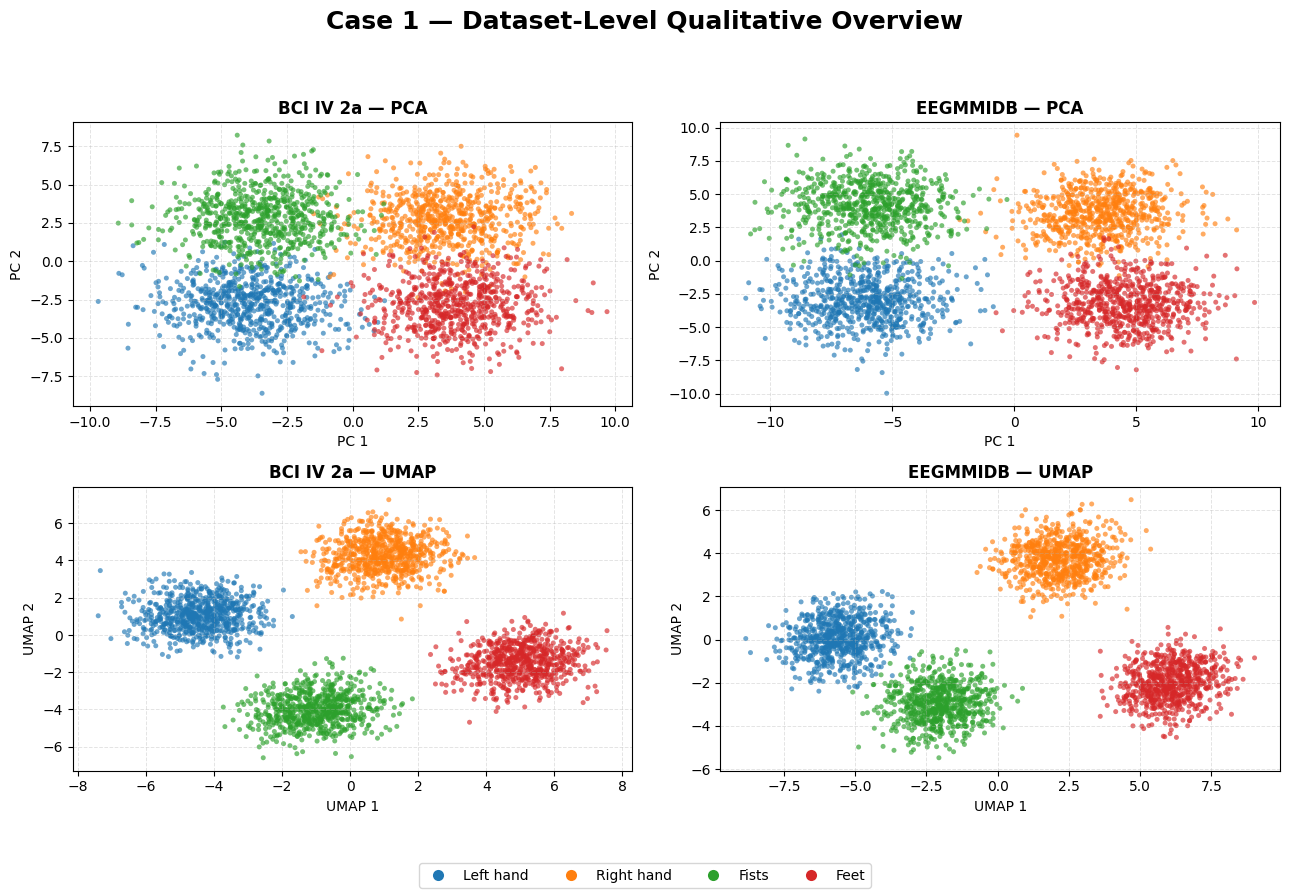

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Dataset-specific differences
bci_pca, bci_y = generate_embedding(
    PCA_CENTERS,
    n_per_class=700,
    class_scale=3.0,
)

eeg_pca, eeg_y = generate_embedding(
    PCA_CENTERS,
    n_per_class=700,
    class_scale=3.0,
    global_shift=(-1.0, 0.3),
    class_shifts=np.array([
        [-1.0, -0.5],
        [ 1.0,  0.5],
        [-1.5,  1.0],
        [ 1.5, -0.8],
    ])
)

bci_umap, _ = generate_embedding(
    UMAP_CENTERS,
    n_per_class=700,
    class_scale=0.9,
)

eeg_umap, _ = generate_embedding(
    UMAP_CENTERS,
    n_per_class=700,
    class_scale=0.9,
    class_shifts=np.array([
        [-1.0, -1.0],
        [ 1.2, -0.6],
        [-1.0,  1.0],
        [ 1.1, -0.5],
    ])
)

scatter_classes(
    axes[0, 0], bci_pca, bci_y,
    "BCI IV 2a — PCA", "PC 1", "PC 2"
)

scatter_classes(
    axes[0, 1], eeg_pca, eeg_y,
    "EEGMMIDB — PCA", "PC 1", "PC 2"
)

scatter_classes(
    axes[1, 0], bci_umap, bci_y,
    "BCI IV 2a — UMAP", "UMAP 1", "UMAP 2"
)

scatter_classes(
    axes[1, 1], eeg_umap, eeg_y,
    "EEGMMIDB — UMAP", "UMAP 1", "UMAP 2"
)

fig.suptitle(
    "Case 1 — Dataset-Level Qualitative Overview",
    fontsize=18,
    fontweight="bold"
)

shared_legend(fig)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()

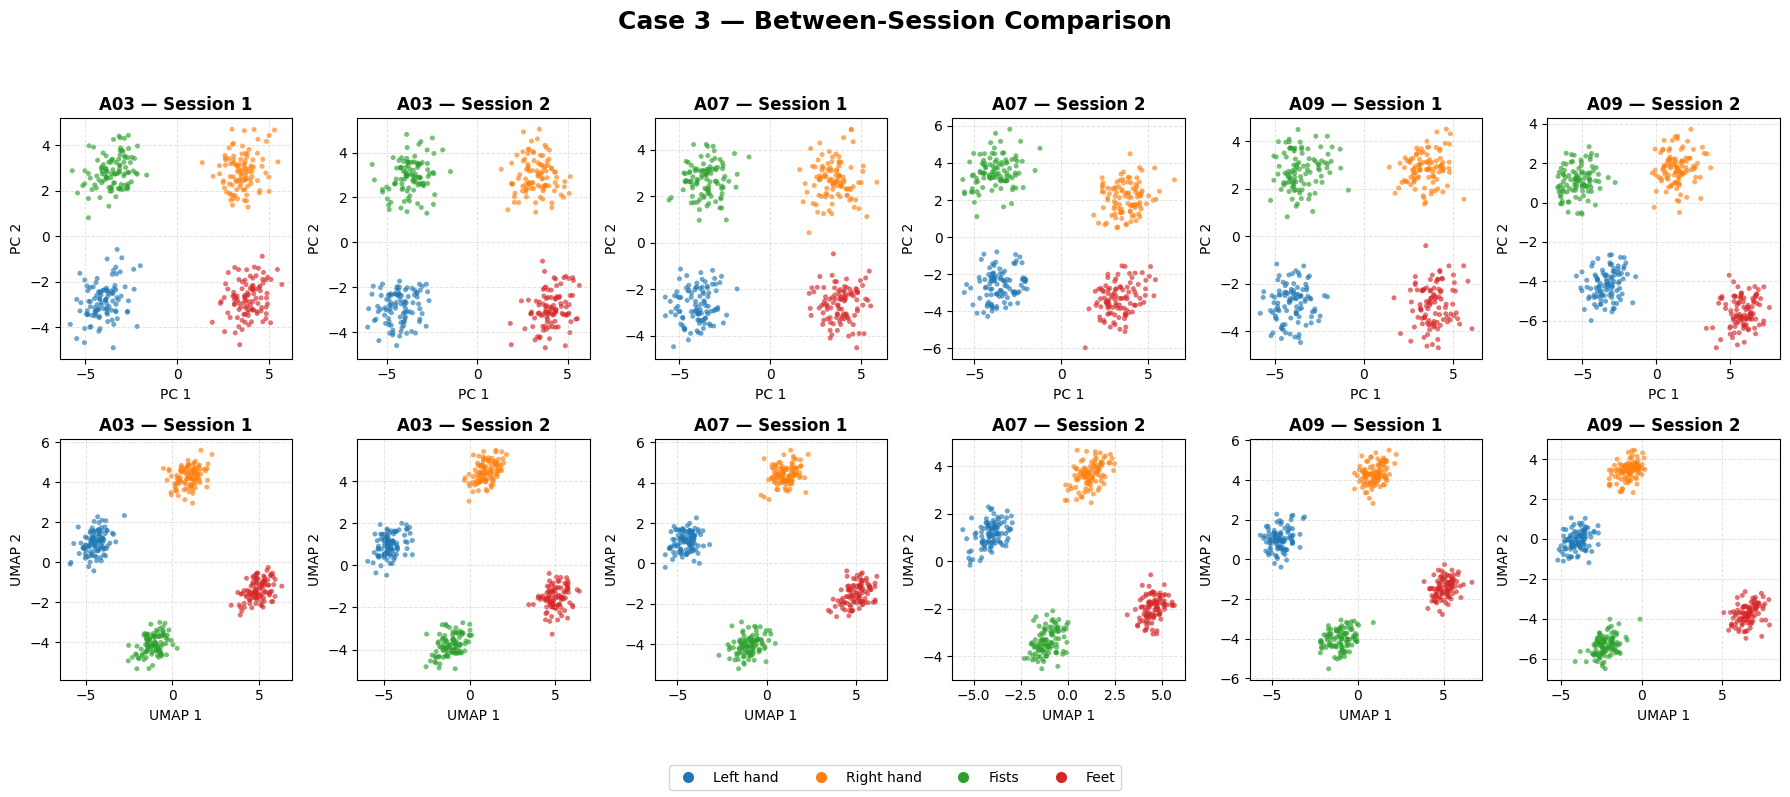

In [69]:
subjects = [
    ("A03", 0.25),
    ("A07", 0.70),
    ("A09", 1.25),
]

fig, axes = plt.subplots(2, 6, figsize=(18, 8))

for i, (subject, shift_strength) in enumerate(subjects):

    session_shift = rng.normal(
        0,
        shift_strength,
        size=(4, 2)
    )

    # PCA
    X1, y = generate_embedding(
        PCA_CENTERS,
        n_per_class=100,
        class_scale=0.65
    )

    X2, _ = generate_embedding(
        PCA_CENTERS,
        n_per_class=100,
        class_scale=0.65,
        class_shifts=session_shift
    )

    # UMAP
    U1, _ = generate_embedding(
        UMAP_CENTERS,
        n_per_class=100,
        class_scale=0.30
    )

    U2, _ = generate_embedding(
        UMAP_CENTERS,
        n_per_class=100,
        class_scale=0.30,
        class_shifts=session_shift * 0.8
    )

    c = i * 2

    scatter_classes(
        axes[0, c], X1, y,
        f"{subject} — Session 1",
        "PC 1", "PC 2"
    )

    scatter_classes(
        axes[0, c + 1], X2, y,
        f"{subject} — Session 2",
        "PC 1", "PC 2"
    )

    scatter_classes(
        axes[1, c], U1, y,
        f"{subject} — Session 1",
        "UMAP 1", "UMAP 2"
    )

    scatter_classes(
        axes[1, c + 1], U2, y,
        f"{subject} — Session 2",
        "UMAP 1", "UMAP 2"
    )

fig.suptitle(
    "Case 3 — Between-Session Comparison",
    fontsize=18,
    fontweight="bold"
)

shared_legend(fig)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()

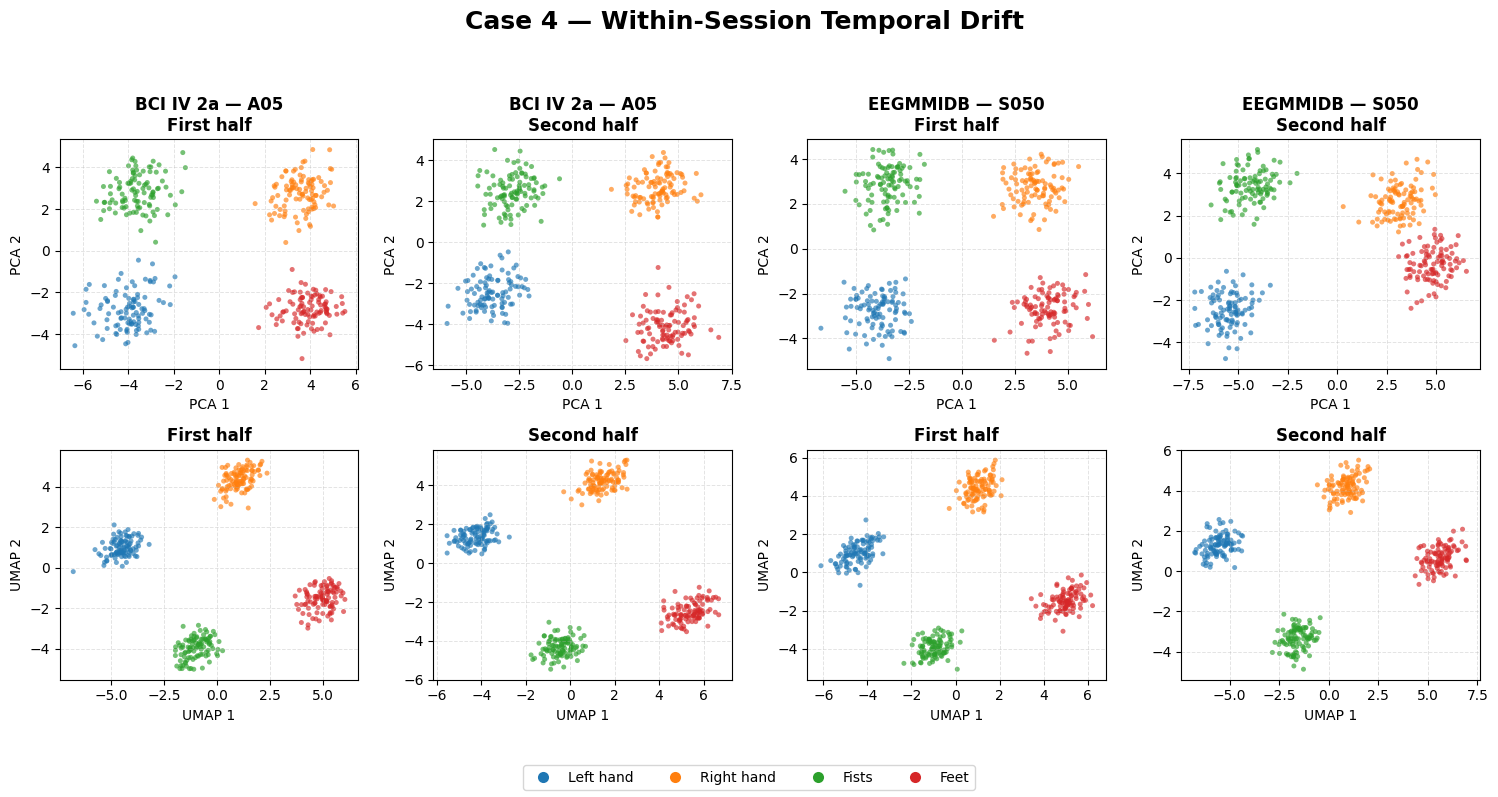

In [70]:
subjects = [
    ("BCI IV 2a", "A05", 0.65),
    ("EEGMMIDB", "S050", 1.00),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for i, (dataset, subject, drift_strength) in enumerate(subjects):

    drift = rng.normal(
        0,
        drift_strength,
        size=(4, 2)
    )

    # First half
    X1, y = generate_embedding(
        PCA_CENTERS,
        n_per_class=100,
        class_scale=0.65
    )

    # Second half of same session
    X2, _ = generate_embedding(
        PCA_CENTERS,
        n_per_class=100,
        class_scale=0.65,
        class_shifts=drift
    )

    U1, _ = generate_embedding(
        UMAP_CENTERS,
        n_per_class=100,
        class_scale=0.30
    )

    U2, _ = generate_embedding(
        UMAP_CENTERS,
        n_per_class=100,
        class_scale=0.30,
        class_shifts=drift * 0.8
    )

    c = i * 2

    scatter_classes(
        axes[0, c], X1, y,
        f"{dataset} — {subject}\nFirst half",
        "PCA 1", "PCA 2"
    )

    scatter_classes(
        axes[0, c + 1], X2, y,
        f"{dataset} — {subject}\nSecond half",
        "PCA 1", "PCA 2"
    )

    scatter_classes(
        axes[1, c], U1, y,
        "First half",
        "UMAP 1", "UMAP 2"
    )

    scatter_classes(
        axes[1, c + 1], U2, y,
        "Second half",
        "UMAP 1", "UMAP 2"
    )

fig.suptitle(
    "Case 4 — Within-Session Temporal Drift",
    fontsize=18,
    fontweight="bold"
)

shared_legend(fig)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()

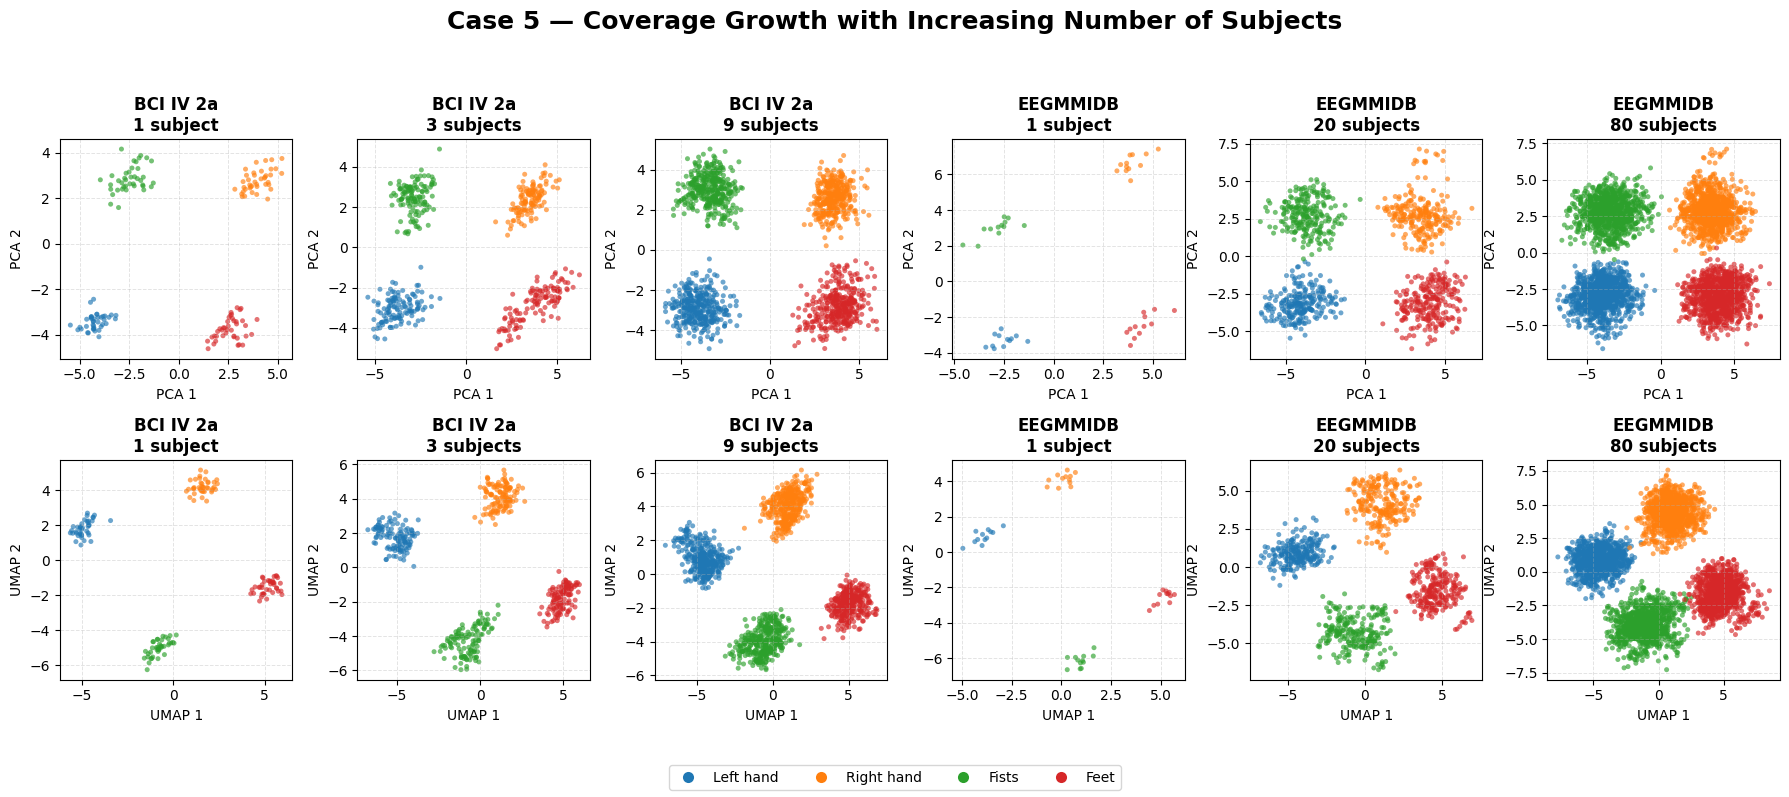

In [71]:
def subject_centers(base_centers, n_subjects, subject_variability):
    centers = []

    for _ in range(n_subjects):
        shifts = rng.normal(
            0,
            subject_variability,
            size=base_centers.shape
        )
        centers.append(base_centers + shifts)

    return centers


def generate_multiple_subjects(
    centers_by_subject,
    n_per_class=35,
    class_scale=0.35
):
    X_all, y_all = [], []

    for centers in centers_by_subject:
        X, y = generate_embedding(
            centers,
            n_per_class=n_per_class,
            class_scale=class_scale
        )

        X_all.append(X)
        y_all.append(y)

    return np.vstack(X_all), np.concatenate(y_all)


BCI_COUNTS = [1, 3, 9]
EEG_COUNTS = [1, 20, 80]

bci_pca_subjects = subject_centers(
    PCA_CENTERS, 9, 0.55
)

bci_umap_subjects = subject_centers(
    UMAP_CENTERS, 9, 0.60
)

eeg_pca_subjects = subject_centers(
    PCA_CENTERS, 80, 0.90
)

eeg_umap_subjects = subject_centers(
    UMAP_CENTERS, 80, 0.95
)

fig, axes = plt.subplots(2, 6, figsize=(18, 8))

# BCI
for col, n_subjects in enumerate(BCI_COUNTS):

    X, y = generate_multiple_subjects(
        bci_pca_subjects[:n_subjects],
        n_per_class=40,
        class_scale=0.30
    )

    U, _ = generate_multiple_subjects(
        bci_umap_subjects[:n_subjects],
        n_per_class=40,
        class_scale=0.22
    )

    scatter_classes(
        axes[0, col],
        X, y,
        f"BCI IV 2a\n{n_subjects} subject{'s' if n_subjects > 1 else ''}",
        "PCA 1", "PCA 2"
    )

    scatter_classes(
        axes[1, col],
        U, y,
        f"BCI IV 2a\n{n_subjects} subject{'s' if n_subjects > 1 else ''}",
        "UMAP 1", "UMAP 2"
    )

# EEGMMIDB
for j, n_subjects in enumerate(EEG_COUNTS):

    col = j + 3

    X, y = generate_multiple_subjects(
        eeg_pca_subjects[:n_subjects],
        n_per_class=12,
        class_scale=0.30
    )

    U, _ = generate_multiple_subjects(
        eeg_umap_subjects[:n_subjects],
        n_per_class=12,
        class_scale=0.22
    )

    scatter_classes(
        axes[0, col],
        X, y,
        f"EEGMMIDB\n{n_subjects} subject{'s' if n_subjects > 1 else ''}",
        "PCA 1", "PCA 2"
    )

    scatter_classes(
        axes[1, col],
        U, y,
        f"EEGMMIDB\n{n_subjects} subject{'s' if n_subjects > 1 else ''}",
        "UMAP 1", "UMAP 2"
    )

fig.suptitle(
    "Case 5 — Coverage Growth with Increasing Number of Subjects",
    fontsize=18,
    fontweight="bold"
)

shared_legend(fig)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()

### Quantitative Domain Analysis

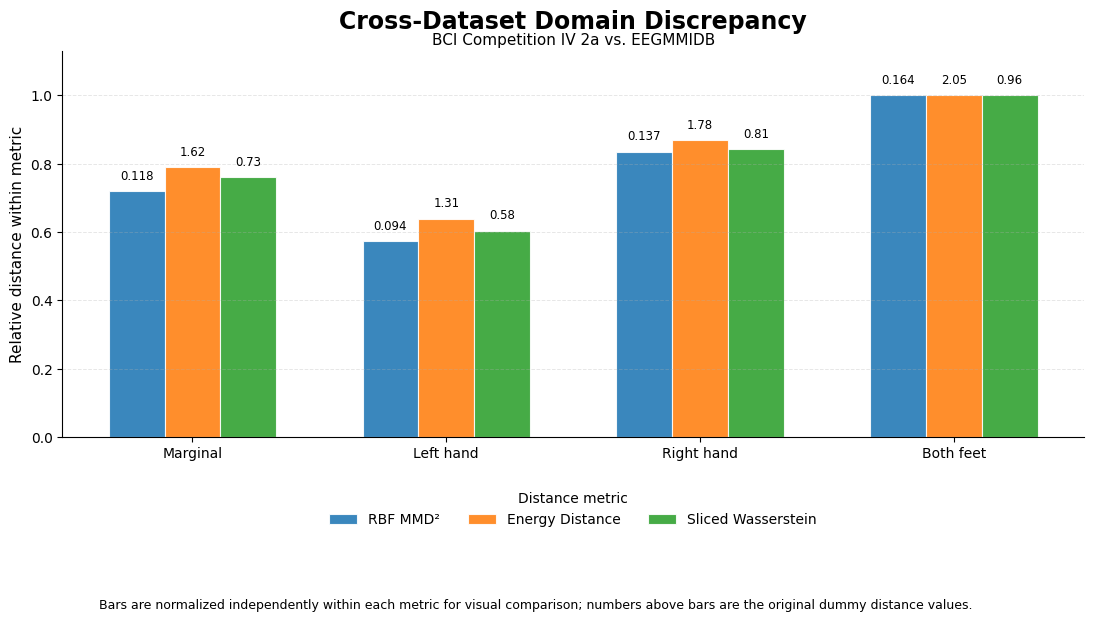

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dummy cross-dataset distance values
# Each metric is normalized by its maximum across comparison types
# ONLY for visualization. Raw values are shown above each marker.
# ------------------------------------------------------------

comparisons = ["Marginal", "Left hand", "Right hand", "Both feet"]

raw = {
    "RBF MMD²": np.array([0.118, 0.094, 0.137, 0.164]),
    "Energy Distance": np.array([1.62, 1.31, 1.78, 2.05]),
    "Sliced Wasserstein": np.array([0.73, 0.58, 0.81, 0.96]),
}

scaled = {
    metric: values / values.max()
    for metric, values in raw.items()
}

x = np.arange(len(comparisons))
width = 0.22

fig, ax = plt.subplots(figsize=(11.5, 6.5))

for i, (metric, values) in enumerate(scaled.items()):
    offset = (i - 1) * width

    bars = ax.bar(
        x + offset,
        values,
        width=width,
        label=metric,
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8,
    )

    # Raw metric values above each bar
    for j, bar in enumerate(bars):
        raw_value = raw[metric][j]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.025,
            f"{raw_value:.3g}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

ax.set_title(
    "Cross-Dataset Domain Discrepancy",
    fontsize=17,
    fontweight="bold",
    pad=16,
)

ax.text(
    0.5,
    1.015,
    "BCI Competition IV 2a vs. EEGMMIDB",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
)

ax.set_ylabel("Relative distance within metric", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(comparisons, fontsize=10)
ax.set_ylim(0, 1.13)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Distance metric",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
)

fig.text(
    0.5,
    0.005,
    "Bars are normalized independently within each metric for visual comparison; "
    "numbers above bars are the original dummy distance values.",
    ha="center",
    fontsize=9,
)

plt.tight_layout(rect=[0.03, 0.08, 0.99, 0.95])

#out = "/mnt/data/cross_dataset_scaled_grouped_distances.png"
#plt.savefig(out, dpi=240, bbox_inches="tight")
plt.show()

#print(out)


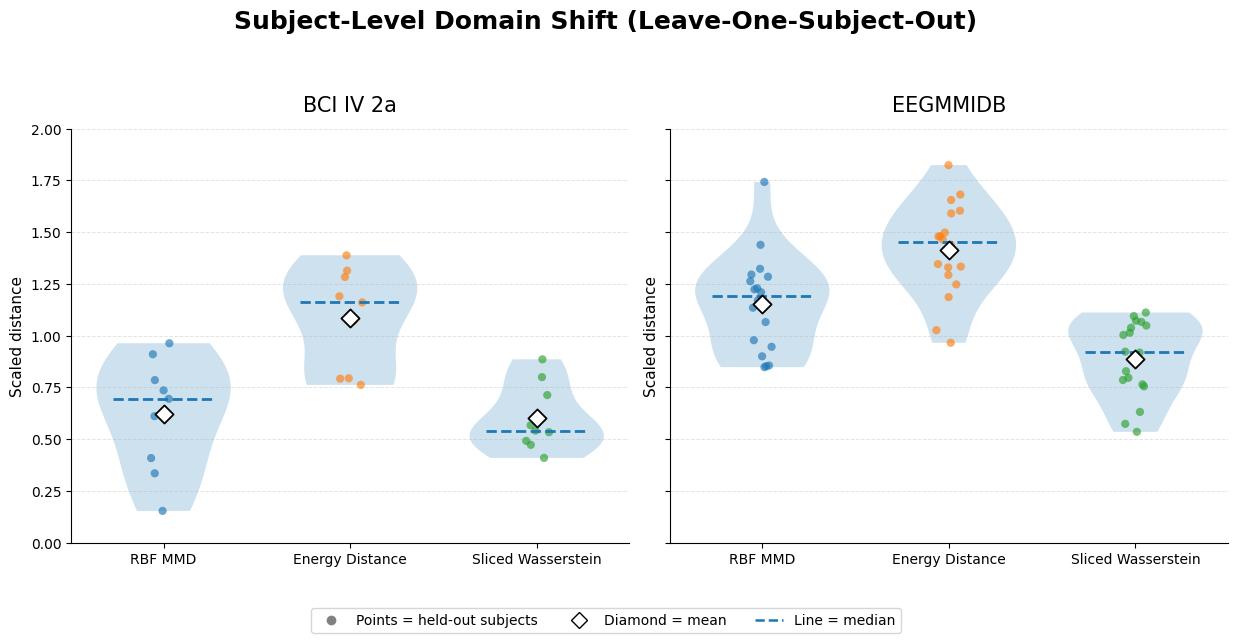

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dummy LOSO domain-shift values
# One point = one held-out subject
# ------------------------------------------------------------

rng = np.random.default_rng(42)

metrics = ["RBF MMD", "Energy Distance", "Sliced Wasserstein"]

bci = [
    np.clip(rng.normal(0.70, 0.28, 9), 0.15, 1.45),
    np.clip(rng.normal(1.05, 0.30, 9), 0.35, 1.70),
    np.clip(rng.normal(0.58, 0.25, 9), 0.10, 1.05),
]

eeg = [
    np.clip(rng.normal(1.10, 0.30, 18), 0.40, 1.80),
    np.clip(rng.normal(1.42, 0.27, 18), 0.75, 1.95),
    np.clip(rng.normal(0.88, 0.27, 18), 0.25, 1.45),
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)

fig.suptitle(
    "Subject-Level Domain Shift (Leave-One-Subject-Out)",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

for ax, dataset_name, data in zip(
    axes,
    ["BCI IV 2a", "EEGMMIDB"],
    [bci, eeg]
):
    positions = np.arange(1, 4)

    # Violin plots
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    # Keep Matplotlib defaults; slightly transparent violins
    for body in parts["bodies"]:
        body.set_alpha(0.22)

    # Individual held-out subjects
    for i, values in enumerate(data, start=1):
        jitter = rng.uniform(-0.07, 0.07, size=len(values))
        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            s=35,
            alpha=0.65,
            edgecolors="none",
            zorder=3,
        )

        # Median
        median = np.median(values)
        ax.hlines(
            median,
            i - 0.27,
            i + 0.27,
            linestyles="--",
            linewidth=2,
            zorder=4,
        )

        # Mean
        mean = np.mean(values)
        ax.scatter(
            i,
            mean,
            marker="D",
            s=85,
            facecolors="white",
            edgecolors="black",
            linewidths=1.3,
            zorder=5,
        )

    ax.set_title(dataset_name, fontsize=15, pad=12)
    ax.set_xticks(positions)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylabel("Scaled distance", fontsize=11)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylim(0, 2.0)

# Shared legend
point_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markerfacecolor="gray",
    markeredgecolor="none",
    markersize=7,
    label="Points = held-out subjects",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=8,
    label="Diamond = mean",
)

median_handle = plt.Line2D(
    [0], [0],
    linestyle="--",
    linewidth=1.8,
    label="Line = median",
)

fig.legend(
    handles=[point_handle, mean_handle, median_handle],
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01),
)

plt.tight_layout(rect=[0.03, 0.10, 0.99, 0.93])
plt.show()


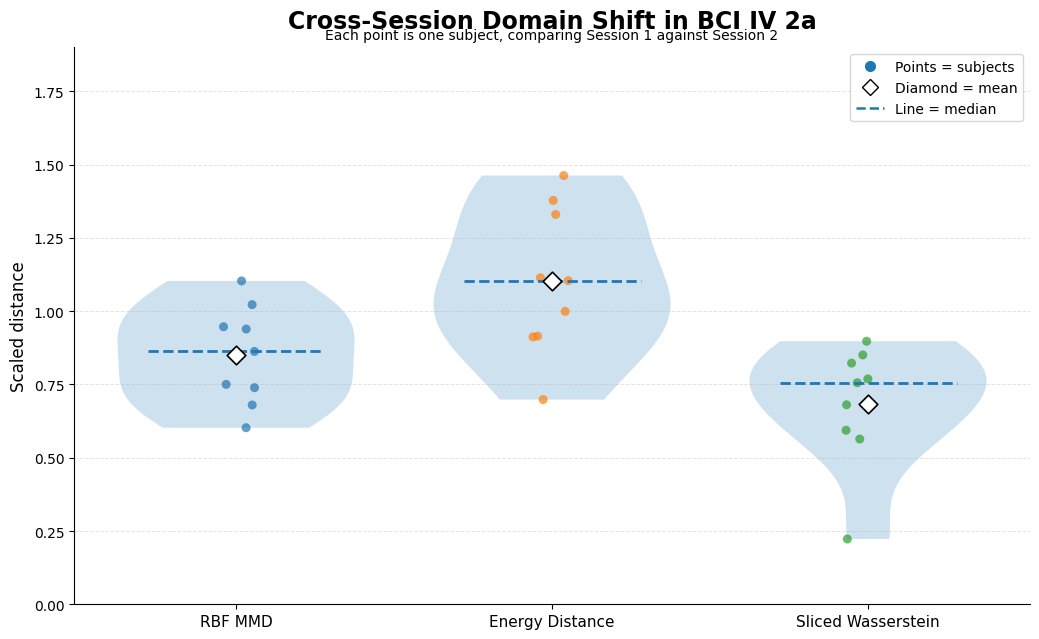

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dummy cross-session domain-shift values
# One point = one subject, comparing session 1 vs session 2
# ------------------------------------------------------------

rng = np.random.default_rng(123)

subjects = [f"A{i:02d}" for i in range(1, 10)]
metrics = ["RBF MMD", "Energy Distance", "Sliced Wasserstein"]

metric_values = [
    np.clip(rng.normal(0.82, 0.22, len(subjects)), 0.20, 1.40),
    np.clip(rng.normal(1.08, 0.25, len(subjects)), 0.35, 1.75),
    np.clip(rng.normal(0.62, 0.18, len(subjects)), 0.15, 1.15),
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.5))

positions = np.arange(1, len(metrics) + 1)

parts = ax.violinplot(
    metric_values,
    positions=positions,
    widths=0.75,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body in parts["bodies"]:
    body.set_alpha(0.22)

# Subject-level points + summary statistics
for i, values in enumerate(metric_values, start=1):

    jitter = rng.uniform(-0.07, 0.07, size=len(values))

    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        s=42,
        alpha=0.70,
        edgecolors="none",
        zorder=3,
    )

    # Median
    median = np.median(values)

    ax.hlines(
        median,
        i - 0.28,
        i + 0.28,
        linestyles="--",
        linewidth=2.0,
        zorder=4,
    )

    # Mean
    mean = np.mean(values)

    ax.scatter(
        i,
        mean,
        marker="D",
        s=90,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    "Cross-Session Domain Shift in BCI IV 2a",
    fontsize=17,
    fontweight="bold",
    pad=14,
)

ax.text(
    0.5,
    1.01,
    "Each point is one subject, comparing Session 1 against Session 2",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_xticks(positions)
ax.set_xticklabels(metrics, fontsize=11)

ax.set_ylabel("Scaled distance", fontsize=12)
ax.set_ylim(0, 1.9)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

point_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markersize=7,
    label="Points = subjects",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=8,
    label="Diamond = mean",
)

median_handle = plt.Line2D(
    [0], [0],
    linestyle="--",
    linewidth=1.8,
    label="Line = median",
)

ax.legend(
    handles=[
        point_handle,
        mean_handle,
        median_handle
    ],
    loc="upper right",
    frameon=True,
)

plt.tight_layout()
plt.show()

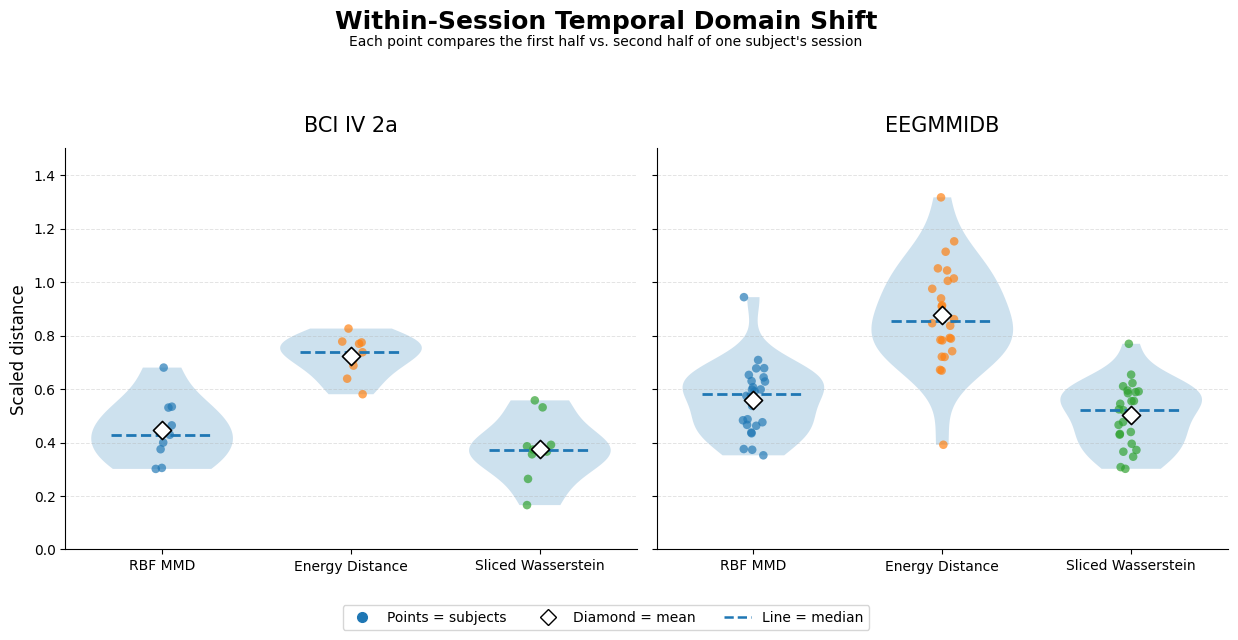

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dummy within-session domain-shift values
# One point = one subject, comparing the first half vs. second
# half of trials within the same recording session.
# ------------------------------------------------------------

rng = np.random.default_rng(321)

metrics = ["RBF MMD", "Energy Distance", "Sliced Wasserstein"]

# BCI IV 2a: 9 subjects
bci = [
    np.clip(rng.normal(0.48, 0.12, 9), 0.15, 0.85),
    np.clip(rng.normal(0.72, 0.16, 9), 0.30, 1.10),
    np.clip(rng.normal(0.39, 0.10, 9), 0.10, 0.70),
]

# EEGMMIDB: use a representative subset of subjects for the dummy figure
eeg = [
    np.clip(rng.normal(0.58, 0.15, 24), 0.18, 0.95),
    np.clip(rng.normal(0.86, 0.20, 24), 0.35, 1.35),
    np.clip(rng.normal(0.47, 0.13, 24), 0.12, 0.85),
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6.5),
    sharey=True
)

fig.suptitle(
    "Within-Session Temporal Domain Shift",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

for ax, dataset_name, data in zip(
    axes,
    ["BCI IV 2a", "EEGMMIDB"],
    [bci, eeg]
):
    positions = np.arange(1, len(metrics) + 1)

    # Violin distributions
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.75,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body in parts["bodies"]:
        body.set_alpha(0.22)

    # Subject-level points + summaries
    for i, values in enumerate(data, start=1):

        jitter = rng.uniform(-0.07, 0.07, size=len(values))

        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            s=38,
            alpha=0.68,
            edgecolors="none",
            zorder=3,
        )

        # Median
        median = np.median(values)

        ax.hlines(
            median,
            i - 0.27,
            i + 0.27,
            linestyles="--",
            linewidth=2,
            zorder=4,
        )

        # Mean
        mean = np.mean(values)

        ax.scatter(
            i,
            mean,
            marker="D",
            s=85,
            facecolors="white",
            edgecolors="black",
            linewidths=1.2,
            zorder=5,
        )

    ax.set_title(
        dataset_name,
        fontsize=15,
        pad=12
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(metrics, fontsize=10)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Scaled distance", fontsize=12)
axes[0].set_ylim(0, 1.5)

# Subtitle
fig.text(
    0.5,
    0.925,
    "Each point compares the first half vs. second half of one subject's session",
    ha="center",
    fontsize=10
)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

point_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markersize=7,
    label="Points = subjects",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=8,
    label="Diamond = mean",
)

median_handle = plt.Line2D(
    [0], [0],
    linestyle="--",
    linewidth=1.8,
    label="Line = median",
)

fig.legend(
    handles=[
        point_handle,
        mean_handle,
        median_handle,
    ],
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

plt.tight_layout(rect=[0.03, 0.09, 0.99, 0.90])
plt.show()


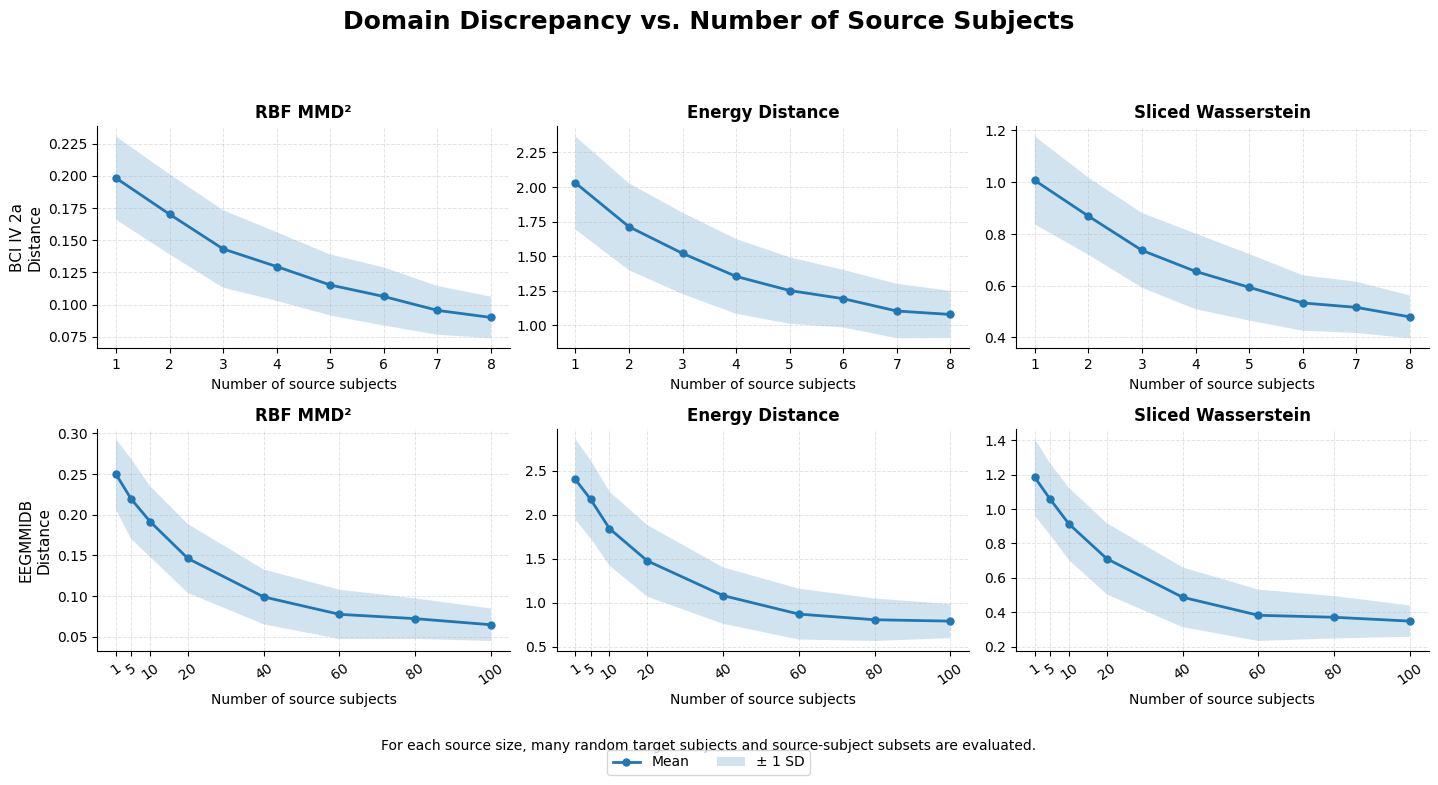

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative domain analysis:
# Domain discrepancy vs. number of source subjects
#
# For each source size k:
#   1. Randomly choose a target subject t
#   2. Randomly choose k source subjects from the remaining subjects
#   3. Compute a source-pool -> target distance
#   4. Repeat many times
#
# Here we simulate those distances with dummy data.
# The real experiment would replace simulate_runs(...) with
# the actual distance computation.
# ============================================================

rng = np.random.default_rng(42)

metrics = {
    "RBF MMD²": {
        "BCI IV 2a": (0.20, 0.075),
        "EEGMMIDB": (0.25, 0.065),
    },
    "Energy Distance": {
        "BCI IV 2a": (2.00, 0.90),
        "EEGMMIDB": (2.40, 0.78),
    },
    "Sliced Wasserstein": {
        "BCI IV 2a": (1.00, 0.40),
        "EEGMMIDB": (1.20, 0.34),
    },
}

# Maximum usable source-subject count when one target is held out
source_sizes = {
    "BCI IV 2a": np.arange(1, 9),                  # 9 subjects total
    "EEGMMIDB": np.array([1, 5, 10, 20, 40, 60, 80, 100]),  # 109 total
}

N_REPEATS = 250


def simulate_runs(k_values, start, floor, n_repeats, dataset):
    """
    Dummy generator representing repeated random:
        target subject + source subset of size k.

    As k increases:
      - expected discrepancy decreases;
      - variability also decreases because the pooled source
        becomes less sensitive to the exact selected subjects.
    """
    results = []

    max_k = max(k_values)

    for k in k_values:
        # Smooth expected convergence
        if dataset == "BCI IV 2a":
            decay = np.exp(-0.28 * (k - 1))
        else:
            decay = np.exp(-0.045 * (k - 1))

        mean_distance = floor + (start - floor) * decay

        # Variability from:
        #   - which target subject was selected
        #   - which source subset was selected
        relative_k = k / max_k
        sd = (0.16 * start) * (1 - 0.65 * relative_k) + 0.025 * start

        values = rng.normal(mean_distance, sd, n_repeats)
        values = np.clip(values, 0, None)

        results.append(values)

    return results


# ============================================================
# Generate dummy repeated-run distributions
# ============================================================

results = {}

for metric, dataset_params in metrics.items():
    results[metric] = {}

    for dataset, (start, floor) in dataset_params.items():
        results[metric][dataset] = simulate_runs(
            source_sizes[dataset],
            start=start,
            floor=floor,
            n_repeats=N_REPEATS,
            dataset=dataset,
        )


# ============================================================
# Plot: rows = datasets, columns = distance metrics
# Line = mean
# Shaded band = mean ± 1 standard deviation
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8),
)

fig.suptitle(
    "Domain Discrepancy vs. Number of Source Subjects",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

datasets = ["BCI IV 2a", "EEGMMIDB"]

for row, dataset in enumerate(datasets):

    for col, metric in enumerate(metrics.keys()):

        ax = axes[row, col]

        k_values = source_sizes[dataset]
        distributions = results[metric][dataset]

        means = np.array([
            np.mean(values)
            for values in distributions
        ])

        stds = np.array([
            np.std(values, ddof=1)
            for values in distributions
        ])

        # Mean curve
        ax.plot(
            k_values,
            means,
            marker="o",
            linewidth=2,
            markersize=5,
            label="Mean",
        )

        # Variability band
        ax.fill_between(
            k_values,
            np.maximum(0, means - stds),
            means + stds,
            alpha=0.20,
            label="± 1 SD",
        )

        ax.set_title(
            metric,
            fontsize=12,
            fontweight="bold",
        )

        ax.set_xlabel(
            "Number of source subjects",
            fontsize=10,
        )

        if col == 0:
            ax.set_ylabel(
                f"{dataset}\nDistance",
                fontsize=11,
            )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Dataset-appropriate x ticks
        ax.set_xticks(k_values)

        # Avoid overcrowding EEG tick labels
        if dataset == "EEGMMIDB":
            ax.tick_params(axis="x", labelrotation=35)

# One shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

fig.text(
    0.5,
    0.055,
    "For each source size, many random target subjects and source-subject subsets are evaluated.",
    ha="center",
    fontsize=10,
)

plt.tight_layout(rect=[0.03, 0.09, 0.99, 0.93])
plt.show()


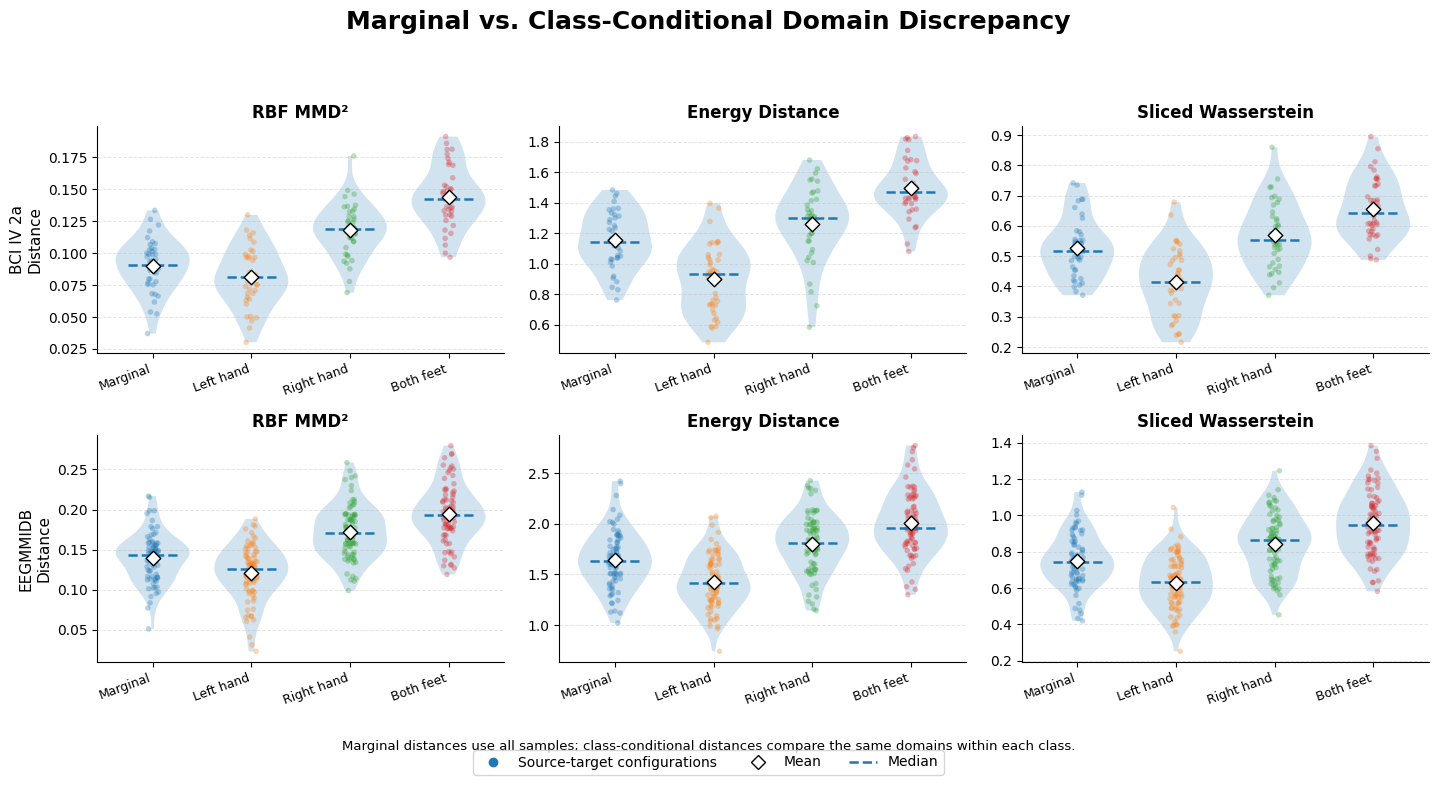

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative domain analysis:
# Marginal vs. class-conditional domain discrepancy
#
# Each distribution represents many source-target configurations.
# For the same configuration we compute:
#   - Marginal distance: D(Ps(X), Pt(X))
#   - Class-conditional distances:
#       D(Ps(X|Y=c), Pt(X|Y=c))
#
# Dummy data are used here only to design the figure.
# ============================================================

rng = np.random.default_rng(7)

comparison_types = [
    "Marginal",
    "Left hand",
    "Right hand",
    "Both feet",
]

metrics = [
    "RBF MMD²",
    "Energy Distance",
    "Sliced Wasserstein",
]

# Number of dummy source-target configurations
n_configs = {
    "BCI IV 2a": 40,
    "EEGMMIDB": 80,
}

# Approximate dummy means for each comparison type
dummy_means = {
    "BCI IV 2a": {
        "RBF MMD²":          [0.10, 0.08, 0.12, 0.15],
        "Energy Distance":   [1.15, 0.95, 1.30, 1.48],
        "Sliced Wasserstein":[0.52, 0.43, 0.58, 0.69],
    },
    "EEGMMIDB": {
        "RBF MMD²":          [0.15, 0.12, 0.17, 0.20],
        "Energy Distance":   [1.65, 1.38, 1.82, 2.02],
        "Sliced Wasserstein":[0.76, 0.62, 0.84, 0.96],
    },
}

dummy_sds = {
    "BCI IV 2a": {
        "RBF MMD²":           0.025,
        "Energy Distance":    0.22,
        "Sliced Wasserstein": 0.11,
    },
    "EEGMMIDB": {
        "RBF MMD²":           0.035,
        "Energy Distance":    0.30,
        "Sliced Wasserstein": 0.15,
    },
}

# ============================================================
# Generate dummy distributions
# ============================================================

results = {}

for dataset in n_configs:
    results[dataset] = {}

    for metric in metrics:
        results[dataset][metric] = []

        for mean in dummy_means[dataset][metric]:
            values = rng.normal(
                mean,
                dummy_sds[dataset][metric],
                n_configs[dataset],
            )
            results[dataset][metric].append(
                np.clip(values, 0, None)
            )

# ============================================================
# Plot
# Rows = datasets
# Columns = discrepancy metrics
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8),
)

fig.suptitle(
    "Marginal vs. Class-Conditional Domain Discrepancy",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

datasets = ["BCI IV 2a", "EEGMMIDB"]

for row, dataset in enumerate(datasets):

    for col, metric in enumerate(metrics):

        ax = axes[row, col]
        data = results[dataset][metric]
        positions = np.arange(1, len(comparison_types) + 1)

        # Violin distributions
        parts = ax.violinplot(
            data,
            positions=positions,
            widths=0.75,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_alpha(0.20)

        # Individual configurations + mean + median
        for i, values in enumerate(data, start=1):

            jitter = rng.uniform(
                -0.06,
                0.06,
                size=len(values),
            )

            ax.scatter(
                np.full(len(values), i) + jitter,
                values,
                s=16,
                alpha=0.32,
                edgecolors="none",
                zorder=3,
            )

            # Median
            ax.hlines(
                np.median(values),
                i - 0.25,
                i + 0.25,
                linestyles="--",
                linewidth=1.8,
                zorder=4,
            )

            # Mean
            ax.scatter(
                i,
                np.mean(values),
                marker="D",
                s=55,
                facecolors="white",
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )

        ax.set_title(
            metric,
            fontsize=12,
            fontweight="bold",
        )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            comparison_types,
            rotation=20,
            ha="right",
            fontsize=9,
        )

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if col == 0:
            ax.set_ylabel(
                f"{dataset}\nDistance",
                fontsize=11,
            )

# Shared legend
point_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markersize=6,
    label="Source-target configurations",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=7,
    label="Mean",
)

median_handle = plt.Line2D(
    [0], [0],
    linestyle="--",
    linewidth=1.8,
    label="Median",
)

fig.legend(
    handles=[point_handle, mean_handle, median_handle],
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

fig.text(
    0.5,
    0.055,
    "Marginal distances use all samples; class-conditional distances compare the same domains within each class.",
    ha="center",
    fontsize=9.5,
)

plt.tight_layout(rect=[0.03, 0.09, 0.99, 0.93])
plt.show()


### Quantitative Learning Analysis

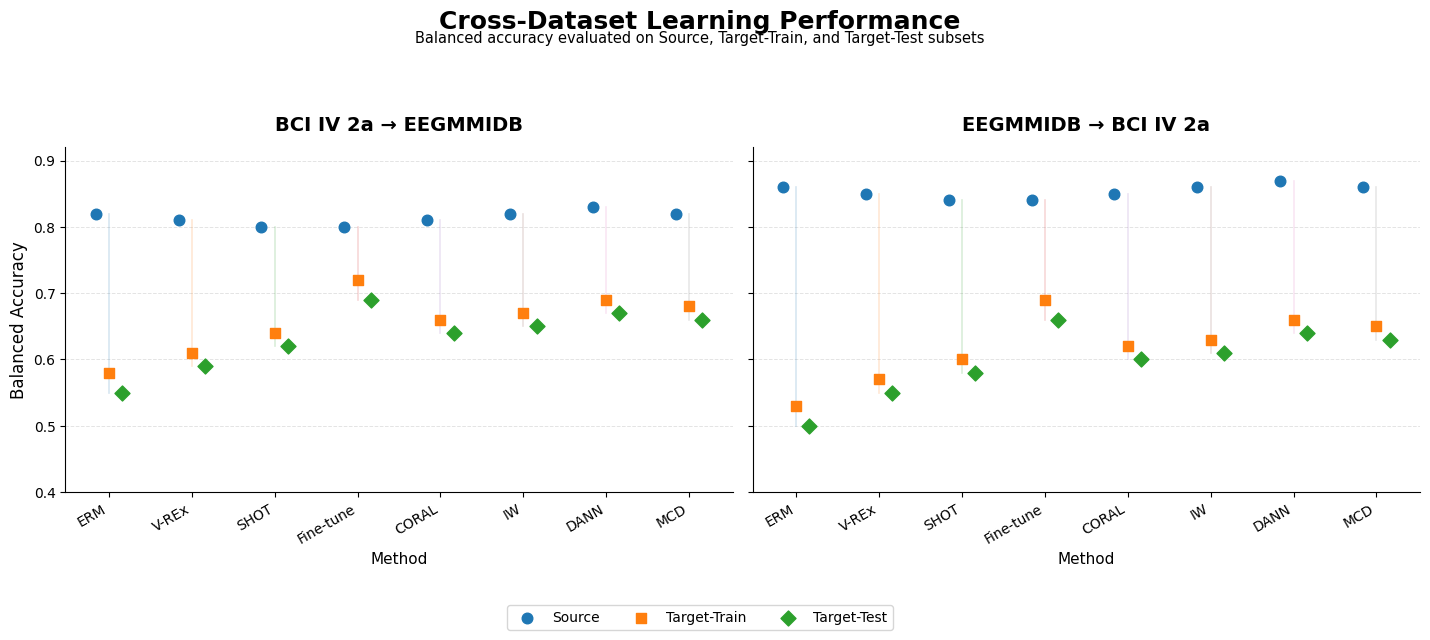

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative learning analysis — Plot 1
# Cross-dataset performance
#
# All methods are evaluated in the same way after training:
#   - Source
#   - Target-Train
#   - Target-Test
#
# Dummy values are used only to design the figure.
# ============================================================

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

# Dummy balanced-accuracy values
results = {
    "BCI IV 2a → EEGMMIDB": {
        "Source":       [0.82, 0.81, 0.80, 0.80, 0.81, 0.82, 0.83, 0.82],
        "Target-Train": [0.58, 0.61, 0.64, 0.72, 0.66, 0.67, 0.69, 0.68],
        "Target-Test":  [0.55, 0.59, 0.62, 0.69, 0.64, 0.65, 0.67, 0.66],
    },
    "EEGMMIDB → BCI IV 2a": {
        "Source":       [0.86, 0.85, 0.84, 0.84, 0.85, 0.86, 0.87, 0.86],
        "Target-Train": [0.53, 0.57, 0.60, 0.69, 0.62, 0.63, 0.66, 0.65],
        "Target-Test":  [0.50, 0.55, 0.58, 0.66, 0.60, 0.61, 0.64, 0.63],
    },
}

# ============================================================
# Plot
# A connected-dot design makes Source -> Target-Train ->
# Target-Test changes easy to see without overcrowding bars.
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6.5),
    sharey=True,
)

fig.suptitle(
    "Cross-Dataset Learning Performance",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.93,
    "Balanced accuracy evaluated on Source, Target-Train, and Target-Test subsets",
    ha="center",
    fontsize=10.5,
)

x = np.arange(len(methods))

subset_markers = {
    "Source": "o",
    "Target-Train": "s",
    "Target-Test": "D",
}

for ax, (direction, values) in zip(axes, results.items()):

    # faint method-wise connectors to show the performance profile
    for i in range(len(methods)):
        profile = [
            values["Source"][i],
            values["Target-Train"][i],
            values["Target-Test"][i],
        ]

        ax.plot(
            [i, i, i],
            [min(profile), max(profile), max(profile)],
            alpha=0.18,
            linewidth=1.2,
        )

    # subset points
    offsets = {
        "Source": -0.16,
        "Target-Train": 0.00,
        "Target-Test": 0.16,
    }

    for subset in ["Source", "Target-Train", "Target-Test"]:
        ax.scatter(
            x + offsets[subset],
            values[subset],
            marker=subset_markers[subset],
            s=58,
            label=subset,
            zorder=3,
        )

    ax.set_title(
        direction,
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        methods,
        rotation=30,
        ha="right",
        fontsize=10,
    )

    ax.set_xlabel("Method", fontsize=11)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    "Balanced Accuracy",
    fontsize=12,
)

axes[0].set_ylim(0.40, 0.92)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

plt.tight_layout(rect=[0.03, 0.10, 0.99, 0.90])
plt.show()


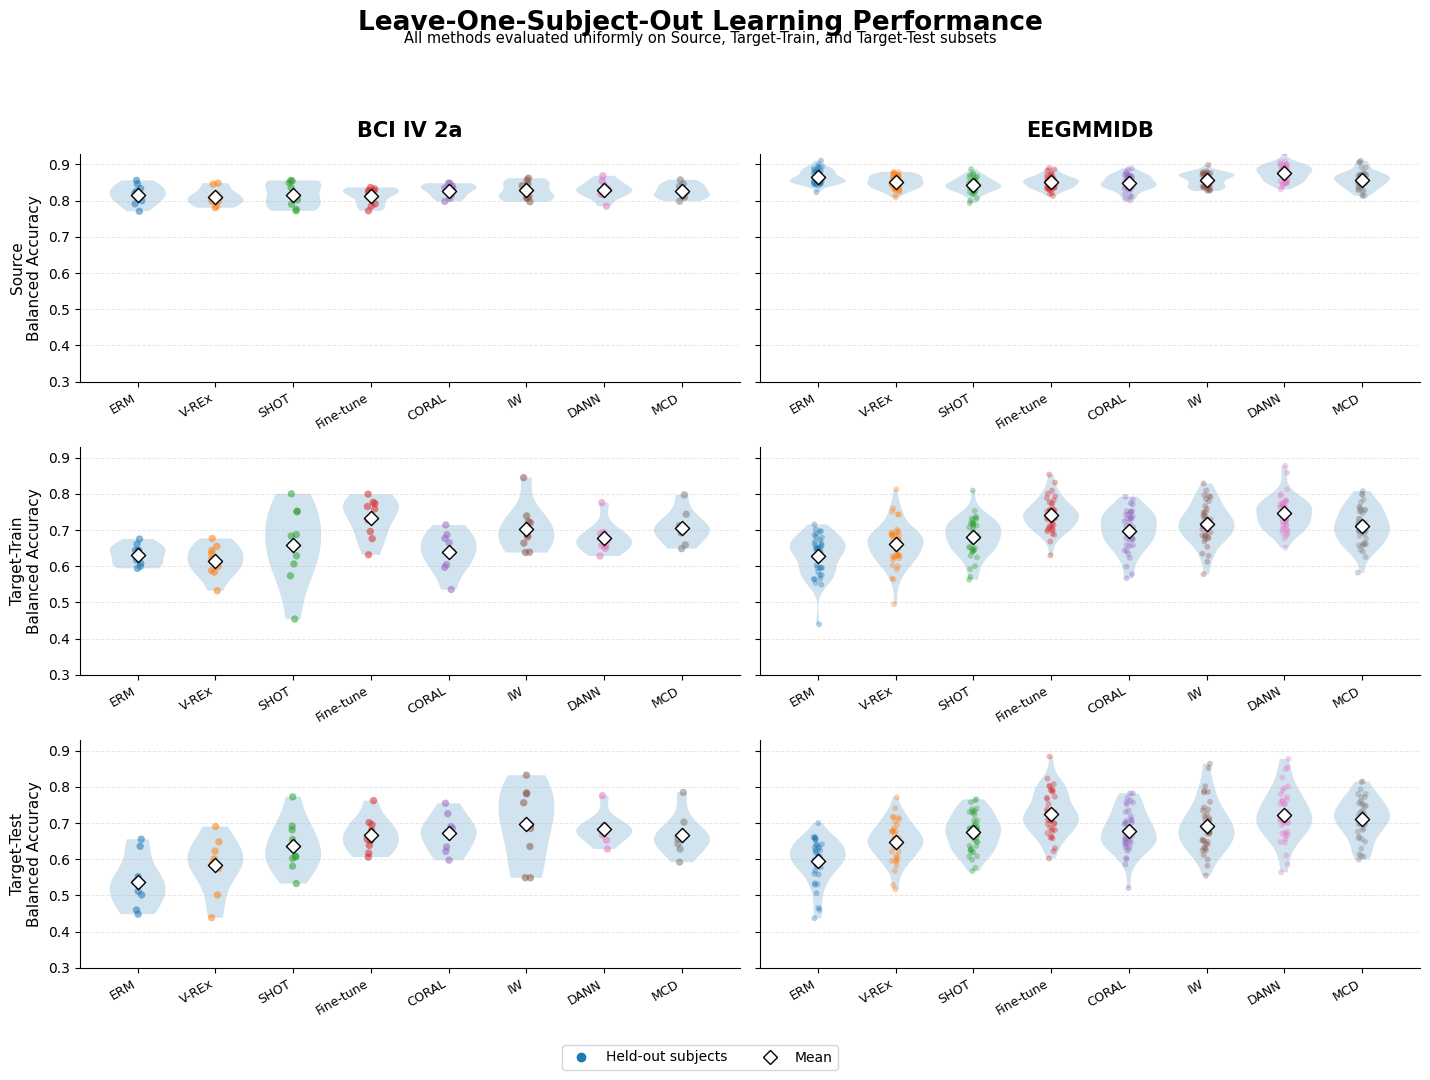

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative learning analysis — Plot 2
# LOSO performance distributions
#
# All trained methods are evaluated uniformly on:
#   1. Source
#   2. Target-Train
#   3. Target-Test
#
# One point = one held-out target subject.
# Dummy values are used only to design the figure.
# ============================================================

rng = np.random.default_rng(84)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

subsets = ["Source", "Target-Train", "Target-Test"]

# Number of LOSO evaluations
n_subjects = {
    "BCI IV 2a": 9,
    "EEGMMIDB": 40,   # illustrative subset for the mock figure
}

# Dummy method means for each evaluation subset
means = {
    "BCI IV 2a": {
        "Source":       [0.83, 0.82, 0.81, 0.82, 0.82, 0.83, 0.84, 0.83],
        "Target-Train": [0.59, 0.62, 0.65, 0.73, 0.67, 0.68, 0.70, 0.69],
        "Target-Test":  [0.56, 0.60, 0.63, 0.70, 0.65, 0.66, 0.68, 0.67],
    },
    "EEGMMIDB": {
        "Source":       [0.86, 0.85, 0.84, 0.85, 0.85, 0.86, 0.87, 0.86],
        "Target-Train": [0.64, 0.67, 0.69, 0.75, 0.70, 0.71, 0.74, 0.72],
        "Target-Test":  [0.61, 0.65, 0.67, 0.72, 0.68, 0.69, 0.71, 0.70],
    },
}

# Typical across-subject variability for each subset
stds = {
    "BCI IV 2a": {
        "Source": 0.025,
        "Target-Train": 0.060,
        "Target-Test": 0.070,
    },
    "EEGMMIDB": {
        "Source": 0.020,
        "Target-Train": 0.050,
        "Target-Test": 0.060,
    },
}

# ============================================================
# Generate dummy LOSO results
# ============================================================

results = {}

for dataset in n_subjects:
    results[dataset] = {}

    for subset in subsets:
        results[dataset][subset] = []

        for method_mean in means[dataset][subset]:
            values = rng.normal(
                method_mean,
                stds[dataset][subset],
                n_subjects[dataset],
            )

            results[dataset][subset].append(
                np.clip(values, 0.30, 0.95)
            )

# ============================================================
# Plot
# Rows = evaluation subset
# Columns = dataset
# ============================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 11),
    sharey="row",
)

fig.suptitle(
    "Leave-One-Subject-Out Learning Performance",
    fontsize=19,
    fontweight="bold",
    y=0.985,
)

fig.text(
    0.5,
    0.955,
    "All methods evaluated uniformly on Source, Target-Train, and Target-Test subsets",
    ha="center",
    fontsize=10.5,
)

positions = np.arange(1, len(methods) + 1)

for row, subset in enumerate(subsets):

    for col, dataset in enumerate(["BCI IV 2a", "EEGMMIDB"]):

        ax = axes[row, col]
        data = results[dataset][subset]

        # Violin distributions
        parts = ax.violinplot(
            data,
            positions=positions,
            widths=0.72,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_alpha(0.20)

        # Held-out subject results + mean
        for i, values in enumerate(data, start=1):

            jitter = rng.uniform(
                -0.055,
                0.055,
                size=len(values),
            )

            ax.scatter(
                np.full(len(values), i) + jitter,
                values,
                s=18 if dataset == "EEGMMIDB" else 28,
                alpha=0.35 if dataset == "EEGMMIDB" else 0.55,
                edgecolors="none",
                zorder=3,
            )

            # Mean
            ax.scatter(
                i,
                np.mean(values),
                marker="D",
                s=52,
                facecolors="white",
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )

        # Column titles only once
        if row == 0:
            ax.set_title(
                dataset,
                fontsize=15,
                fontweight="bold",
                pad=12,
            )

        # Row label
        if col == 0:
            ax.set_ylabel(
                f"{subset}\nBalanced Accuracy",
                fontsize=11,
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            methods,
            rotation=30,
            ha="right",
            fontsize=9,
        )

        ax.set_ylim(0.30, 0.93)

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.30,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Shared legend
subject_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markersize=6,
    label="Held-out subjects",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=7,
    label="Mean",
)

fig.legend(
    handles=[subject_handle, mean_handle],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

plt.tight_layout(rect=[0.03, 0.055, 0.99, 0.935])
plt.show()


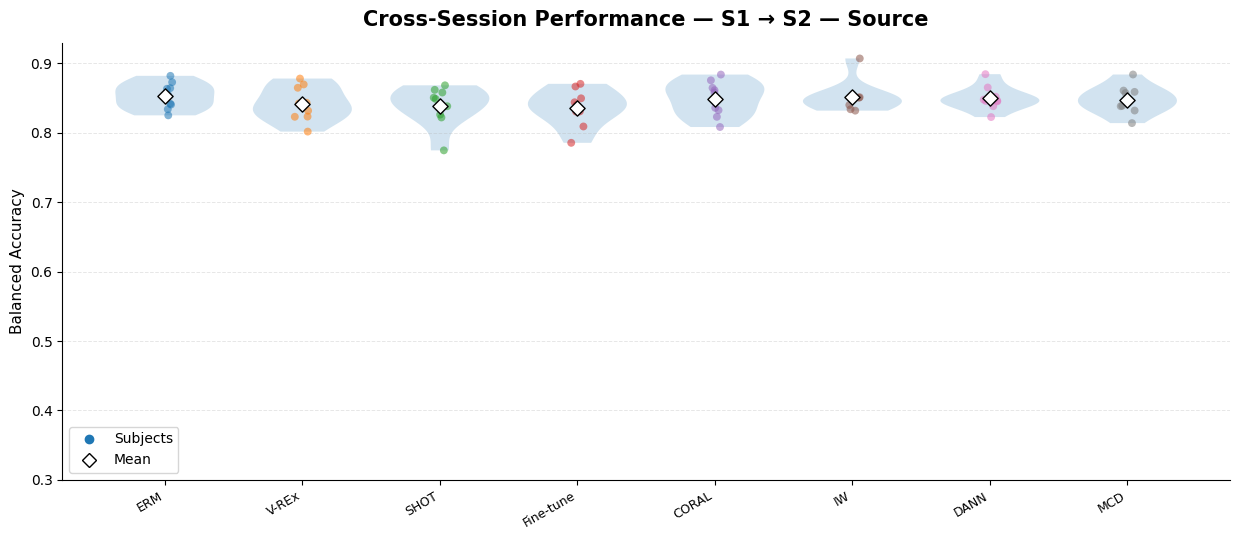

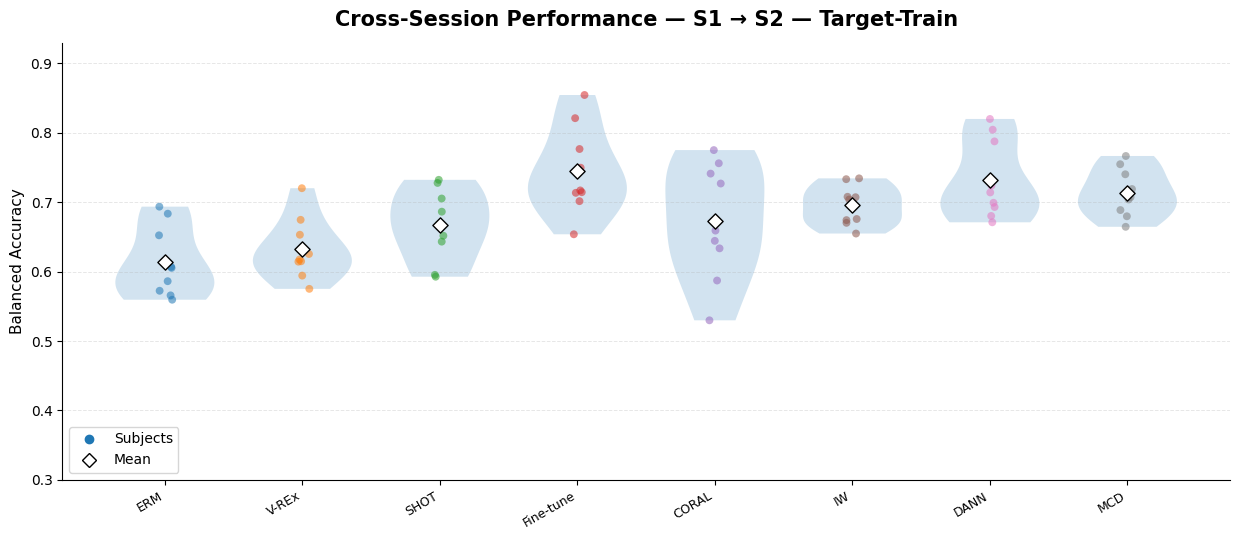

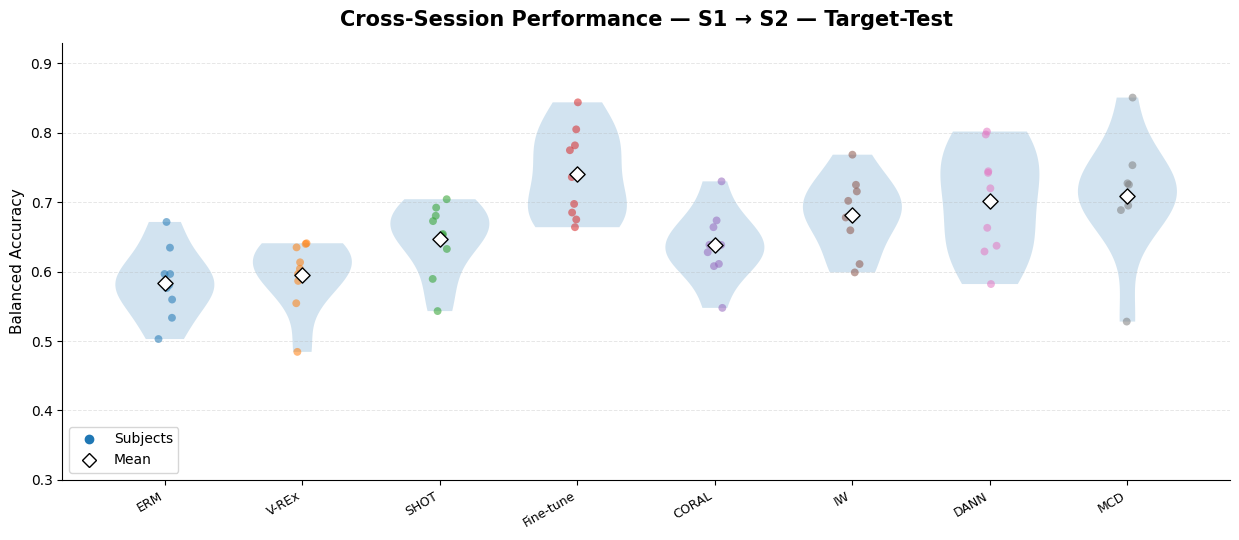

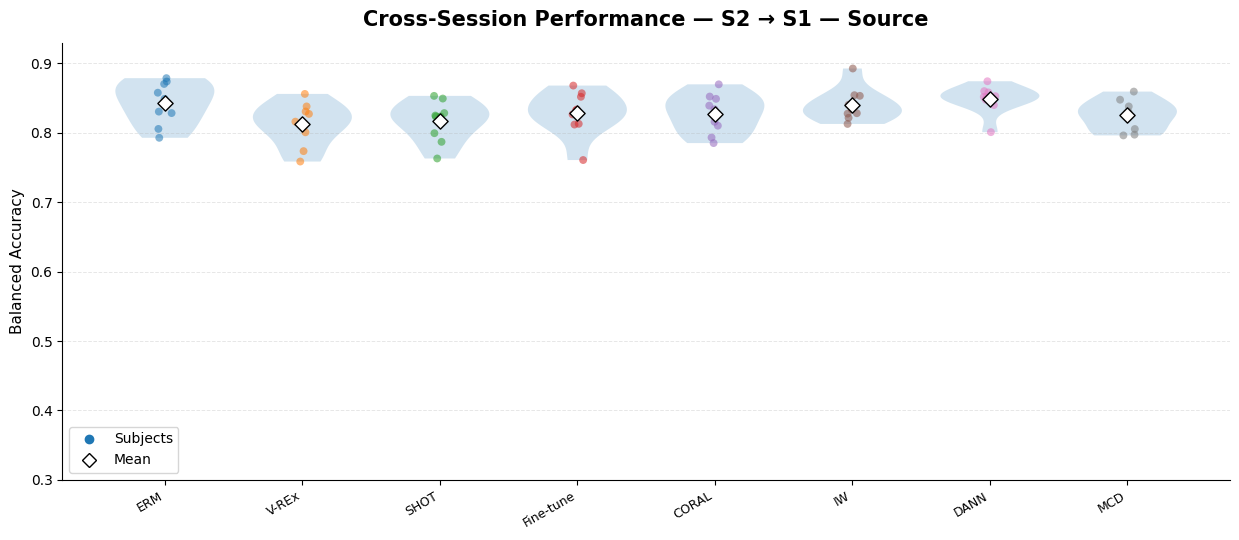

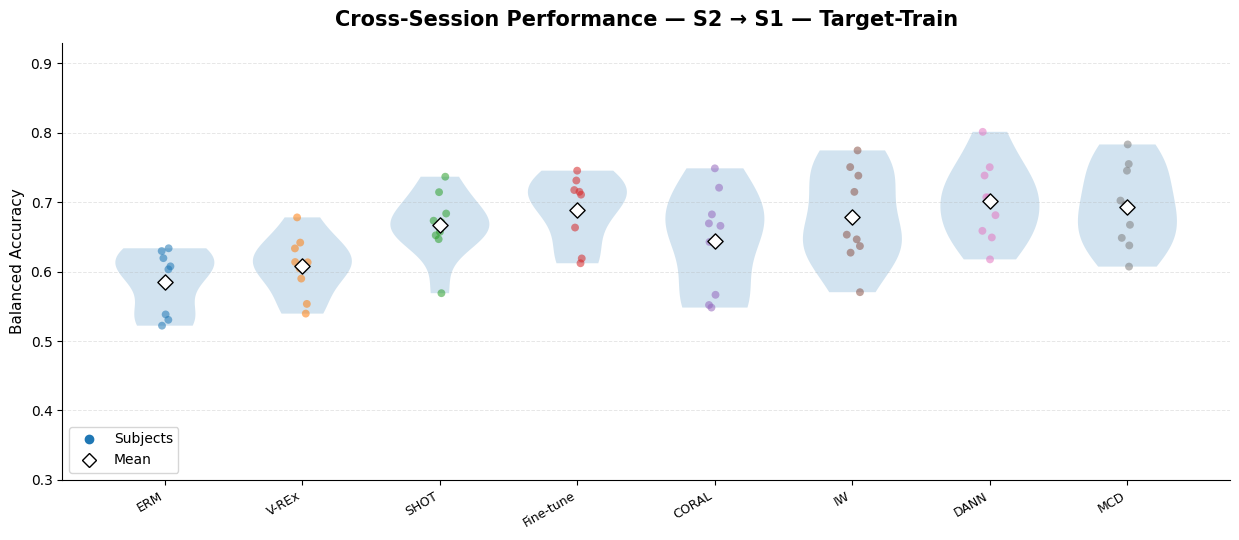

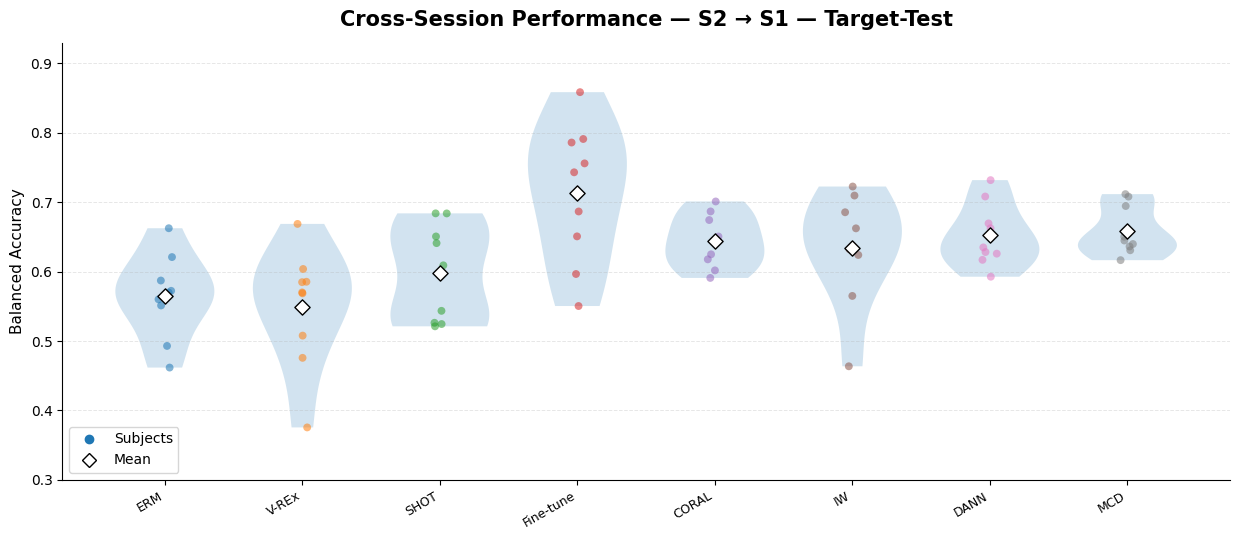

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative learning analysis — Cross-session performance
#
# Example: BCI IV 2a
#
# Directions:
#   - Session 1 -> Session 2
#   - Session 2 -> Session 1
#
# Evaluation subsets:
#   - Source
#   - Target-Train
#   - Target-Test
#
# One point = one subject.
# Dummy values are used only to design the figures.
# ============================================================

rng = np.random.default_rng(123)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

subsets = [
    "Source",
    "Target-Train",
    "Target-Test",
]

directions = [
    "S1 → S2",
    "S2 → S1",
]

n_subjects = 9


# ============================================================
# Dummy expected performances
# ============================================================

means = {
    "S1 → S2": {
        "Source": [
            0.85, 0.84, 0.83, 0.84,
            0.84, 0.85, 0.86, 0.85
        ],
        "Target-Train": [
            0.60, 0.63, 0.66, 0.73,
            0.68, 0.69, 0.71, 0.70
        ],
        "Target-Test": [
            0.57, 0.61, 0.64, 0.71,
            0.66, 0.67, 0.69, 0.68
        ],
    },

    "S2 → S1": {
        "Source": [
            0.84, 0.83, 0.82, 0.83,
            0.83, 0.84, 0.85, 0.84
        ],
        "Target-Train": [
            0.58, 0.61, 0.64, 0.71,
            0.66, 0.67, 0.69, 0.68
        ],
        "Target-Test": [
            0.55, 0.59, 0.62, 0.69,
            0.64, 0.65, 0.67, 0.66
        ],
    },
}


# Across-subject variability
stds = {
    "Source": 0.025,
    "Target-Train": 0.055,
    "Target-Test": 0.065,
}


# ============================================================
# Generate dummy subject-level results
# ============================================================

results = {}

for direction in directions:

    results[direction] = {}

    for subset in subsets:

        results[direction][subset] = []

        for mean_value in means[direction][subset]:

            values = rng.normal(
                mean_value,
                stds[subset],
                n_subjects
            )

            values = np.clip(
                values,
                0.30,
                0.95
            )

            results[direction][subset].append(values)


# ============================================================
# Plot
# One figure for each direction × evaluation subset
# ============================================================

positions = np.arange(
    1,
    len(methods) + 1
)

for direction in directions:

    for subset in subsets:

        fig, ax = plt.subplots(
            figsize=(12.5, 5.5)
        )

        data = results[direction][subset]

        # ----------------------------------------------------
        # Violin plots
        # ----------------------------------------------------

        parts = ax.violinplot(
            data,
            positions=positions,
            widths=0.72,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_alpha(0.20)


        # ----------------------------------------------------
        # Subject observations + mean
        # ----------------------------------------------------

        for i, values in enumerate(
            data,
            start=1
        ):

            jitter = rng.uniform(
                -0.055,
                0.055,
                size=len(values)
            )

            # Individual subjects
            ax.scatter(
                np.full(len(values), i) + jitter,
                values,
                s=32,
                alpha=0.55,
                edgecolors="none",
                zorder=3,
            )

            # Mean
            ax.scatter(
                i,
                np.mean(values),
                marker="D",
                s=60,
                facecolors="white",
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )


        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            f"Cross-Session Performance — {direction} — {subset}",
            fontsize=15,
            fontweight="bold",
            pad=12,
        )

        ax.set_ylabel(
            "Balanced Accuracy",
            fontsize=11
        )

        ax.set_xticks(positions)

        ax.set_xticklabels(
            methods,
            rotation=30,
            ha="right",
            fontsize=9
        )

        ax.set_ylim(
            0.30,
            0.93
        )

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.30,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        subject_handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markersize=6,
            label="Subjects",
        )

        mean_handle = plt.Line2D(
            [0], [0],
            marker="D",
            linestyle="",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=7,
            label="Mean",
        )

        ax.legend(
            handles=[
                subject_handle,
                mean_handle,
            ],
            loc="lower left",
        )

        plt.tight_layout()
        plt.show()

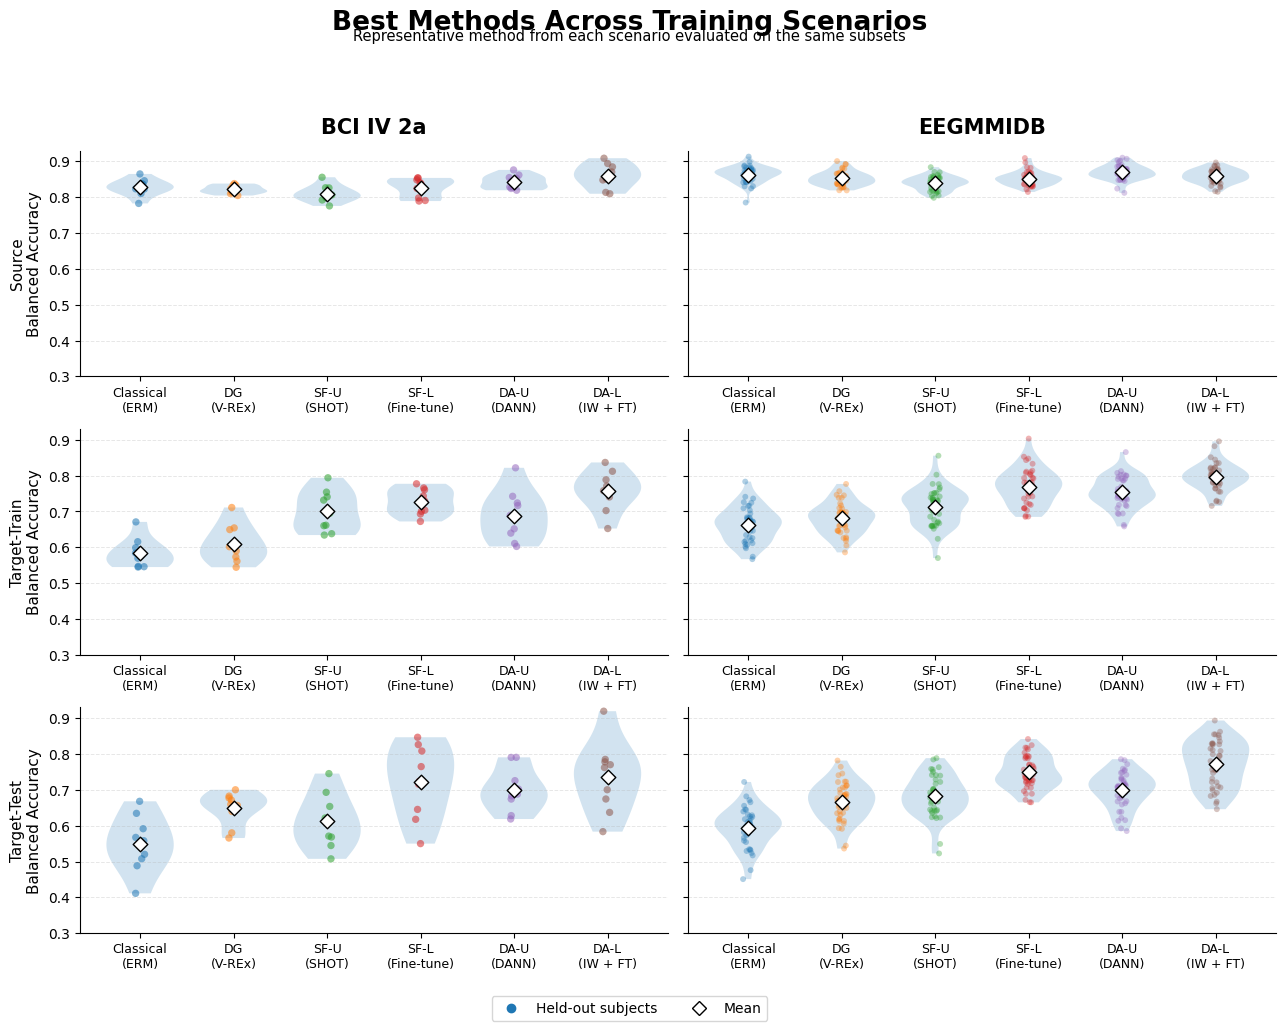

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative learning analysis — Plot 4
# Best method from each training scenario
#
# Goal:
# Compare the representative/best method selected from each
# scenario, using the same evaluation subsets:
#   - Source
#   - Target-Train
#   - Target-Test
#
# One point = one held-out subject.
# Dummy values are used only to design the figure.
# ============================================================

rng = np.random.default_rng(2026)

scenario_methods = [
    "Classical\n(ERM)",
    "DG\n(V-REx)",
    "SF-U\n(SHOT)",
    "SF-L\n(Fine-tune)",
    "DA-U\n(DANN)",
    "DA-L\n(IW + FT)",
]

subsets = [
    "Source",
    "Target-Train",
    "Target-Test",
]

n_subjects = {
    "BCI IV 2a": 9,
    "EEGMMIDB": 40,   # illustrative subset for the mock figure
}

# ------------------------------------------------------------
# Dummy expected balanced accuracies
# ------------------------------------------------------------

means = {
    "BCI IV 2a": {
        "Source": [
            0.83, 0.82, 0.81, 0.82, 0.84, 0.83
        ],
        "Target-Train": [
            0.60, 0.64, 0.67, 0.74, 0.71, 0.76
        ],
        "Target-Test": [
            0.56, 0.61, 0.64, 0.71, 0.69, 0.73
        ],
    },

    "EEGMMIDB": {
        "Source": [
            0.86, 0.85, 0.84, 0.85, 0.87, 0.86
        ],
        "Target-Train": [
            0.65, 0.69, 0.71, 0.77, 0.75, 0.79
        ],
        "Target-Test": [
            0.61, 0.66, 0.68, 0.74, 0.72, 0.76
        ],
    },
}

stds = {
    "BCI IV 2a": {
        "Source": 0.025,
        "Target-Train": 0.055,
        "Target-Test": 0.065,
    },

    "EEGMMIDB": {
        "Source": 0.020,
        "Target-Train": 0.045,
        "Target-Test": 0.055,
    },
}

# ============================================================
# Generate dummy subject-level results
# ============================================================

results = {}

for dataset in n_subjects:

    results[dataset] = {}

    for subset in subsets:

        results[dataset][subset] = []

        for mean_value in means[dataset][subset]:

            values = rng.normal(
                mean_value,
                stds[dataset][subset],
                n_subjects[dataset]
            )

            values = np.clip(
                values,
                0.30,
                0.95
            )

            results[dataset][subset].append(values)

# ============================================================
# Plot
# Rows = evaluation subset
# Columns = dataset
# X-axis = best method selected from each scenario
# ============================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(13.5, 10.5),
    sharey="row"
)

fig.suptitle(
    "Best Methods Across Training Scenarios",
    fontsize=19,
    fontweight="bold",
    y=0.985,
)

fig.text(
    0.5,
    0.955,
    "Representative method from each scenario evaluated on the same subsets",
    ha="center",
    fontsize=10.5,
)

positions = np.arange(1, len(scenario_methods) + 1)

for row, subset in enumerate(subsets):

    for col, dataset in enumerate(["BCI IV 2a", "EEGMMIDB"]):

        ax = axes[row, col]
        data = results[dataset][subset]

        # Violin distributions
        parts = ax.violinplot(
            data,
            positions=positions,
            widths=0.72,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_alpha(0.20)

        # Held-out subject points + mean
        for i, values in enumerate(data, start=1):

            jitter = rng.uniform(
                -0.055,
                0.055,
                size=len(values)
            )

            ax.scatter(
                np.full(len(values), i) + jitter,
                values,
                s=18 if dataset == "EEGMMIDB" else 28,
                alpha=0.35 if dataset == "EEGMMIDB" else 0.55,
                edgecolors="none",
                zorder=3,
            )

            ax.scatter(
                i,
                np.mean(values),
                marker="D",
                s=55,
                facecolors="white",
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )

        if row == 0:
            ax.set_title(
                dataset,
                fontsize=15,
                fontweight="bold",
                pad=12,
            )

        if col == 0:
            ax.set_ylabel(
                f"{subset}\nBalanced Accuracy",
                fontsize=11,
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            scenario_methods,
            fontsize=9,
        )

        ax.set_ylim(0.30, 0.93)

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.7,
            alpha=0.30,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Shared legend
subject_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="",
    markersize=6,
    label="Held-out subjects",
)

mean_handle = plt.Line2D(
    [0], [0],
    marker="D",
    linestyle="",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=7,
    label="Mean",
)

fig.legend(
    handles=[subject_handle, mean_handle],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)

plt.tight_layout(rect=[0.03, 0.055, 0.99, 0.935])
plt.show()


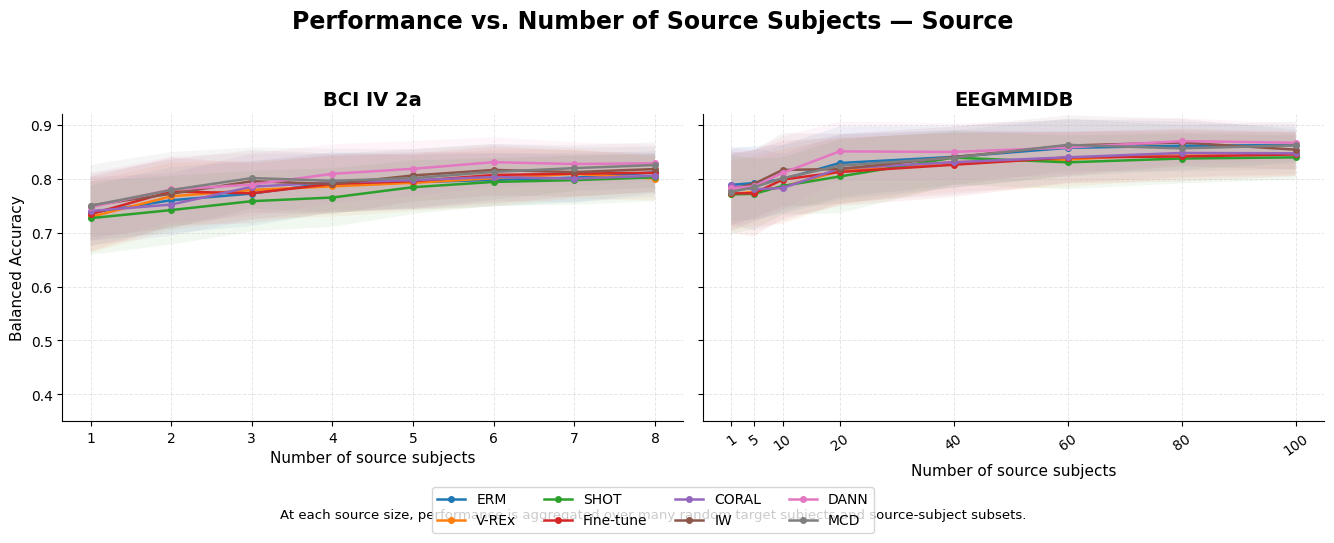

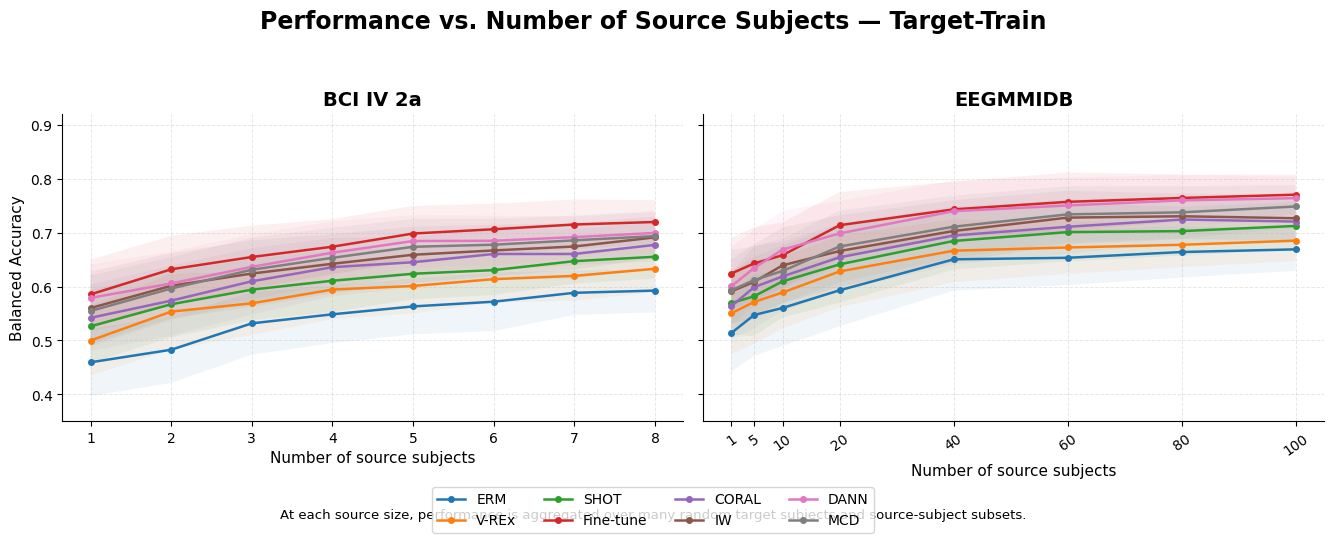

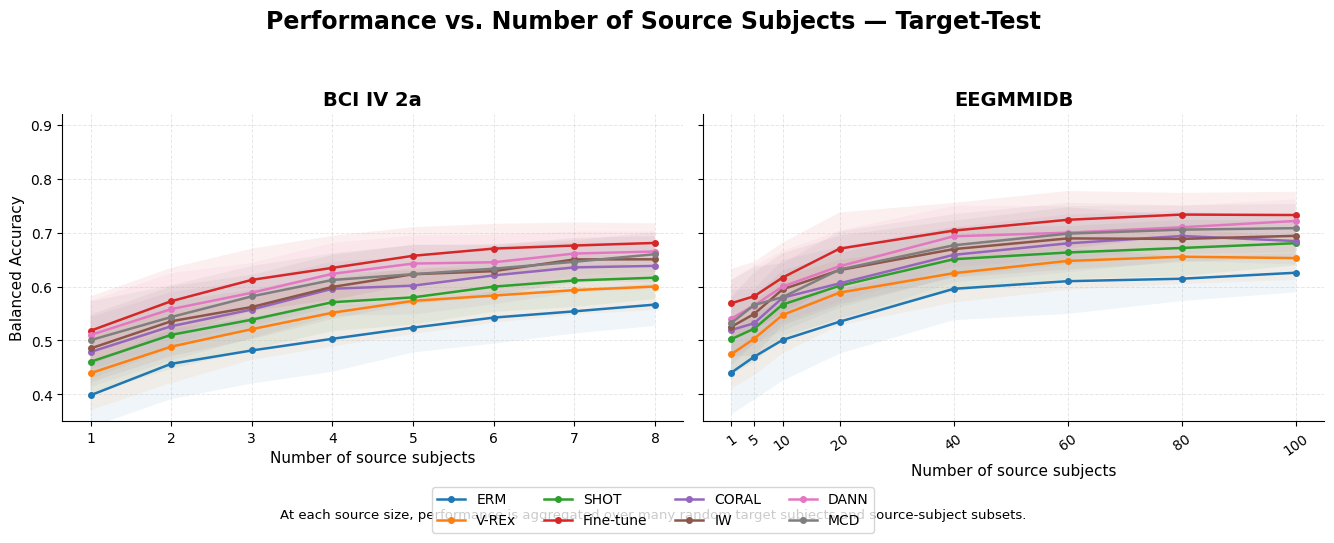

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Quantitative learning analysis — Performance vs. number
# of source subjects
#
# For each source-size k:
#   - randomly choose a target subject
#   - randomly choose k source subjects
#   - train/evaluate each method
#   - repeat many times
#
# We summarize the repeated runs with:
#   line  = mean Balanced Accuracy
#   band  = ± 1 SD
#
# Dummy values are used only to design the figure.
# ============================================================

rng = np.random.default_rng(42)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

subsets = ["Source", "Target-Train", "Target-Test"]

source_sizes = {
    "BCI IV 2a": np.arange(1, 9),  # 9 subjects total, one held out
    "EEGMMIDB": np.array([1, 5, 10, 20, 40, 60, 80, 100]),
}

N_REPEATS = 100

# Final asymptotic performance expected for each method
final_perf = {
    "Source": {
        "BCI IV 2a": [0.82, 0.82, 0.81, 0.82, 0.82, 0.83, 0.84, 0.83],
        "EEGMMIDB":  [0.86, 0.85, 0.84, 0.85, 0.85, 0.86, 0.87, 0.86],
    },
    "Target-Train": {
        "BCI IV 2a": [0.61, 0.65, 0.67, 0.74, 0.69, 0.70, 0.72, 0.71],
        "EEGMMIDB":  [0.66, 0.69, 0.71, 0.77, 0.72, 0.73, 0.76, 0.74],
    },
    "Target-Test": {
        "BCI IV 2a": [0.58, 0.62, 0.64, 0.71, 0.66, 0.67, 0.69, 0.68],
        "EEGMMIDB":  [0.62, 0.66, 0.68, 0.74, 0.69, 0.70, 0.72, 0.71],
    },
}


def simulate_performance_curve(k_values, final_value, subset, dataset):
    """
    Dummy repeated-run performance for random:
      target subject + source subset of size k.
    """
    curves = []

    # Lower performance with very few source subjects
    if subset == "Source":
        gain = 0.08
    elif subset == "Target-Train":
        gain = 0.15
    else:
        gain = 0.18

    # Dataset-specific convergence rate
    rate = 0.30 if dataset == "BCI IV 2a" else 0.045

    max_k = max(k_values)

    for k in k_values:
        mean = final_value - gain * np.exp(-rate * (k - 1))

        # Variability decreases as more source subjects are pooled
        relative_k = k / max_k
        sd = 0.055 * (1 - 0.55 * relative_k) + 0.015

        runs = rng.normal(mean, sd, N_REPEATS)
        runs = np.clip(runs, 0.25, 0.95)

        curves.append(runs)

    return curves


# ============================================================
# Generate repeated-run dummy results
# ============================================================

results = {}

for subset in subsets:
    results[subset] = {}

    for dataset in source_sizes:
        results[subset][dataset] = {}

        for method, final_value in zip(
            methods,
            final_perf[subset][dataset]
        ):
            results[subset][dataset][method] = simulate_performance_curve(
                source_sizes[dataset],
                final_value,
                subset,
                dataset,
            )


# ============================================================
# One figure per evaluation subset
# ============================================================

for subset in subsets:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5.5),
        sharey=True,
    )

    fig.suptitle(
        f"Performance vs. Number of Source Subjects — {subset}",
        fontsize=17,
        fontweight="bold",
        y=0.98,
    )

    for ax, dataset in zip(
        axes,
        ["BCI IV 2a", "EEGMMIDB"]
    ):
        k_values = source_sizes[dataset]

        for method in methods:
            distributions = results[subset][dataset][method]

            means = np.array([
                np.mean(v) for v in distributions
            ])

            stds = np.array([
                np.std(v, ddof=1) for v in distributions
            ])

            ax.plot(
                k_values,
                means,
                marker="o",
                linewidth=1.8,
                markersize=4,
                label=method,
            )

            ax.fill_between(
                k_values,
                np.maximum(0, means - stds),
                np.minimum(1, means + stds),
                alpha=0.07,
            )

        ax.set_title(
            dataset,
            fontsize=14,
            fontweight="bold",
        )

        ax.set_xlabel(
            "Number of source subjects",
            fontsize=11,
        )

        ax.set_xticks(k_values)

        if dataset == "EEGMMIDB":
            ax.tick_params(
                axis="x",
                labelrotation=35
            )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.30,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(
        "Balanced Accuracy",
        fontsize=11,
    )

    axes[0].set_ylim(0.35, 0.92)

    # Shared legend
    handles, labels = axes[1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.015),
    )

    fig.text(
        0.5,
        0.055,
        "At each source size, performance is aggregated over many random target subjects and source-subject subsets.",
        ha="center",
        fontsize=9.5,
    )

    plt.tight_layout(
        rect=[0.03, 0.10, 0.99, 0.93]
    )

    plt.show()


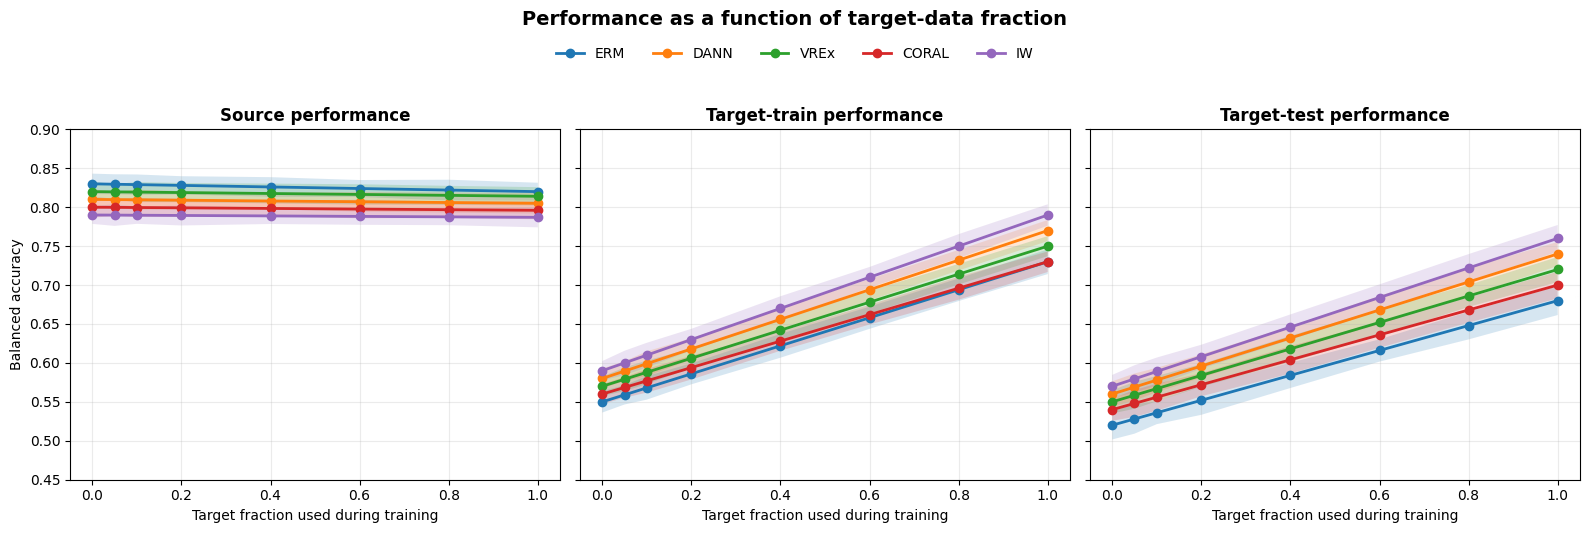

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Dummy data
# ============================================================

rng = np.random.default_rng(42)

methods = [
    "ERM",
    "DANN",
    "VREx",
    "CORAL",
    "IW",
]

target_fractions = np.array([0.00, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00])

rows = []

for method in methods:
    for frac in target_fractions:
        if method == "ERM":
            source_mean = 0.83 - 0.01 * frac
            target_train_mean = 0.55 + 0.18 * frac
            target_test_mean = 0.52 + 0.16 * frac

        elif method == "DANN":
            source_mean = 0.81 - 0.005 * frac
            target_train_mean = 0.58 + 0.19 * frac
            target_test_mean = 0.56 + 0.18 * frac

        elif method == "VREx":
            source_mean = 0.82 - 0.006 * frac
            target_train_mean = 0.57 + 0.18 * frac
            target_test_mean = 0.55 + 0.17 * frac

        elif method == "CORAL":
            source_mean = 0.80 - 0.004 * frac
            target_train_mean = 0.56 + 0.17 * frac
            target_test_mean = 0.54 + 0.16 * frac

        elif method == "IW":
            source_mean = 0.79 - 0.003 * frac
            target_train_mean = 0.59 + 0.20 * frac
            target_test_mean = 0.57 + 0.19 * frac

        source_std = 0.010 + 0.004 * rng.random()
        target_train_std = 0.012 + 0.004 * rng.random()
        target_test_std = 0.014 + 0.005 * rng.random()

        rows.append({
            "method": method,
            "target_fraction": frac,
            "source_mean": source_mean,
            "source_std": source_std,
            "target_train_mean": target_train_mean,
            "target_train_std": target_train_std,
            "target_test_mean": target_test_mean,
            "target_test_std": target_test_std,
        })

df_plot = pd.DataFrame(rows)

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

panel_info = [
    ("source_mean", "source_std", "Source performance"),
    ("target_train_mean", "target_train_std", "Target-train performance"),
    ("target_test_mean", "target_test_std", "Target-test performance"),
]

for ax, (mean_col, std_col, title) in zip(axes, panel_info):
    for method in methods:
        sub = df_plot[df_plot["method"] == method].sort_values("target_fraction")

        x = sub["target_fraction"].values
        y = sub[mean_col].values
        s = sub[std_col].values

        ax.plot(x, y, marker="o", linewidth=2, label=method)
        ax.fill_between(x, y - s, y + s, alpha=0.18)

    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Target fraction used during training", fontsize=10)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Balanced accuracy", fontsize=10)
axes[0].set_ylim(0.45, 0.90)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(methods), frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.suptitle(
    "Performance as a function of target-data fraction",
    fontsize=14,
    weight="bold",
    y=1.10
)

plt.tight_layout()
plt.show()

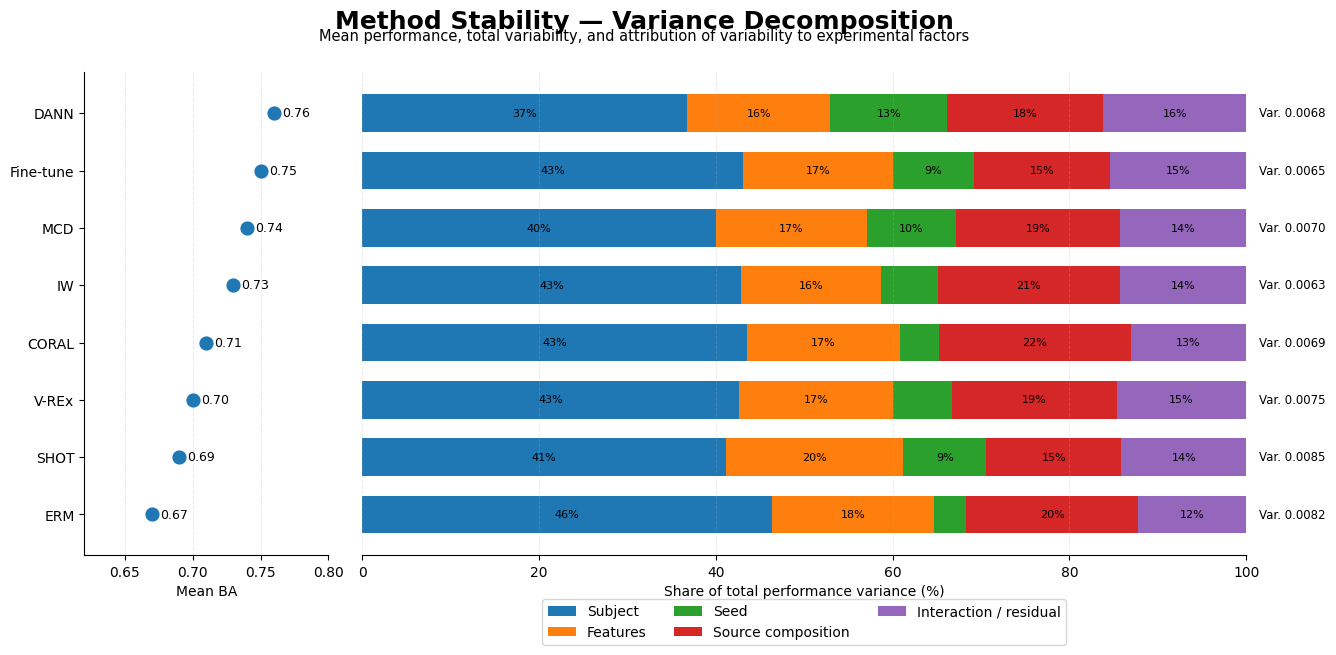

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Stability plot — Alternative 1
# 100% stacked horizontal variance decomposition
#
# Each row = one method
# Mean BA = overall performance across experimental conditions
# Total Var. = absolute amount of performance variability
# Stacked bar = percentage attribution of that variability
# ============================================================

methods = ["ERM", "V-REx", "SHOT", "Fine-tune", "CORAL", "IW", "DANN", "MCD"]

mean_ba = np.array([0.67, 0.70, 0.69, 0.75, 0.71, 0.73, 0.76, 0.74])

# Dummy variance components in Balanced-Accuracy^2 units
variance = pd.DataFrame({
    "Subject":            [0.0038, 0.0032, 0.0035, 0.0028, 0.0030, 0.0027, 0.0025, 0.0028],
    "Features":           [0.0015, 0.0013, 0.0017, 0.0011, 0.0012, 0.0010, 0.0011, 0.0012],
    "Seed":               [0.0003, 0.0005, 0.0008, 0.0006, 0.0003, 0.0004, 0.0009, 0.0007],
    "Source composition": [0.0016, 0.0014, 0.0013, 0.0010, 0.0015, 0.0013, 0.0012, 0.0013],
    "Interaction / residual":
                         [0.0010, 0.0011, 0.0012, 0.0010, 0.0009, 0.0009, 0.0011, 0.0010],
}, index=methods)

total_var = variance.sum(axis=1).values
variance_pct = variance.div(variance.sum(axis=1), axis=0) * 100

# Sort by mean BA for easier reading
order = np.argsort(mean_ba)
methods_plot = np.array(methods)[order]
mean_plot = mean_ba[order]
total_plot = total_var[order]
pct_plot = variance_pct.iloc[order]

# ============================================================
# Figure
# ============================================================

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.05, 3.8],
    wspace=0.06
)

ax_perf = fig.add_subplot(gs[0, 0])
ax_var = fig.add_subplot(gs[0, 1], sharey=ax_perf)

y = np.arange(len(methods_plot))

# ------------------------------------------------------------
# Left: compact mean-performance dot plot
# ------------------------------------------------------------

ax_perf.scatter(
    mean_plot,
    y,
    s=85,
    zorder=3
)

for i, value in enumerate(mean_plot):
    ax_perf.text(
        value + 0.006,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

ax_perf.set_yticks(y)
ax_perf.set_yticklabels(methods_plot, fontsize=10)
ax_perf.set_xlabel("Mean BA", fontsize=10)
ax_perf.set_xlim(0.62, 0.80)
ax_perf.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.30)

ax_perf.spines["top"].set_visible(False)
ax_perf.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Right: 100% stacked variance composition
# ------------------------------------------------------------

left = np.zeros(len(methods_plot))

for component in pct_plot.columns:
    values = pct_plot[component].values

    ax_var.barh(
        y,
        values,
        left=left,
        height=0.66,
        label=component
    )

    # Label only sufficiently large components
    for i, (start, width) in enumerate(zip(left, values)):
        if width >= 8:
            ax_var.text(
                start + width / 2,
                i,
                f"{width:.0f}%",
                ha="center",
                va="center",
                fontsize=8
            )

    left += values

ax_var.set_xlim(0, 100)
ax_var.set_xlabel("Share of total performance variance (%)", fontsize=10)
ax_var.tick_params(axis="y", left=False, labelleft=False)
ax_var.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.25)

ax_var.spines["top"].set_visible(False)
ax_var.spines["right"].set_visible(False)
ax_var.spines["left"].set_visible(False)

# Absolute total variance at right side
for i, value in enumerate(total_plot):
    ax_var.text(
        101.5,
        i,
        f"Var. {value:.4f}",
        va="center",
        fontsize=8.5,
        clip_on=False
    )

# ------------------------------------------------------------
# Titles and legend
# ------------------------------------------------------------

fig.suptitle(
    "Method Stability — Variance Decomposition",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.935,
    "Mean performance, total variability, and attribution of variability to experimental factors",
    ha="center",
    fontsize=10.5
)

ax_var.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=3,
    frameon=True
)

plt.subplots_adjust(
    left=0.10,
    right=0.93,
    top=0.89,
    bottom=0.20
)

plt.show()


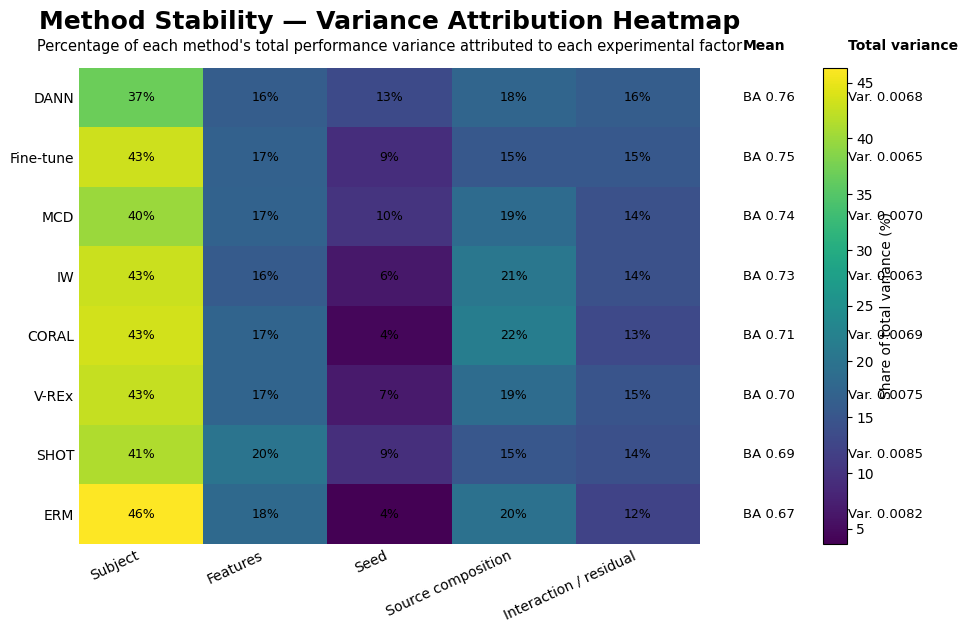

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Stability plot — Alternative 2
# Heatmap of variance attribution
#
# Rows = methods
# Columns = sources of variability
# Cell = percentage of total variance attributed to that factor
#
# Mean BA and total variance are shown as compact annotations
# next to the heatmap.
# ============================================================

methods = ["ERM", "V-REx", "SHOT", "Fine-tune", "CORAL", "IW", "DANN", "MCD"]

mean_ba = np.array([0.67, 0.70, 0.69, 0.75, 0.71, 0.73, 0.76, 0.74])

variance = pd.DataFrame({
    "Subject":            [0.0038, 0.0032, 0.0035, 0.0028, 0.0030, 0.0027, 0.0025, 0.0028],
    "Features":           [0.0015, 0.0013, 0.0017, 0.0011, 0.0012, 0.0010, 0.0011, 0.0012],
    "Seed":               [0.0003, 0.0005, 0.0008, 0.0006, 0.0003, 0.0004, 0.0009, 0.0007],
    "Source composition": [0.0016, 0.0014, 0.0013, 0.0010, 0.0015, 0.0013, 0.0012, 0.0013],
    "Interaction / residual":
                         [0.0010, 0.0011, 0.0012, 0.0010, 0.0009, 0.0009, 0.0011, 0.0010],
}, index=methods)

total_var = variance.sum(axis=1)
variance_pct = variance.div(total_var, axis=0) * 100

# Sort by mean BA
order = np.argsort(mean_ba)[::-1]
methods_plot = np.array(methods)[order]
mean_plot = mean_ba[order]
total_plot = total_var.values[order]
heat = variance_pct.iloc[order]

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(11.5, 7))

im = ax.imshow(
    heat.values,
    aspect="auto"
)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(
    heat.columns,
    rotation=25,
    ha="right",
    fontsize=10
)

ax.set_yticks(np.arange(len(methods_plot)))
ax.set_yticklabels(methods_plot, fontsize=10)

# Annotate each heatmap cell
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(
            j,
            i,
            f"{heat.iloc[i, j]:.0f}%",
            ha="center",
            va="center",
            fontsize=9
        )

# Add performance and total-variance summaries to the right
summary_x1 = len(heat.columns) - 0.5 + 0.35
summary_x2 = len(heat.columns) - 0.5 + 1.20

for i, (ba, var) in enumerate(zip(mean_plot, total_plot)):
    ax.text(
        summary_x1,
        i,
        f"BA {ba:.2f}",
        va="center",
        fontsize=9.5,
        clip_on=False
    )

    ax.text(
        summary_x2,
        i,
        f"Var. {var:.4f}",
        va="center",
        fontsize=9.5,
        clip_on=False
    )

ax.text(
    summary_x1,
    -0.8,
    "Mean",
    fontsize=10,
    fontweight="bold",
    clip_on=False
)

ax.text(
    summary_x2,
    -0.8,
    "Total variance",
    fontsize=10,
    fontweight="bold",
    clip_on=False
)

ax.set_title(
    "Method Stability — Variance Attribution Heatmap",
    fontsize=18,
    fontweight="bold",
    pad=28
)

ax.text(
    0.5,
    1.035,
    "Percentage of each method's total performance variance attributed to each experimental factor",
    transform=ax.transAxes,
    ha="center",
    fontsize=10.5
)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.16
)
cbar.set_label(
    "Share of total variance (%)",
    rotation=90
)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.subplots_adjust(
    left=0.13,
    right=0.80,
    top=0.86,
    bottom=0.18
)

plt.show()


### Joint Domain Learner

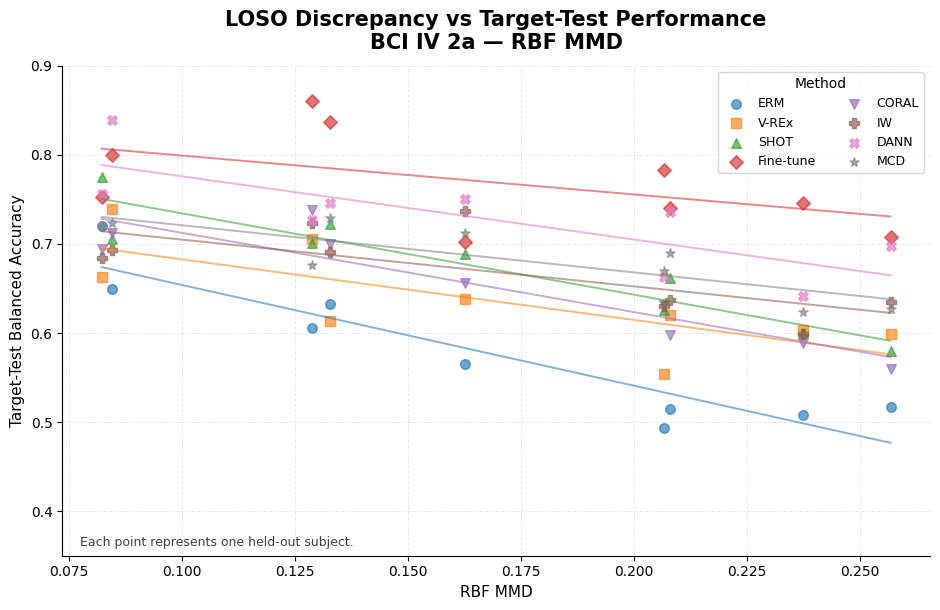

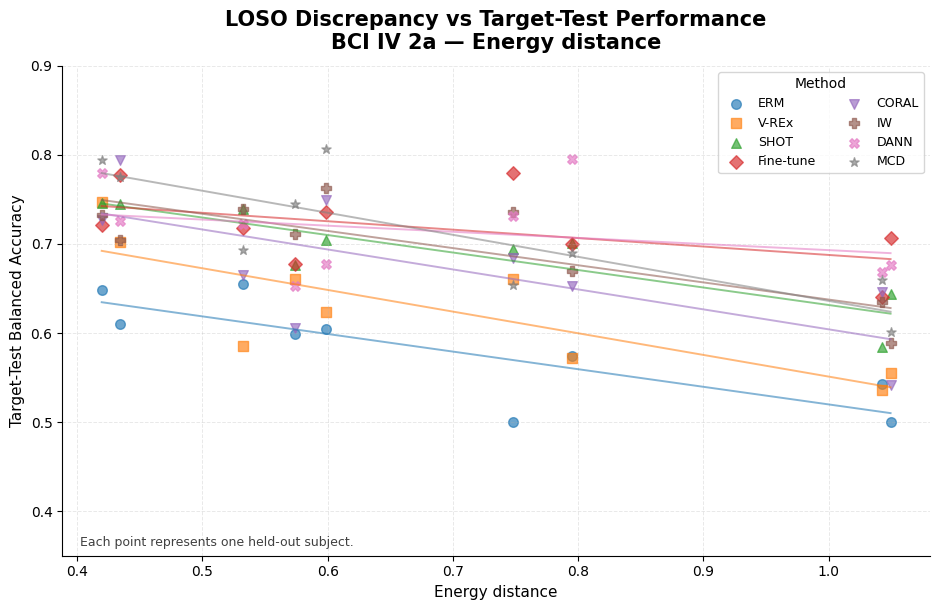

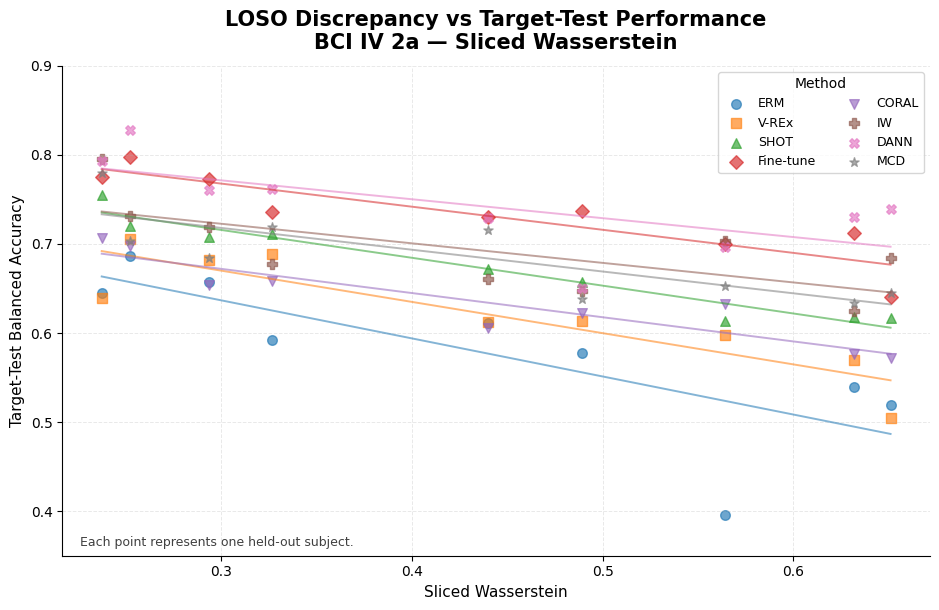

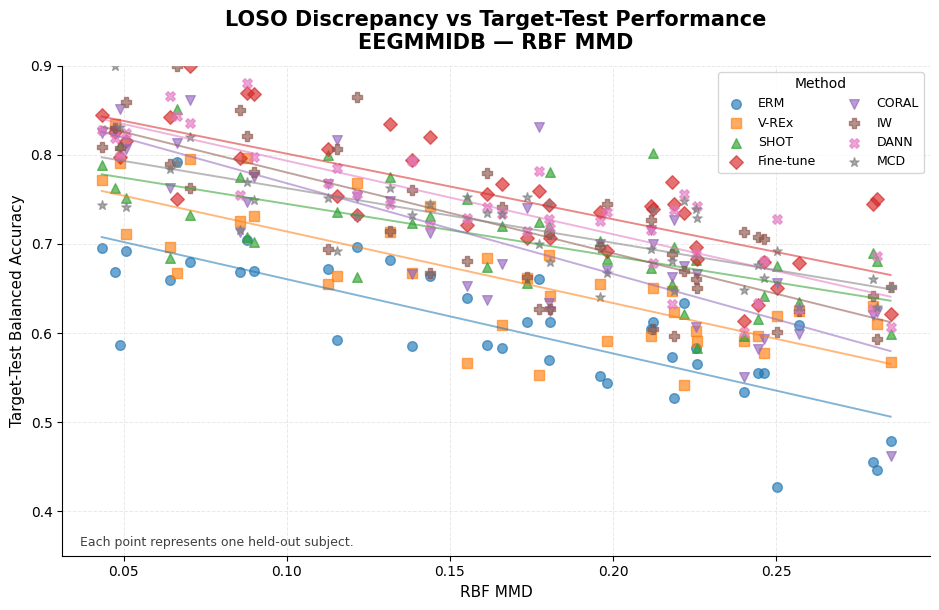

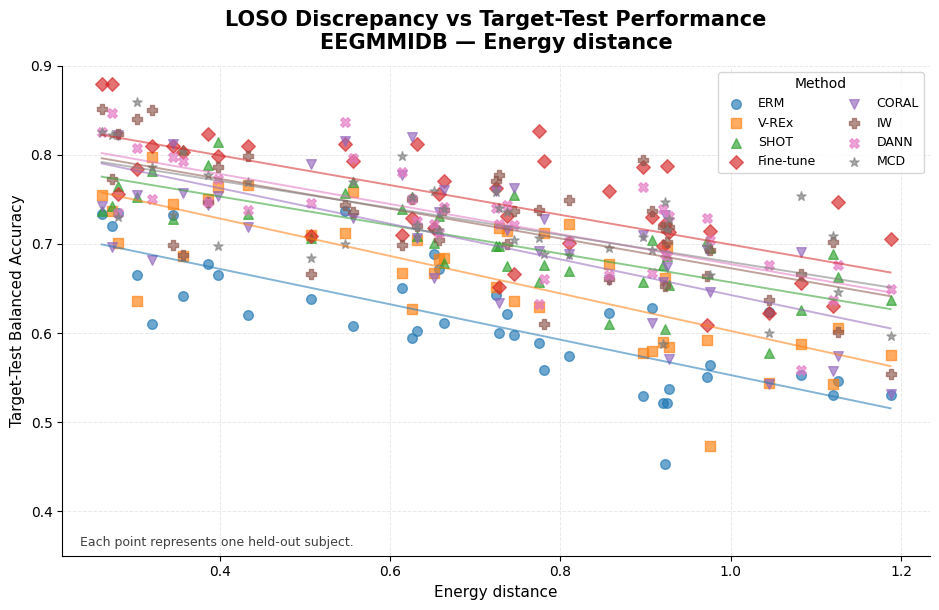

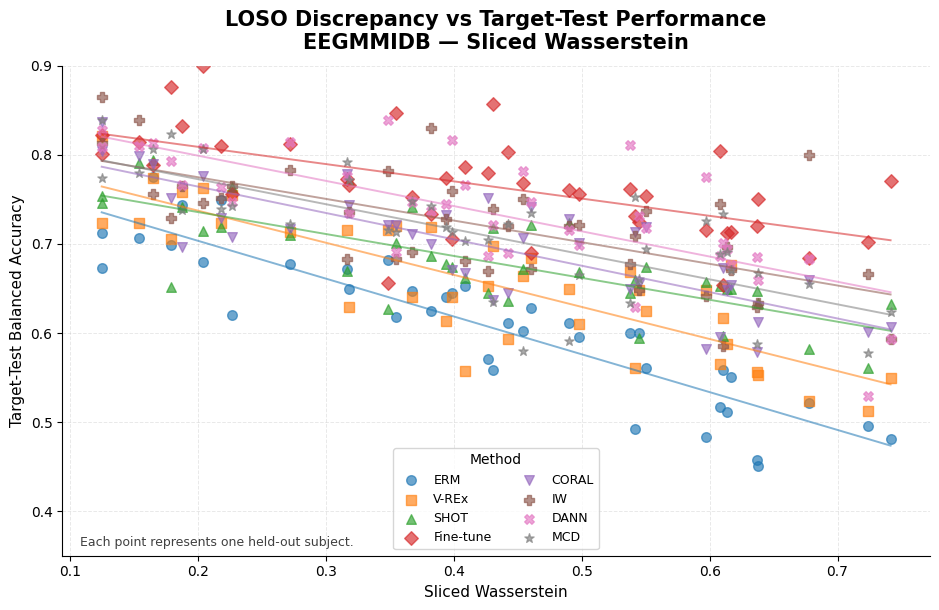

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Joint domain + learning analysis — Plot 1
# LOSO domain discrepancy vs Target-Test performance
#
# One held-out subject defines one target domain.
# For each held-out subject:
#   1. compute source-pool ↔ target discrepancy
#   2. train/evaluate every method
#   3. plot discrepancy against Target-Test Balanced Accuracy
#
# One point = one held-out subject for one method.
# Dummy data are used only to design the figure.
# ============================================================

rng = np.random.default_rng(2026)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

datasets = {
    "BCI IV 2a": 9,
    "EEGMMIDB": 40,   # illustrative subset for the mock figure
}

distance_metrics = {
    "RBF MMD": (0.03, 0.30),
    "Energy distance": (0.20, 1.20),
    "Sliced Wasserstein": (0.10, 0.75),
}

# Higher values = stronger average method performance
method_offsets = {
    "ERM": -0.055,
    "V-REx": -0.025,
    "SHOT": 0.000,
    "Fine-tune": 0.045,
    "CORAL": 0.010,
    "IW": 0.020,
    "DANN": 0.035,
    "MCD": 0.025,
}

# ============================================================
# Generate dummy LOSO results
# ============================================================

rows = []

for dataset, n_subjects in datasets.items():

    # Latent subject-specific shift:
    # the same difficult subject should tend to look difficult
    # under all three discrepancy measures.
    latent_shift = rng.uniform(0.05, 0.95, n_subjects)

    for metric, (low, high) in distance_metrics.items():

        # Convert latent shift into the raw scale of each metric
        discrepancy = (
            low
            + latent_shift * (high - low)
            + rng.normal(0, 0.04 * (high - low), n_subjects)
        )

        discrepancy = np.clip(discrepancy, low, high)

        # Normalize internally ONLY to create dummy performance.
        # The actual x-axis remains the raw discrepancy value.
        d_norm = (discrepancy - low) / (high - low)

        for method in methods:

            # Target performance worsens as discrepancy increases.
            # Adaptation methods are made slightly less sensitive
            # to shift just for illustration.
            if method == "ERM":
                slope = 0.25
            elif method in ["V-REx", "CORAL"]:
                slope = 0.21
            elif method in ["SHOT", "IW", "MCD"]:
                slope = 0.18
            elif method == "DANN":
                slope = 0.17
            else:  # Fine-tune
                slope = 0.15

            base = 0.76 if dataset == "BCI IV 2a" else 0.79

            performance = (
                base
                + method_offsets[method]
                - slope * d_norm
                + rng.normal(
                    0,
                    0.035 if dataset == "BCI IV 2a" else 0.045,
                    n_subjects,
                )
            )

            performance = np.clip(performance, 0.35, 0.90)

            for subject_idx in range(n_subjects):
                rows.append({
                    "dataset": dataset,
                    "subject": subject_idx + 1,
                    "metric": metric,
                    "method": method,
                    "discrepancy": discrepancy[subject_idx],
                    "target_test_ba": performance[subject_idx],
                })

df_joint = pd.DataFrame(rows)

# ============================================================
# Plot
#
# Separate figure for each dataset × discrepancy metric.
# This keeps the raw metric scales interpretable and avoids
# overcrowding.
# ============================================================

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

for dataset in datasets:

    for metric in distance_metrics:

        fig, ax = plt.subplots(figsize=(9.5, 6.2))

        current = df_joint[
            (df_joint["dataset"] == dataset) &
            (df_joint["metric"] == metric)
        ]

        for method, marker in zip(methods, markers):

            sub = current[current["method"] == method]

            x = sub["discrepancy"].to_numpy()
            y = sub["target_test_ba"].to_numpy()

            # Subject-level observations
            scatter = ax.scatter(
                x,
                y,
                marker=marker,
                s=48,
                alpha=0.65,
                label=method,
            )

            # Method-specific linear trend
            if len(x) >= 2:
                coef = np.polyfit(x, y, 1)
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = np.polyval(coef, x_line)

                ax.plot(
                    x_line,
                    y_line,
                    linewidth=1.4,
                    alpha=0.55,
                    color=scatter.get_facecolor()[0],
                )

        ax.set_title(
            f"LOSO Discrepancy vs Target-Test Performance\n{dataset} — {metric}",
            fontsize=15,
            fontweight="bold",
            pad=12,
        )

        ax.set_xlabel(
            metric,
            fontsize=11,
        )

        ax.set_ylabel(
            "Target-Test Balanced Accuracy",
            fontsize=11,
        )

        ax.set_ylim(0.35, 0.90)

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.28,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.legend(
            title="Method",
            ncol=2,
            frameon=True,
            fontsize=9,
        )

        ax.text(
            0.02,
            0.02,
            "Each point represents one held-out subject.",
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.75,
        )

        plt.tight_layout()
        plt.show()


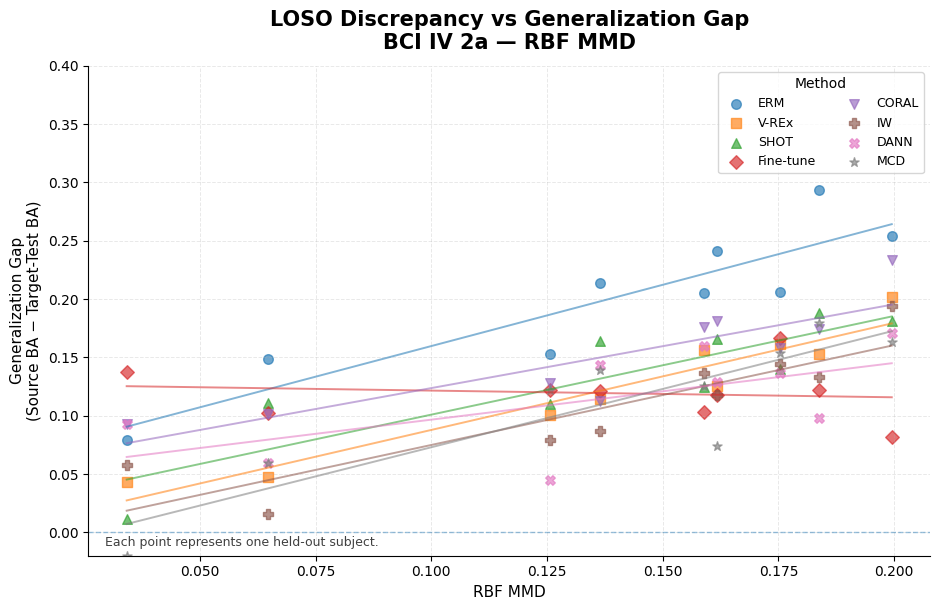

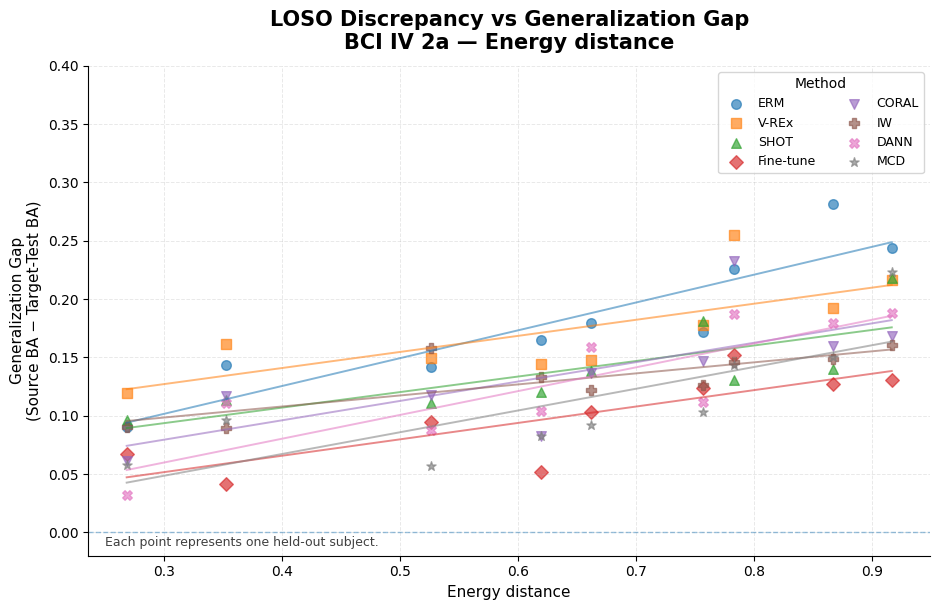

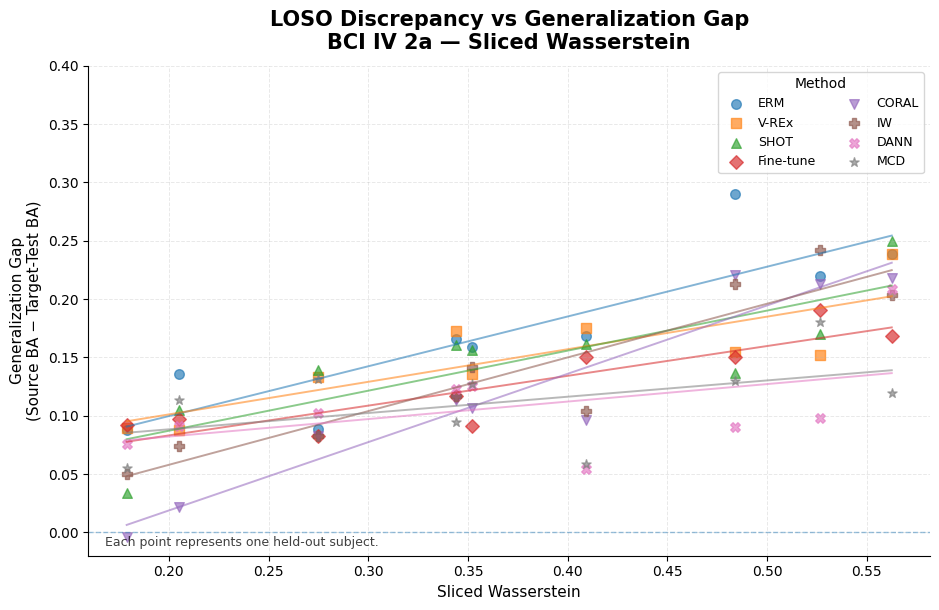

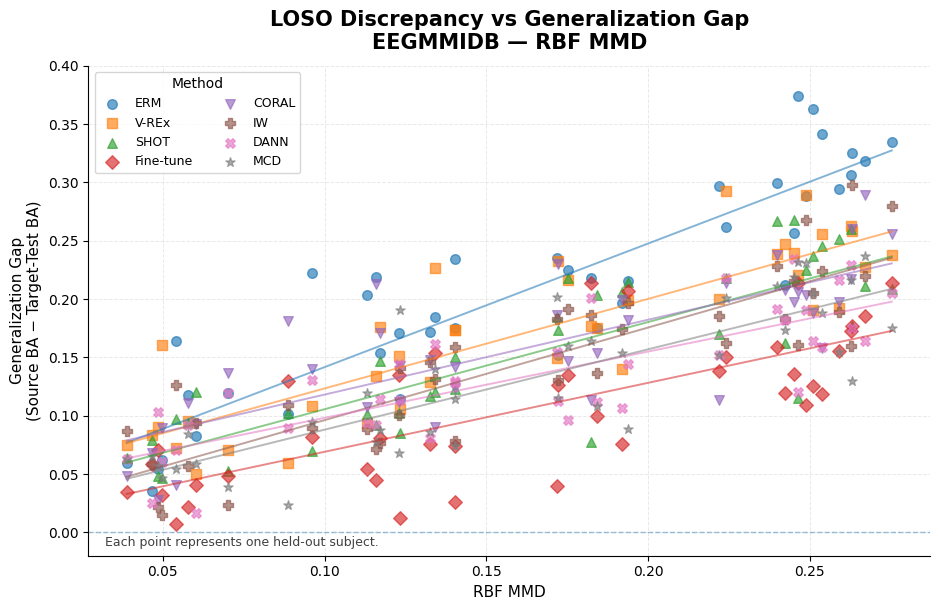

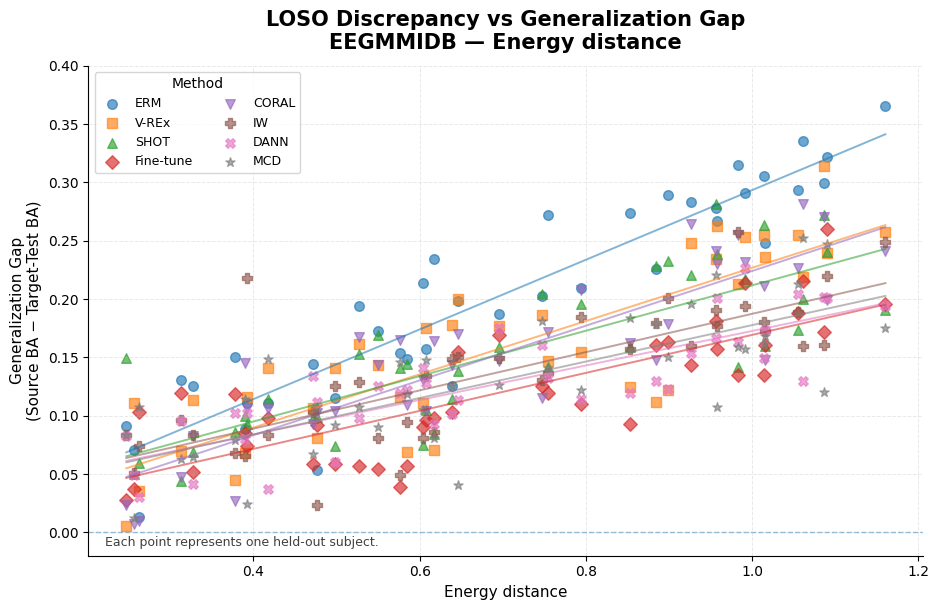

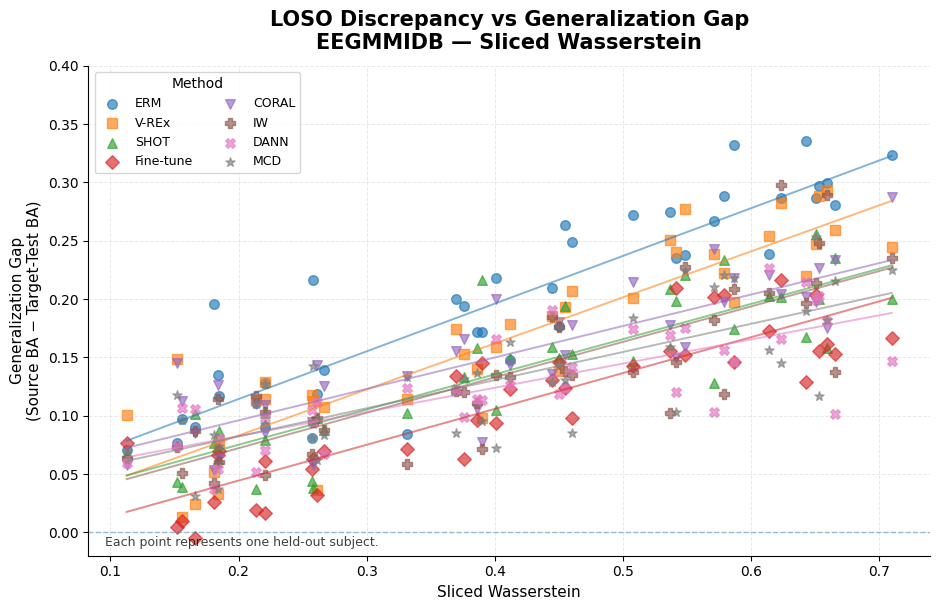

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Joint domain + learning analysis — Plot 2
# LOSO domain discrepancy vs Generalization Gap
#
# Generalization gap:
#     Source BA - Target-Test BA
#
# One point = one held-out subject for one method.
# Larger positive values mean a larger loss when moving
# from the source domains to the unseen target subject.
#
# Dummy data are used only to design the figure.
# ============================================================

rng = np.random.default_rng(2027)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

datasets = {
    "BCI IV 2a": 9,
    "EEGMMIDB": 40,   # illustrative subset for the mock figure
}

distance_metrics = {
    "RBF MMD": (0.03, 0.30),
    "Energy distance": (0.20, 1.20),
    "Sliced Wasserstein": (0.10, 0.75),
}

# Method-specific sensitivity of the generalization gap
# to increasing domain discrepancy.
gap_slope = {
    "ERM": 0.27,
    "V-REx": 0.22,
    "SHOT": 0.19,
    "Fine-tune": 0.14,
    "CORAL": 0.20,
    "IW": 0.18,
    "DANN": 0.16,
    "MCD": 0.17,
}

# Small baseline gap even under mild shift
gap_intercept = {
    "ERM": 0.07,
    "V-REx": 0.06,
    "SHOT": 0.055,
    "Fine-tune": 0.045,
    "CORAL": 0.055,
    "IW": 0.050,
    "DANN": 0.050,
    "MCD": 0.050,
}

# ============================================================
# Generate dummy LOSO results
# ============================================================

rows = []

for dataset, n_subjects in datasets.items():

    # Latent subject-specific shift shared across discrepancy metrics
    latent_shift = rng.uniform(0.05, 0.95, n_subjects)

    # Source performance is also subject/configuration dependent,
    # because the source pool changes when each subject is held out.
    source_base = 0.84 if dataset == "BCI IV 2a" else 0.87

    for metric, (low, high) in distance_metrics.items():

        discrepancy = (
            low
            + latent_shift * (high - low)
            + rng.normal(0, 0.04 * (high - low), n_subjects)
        )
        discrepancy = np.clip(discrepancy, low, high)

        # Internal normalization only for generating the dummy data.
        # X-axis still uses the original raw discrepancy.
        d_norm = (discrepancy - low) / (high - low)

        for method in methods:

            source_ba = (
                source_base
                + rng.normal(0, 0.018, n_subjects)
            )

            gap = (
                gap_intercept[method]
                + gap_slope[method] * d_norm
                + rng.normal(
                    0,
                    0.030 if dataset == "BCI IV 2a" else 0.035,
                    n_subjects,
                )
            )

            gap = np.clip(gap, -0.02, 0.40)

            target_test_ba = np.clip(
                source_ba - gap,
                0.30,
                0.95,
            )

            # Recompute gap from the two observed quantities
            observed_gap = source_ba - target_test_ba

            for subject_idx in range(n_subjects):
                rows.append({
                    "dataset": dataset,
                    "subject": subject_idx + 1,
                    "metric": metric,
                    "method": method,
                    "discrepancy": discrepancy[subject_idx],
                    "source_ba": source_ba[subject_idx],
                    "target_test_ba": target_test_ba[subject_idx],
                    "generalization_gap": observed_gap[subject_idx],
                })

df_gap = pd.DataFrame(rows)

# ============================================================
# Plot
#
# Separate plot per dataset × discrepancy metric.
# Raw metric scales remain interpretable.
# ============================================================

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

for dataset in datasets:

    for metric in distance_metrics:

        fig, ax = plt.subplots(figsize=(9.5, 6.2))

        current = df_gap[
            (df_gap["dataset"] == dataset) &
            (df_gap["metric"] == metric)
        ]

        for method, marker in zip(methods, markers):

            sub = current[current["method"] == method]

            x = sub["discrepancy"].to_numpy()
            y = sub["generalization_gap"].to_numpy()

            scatter = ax.scatter(
                x,
                y,
                marker=marker,
                s=48,
                alpha=0.65,
                label=method,
            )

            # Method-specific linear trend
            if len(x) >= 2:
                coef = np.polyfit(x, y, 1)
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = np.polyval(coef, x_line)

                ax.plot(
                    x_line,
                    y_line,
                    linewidth=1.4,
                    alpha=0.55,
                    color=scatter.get_facecolor()[0],
                )

        # Zero-gap reference
        ax.axhline(
            0,
            linestyle="--",
            linewidth=1.0,
            alpha=0.45,
        )

        ax.set_title(
            f"LOSO Discrepancy vs Generalization Gap\n{dataset} — {metric}",
            fontsize=15,
            fontweight="bold",
            pad=12,
        )

        ax.set_xlabel(
            metric,
            fontsize=11,
        )

        ax.set_ylabel(
            "Generalization Gap\n(Source BA − Target-Test BA)",
            fontsize=11,
        )

        ax.set_ylim(-0.02, 0.40)

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.28,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.legend(
            title="Method",
            ncol=2,
            frameon=True,
            fontsize=9,
        )

        ax.text(
            0.02,
            0.02,
            "Each point represents one held-out subject.",
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.75,
        )

        plt.tight_layout()
        plt.show()


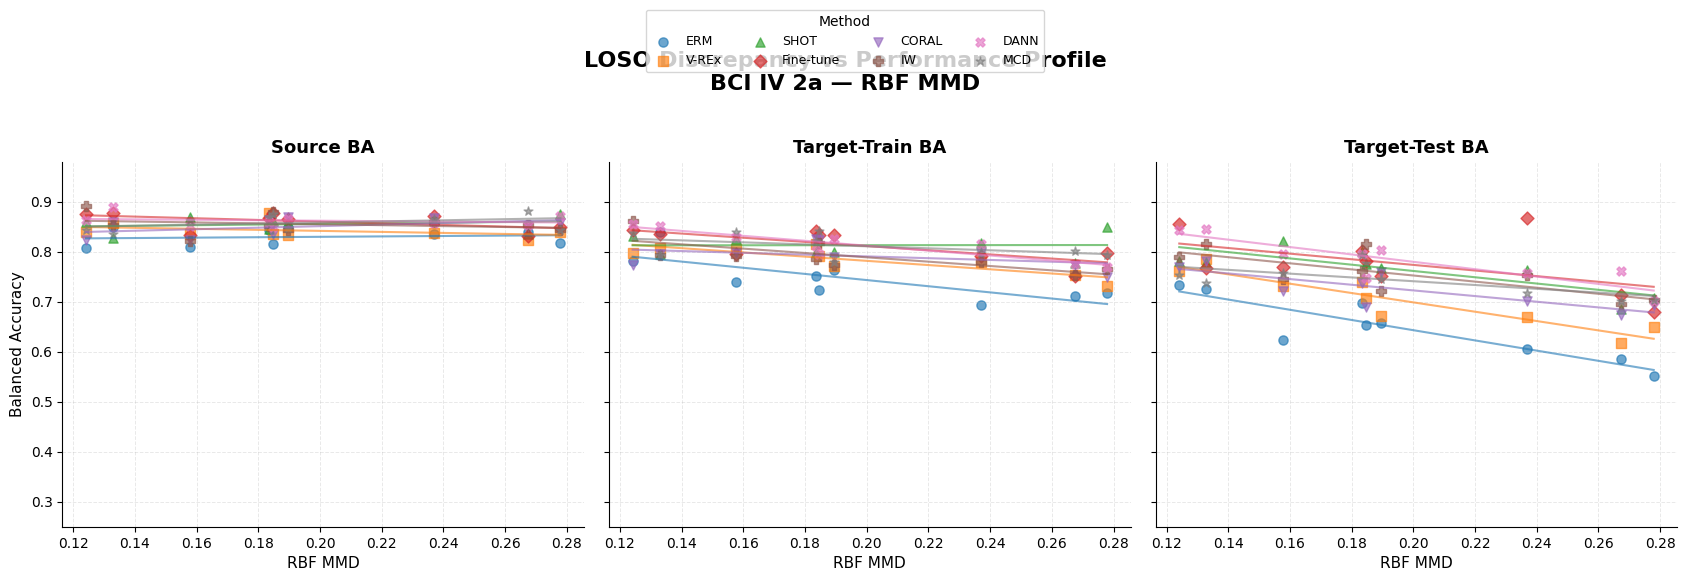

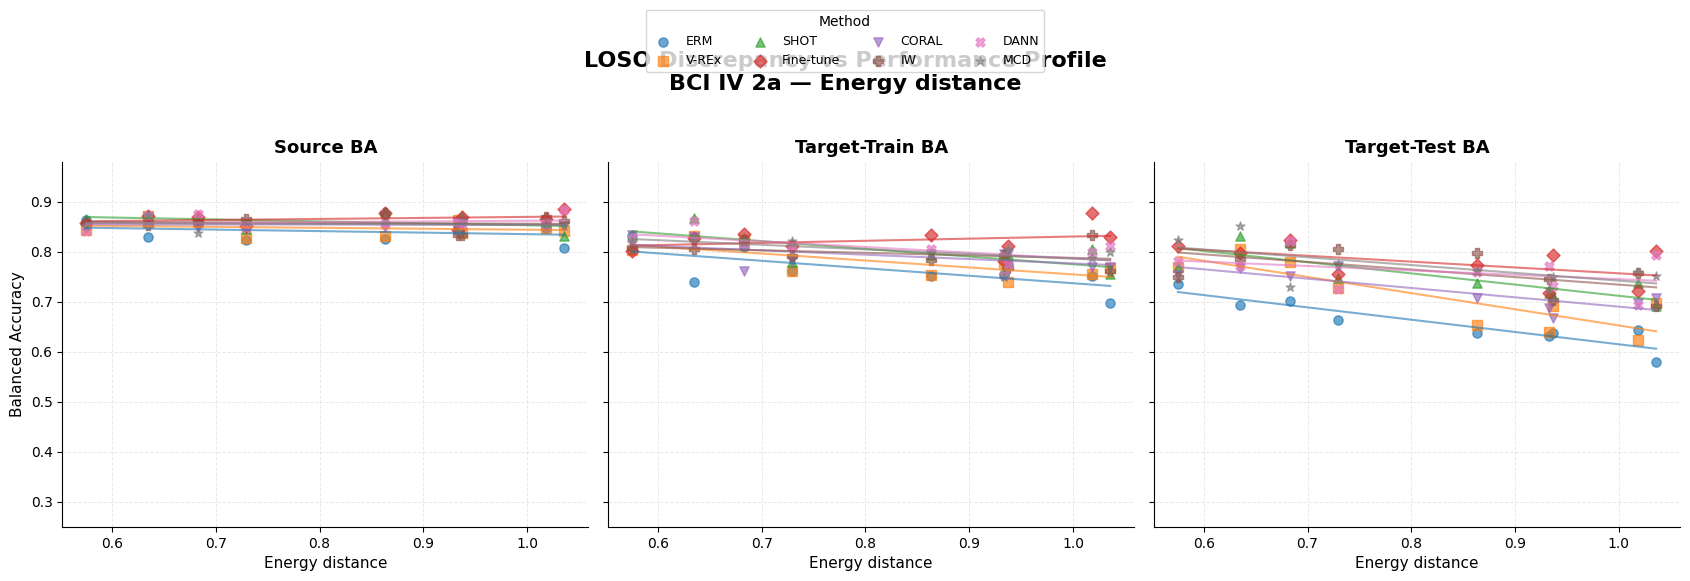

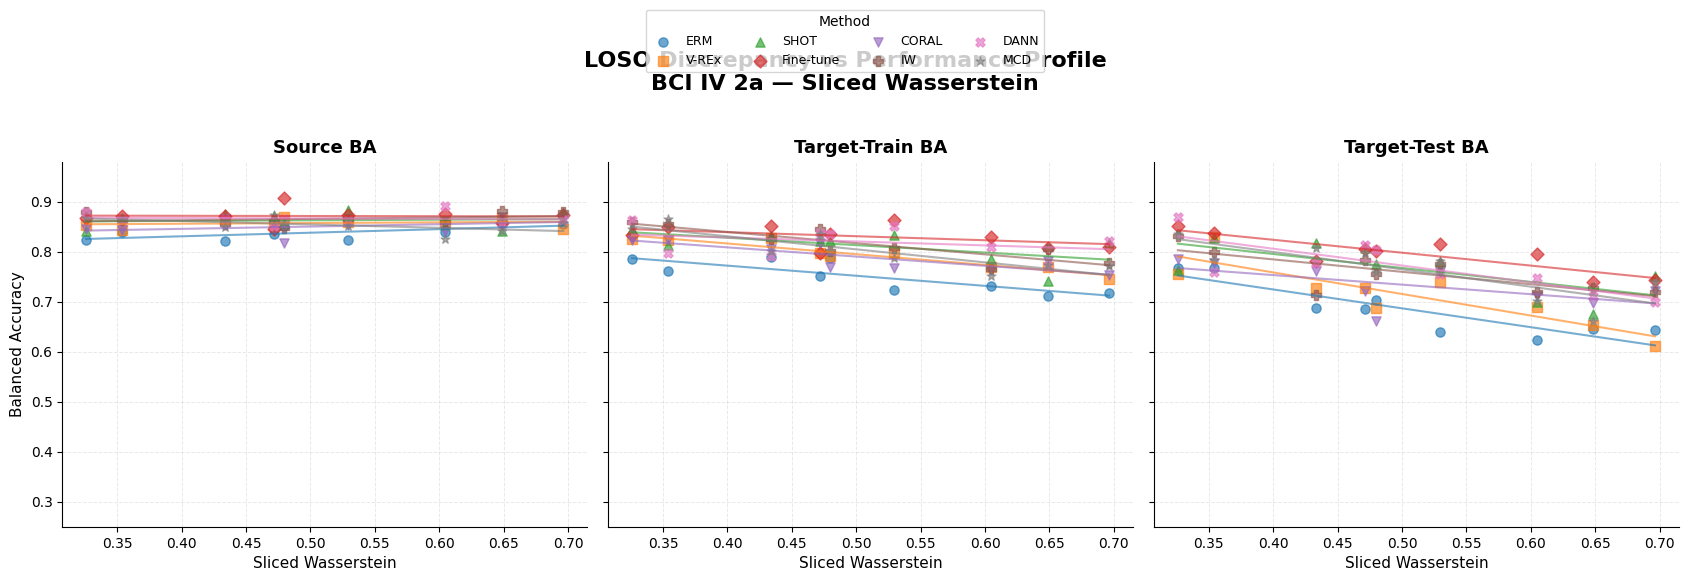

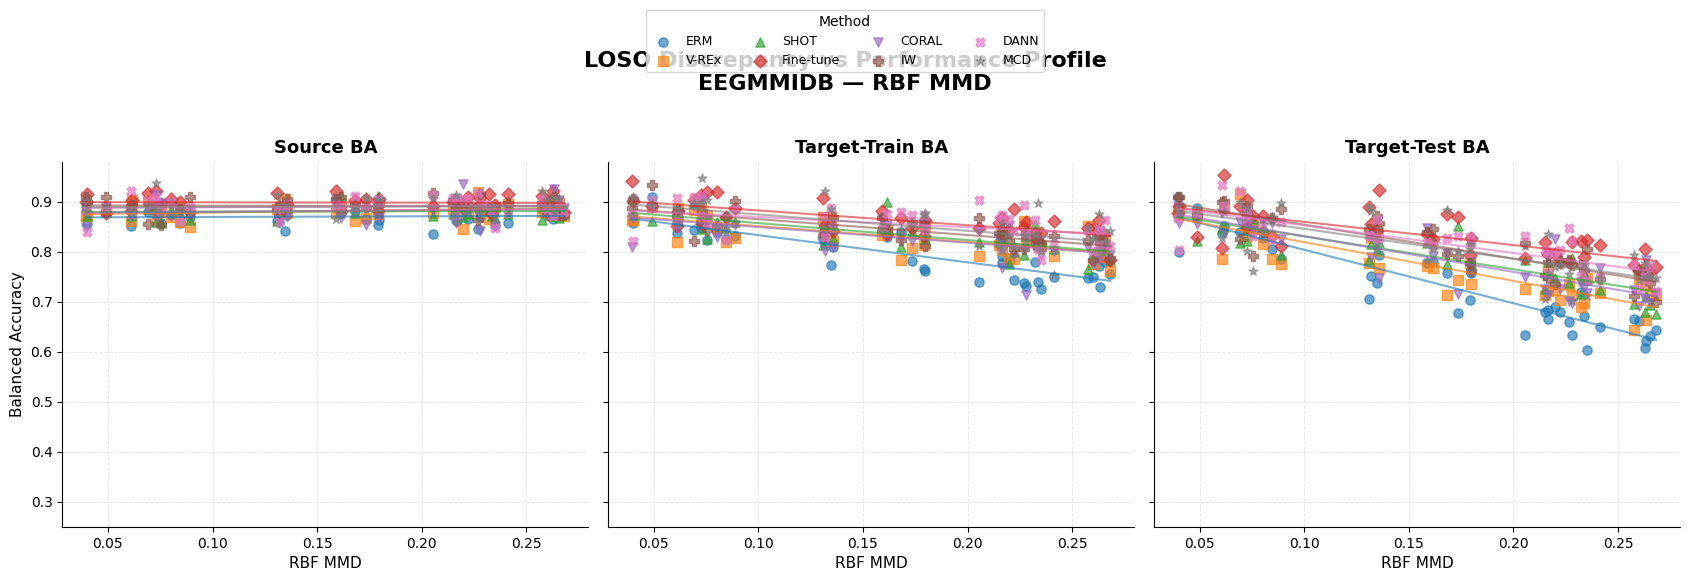

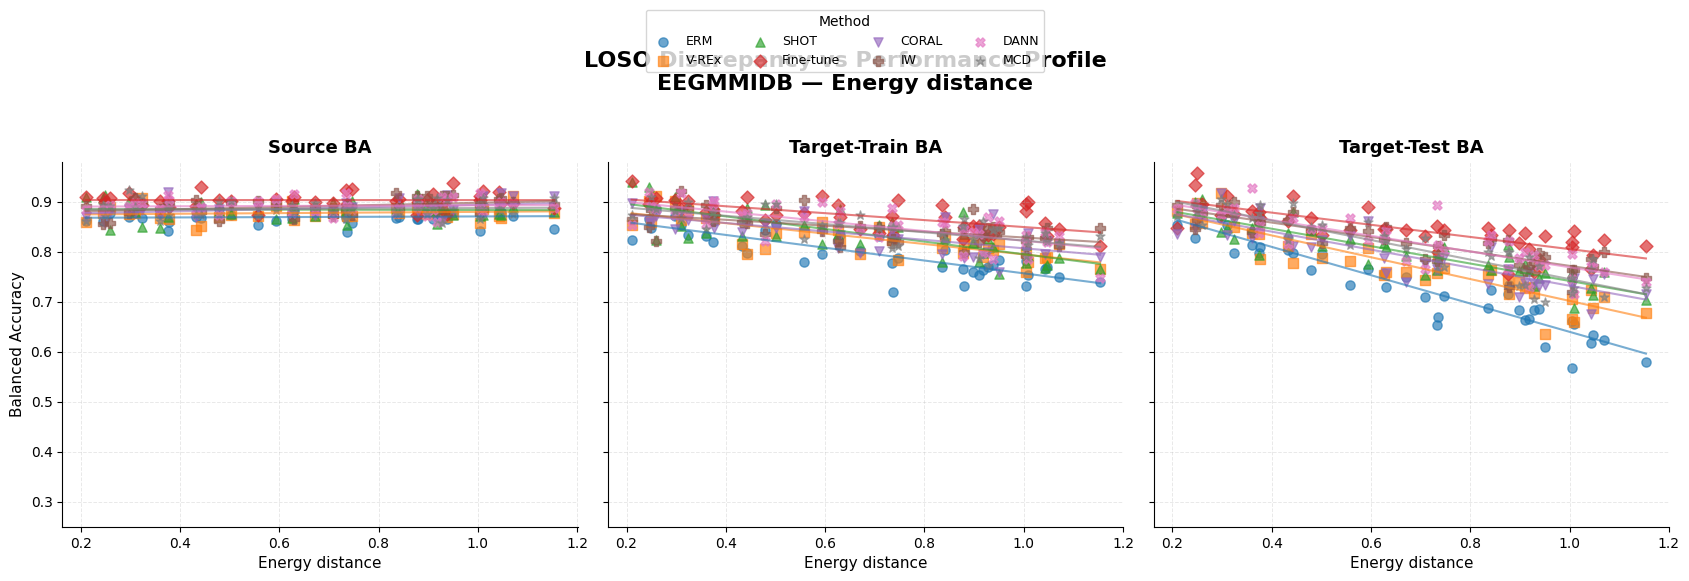

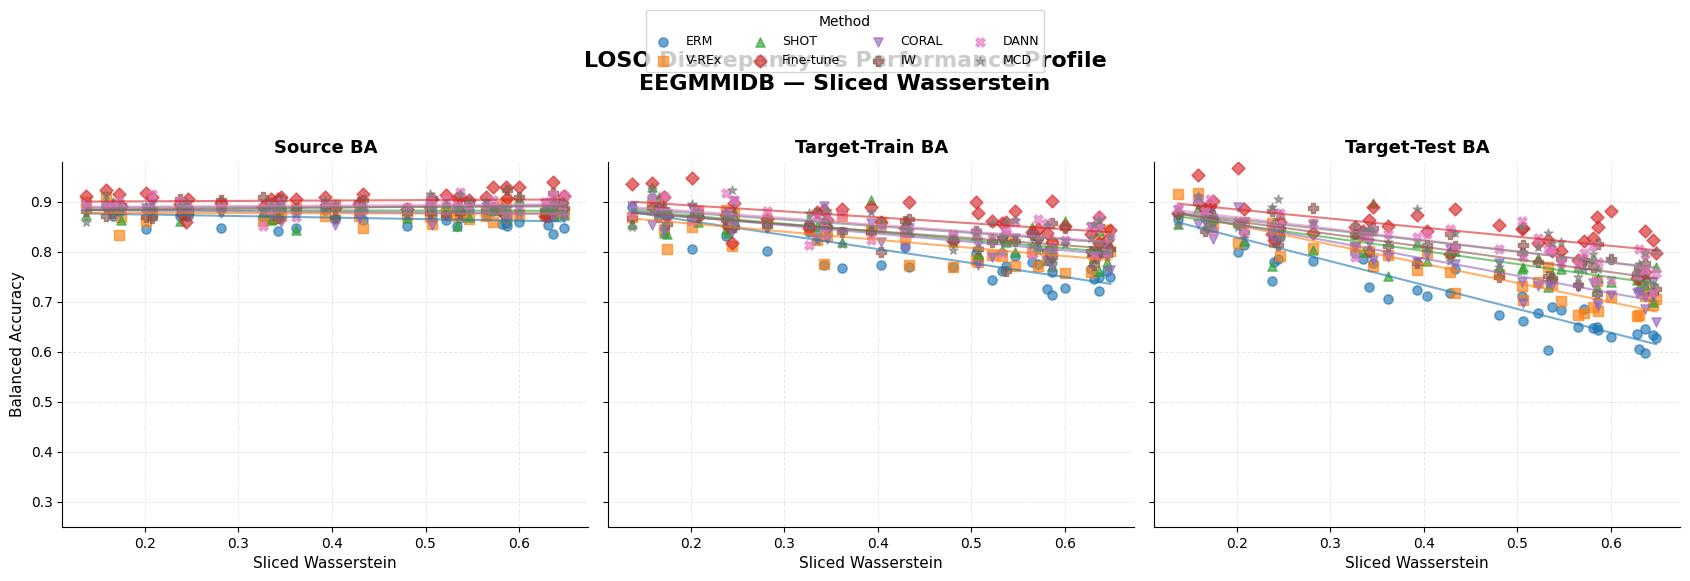

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Joint domain + learning analysis — Plot 3
# LOSO discrepancy vs performance profile
#
# Panels:
#   1) Source BA
#   2) Target-Train BA
#   3) Target-Test BA
#
# One point = one held-out subject for one method.
# Dummy data only, for figure design.
# ============================================================

rng = np.random.default_rng(2031)

methods = [
    "ERM",
    "V-REx",
    "SHOT",
    "Fine-tune",
    "CORAL",
    "IW",
    "DANN",
    "MCD",
]

datasets = {
    "BCI IV 2a": 9,
    "EEGMMIDB": 40,   # illustrative subset
}

distance_metrics = {
    "RBF MMD": (0.03, 0.30),
    "Energy distance": (0.20, 1.20),
    "Sliced Wasserstein": (0.10, 0.75),
}

# How strongly target-test degrades with shift
test_slope = {
    "ERM": 0.28,
    "V-REx": 0.22,
    "SHOT": 0.18,
    "Fine-tune": 0.13,
    "CORAL": 0.20,
    "IW": 0.17,
    "DANN": 0.15,
    "MCD": 0.16,
}

# Target-train is usually better than target-test
train_slope = {
    "ERM": 0.14,
    "V-REx": 0.11,
    "SHOT": 0.09,
    "Fine-tune": 0.07,
    "CORAL": 0.10,
    "IW": 0.09,
    "DANN": 0.08,
    "MCD": 0.08,
}

method_base = {
    "ERM": 0.00,
    "V-REx": 0.01,
    "SHOT": 0.015,
    "Fine-tune": 0.03,
    "CORAL": 0.012,
    "IW": 0.018,
    "DANN": 0.020,
    "MCD": 0.017,
}

# ============================================================
# Generate dummy results
# ============================================================

rows = []

for dataset, n_subjects in datasets.items():

    latent_shift = rng.uniform(0.05, 0.95, n_subjects)
    source_base = 0.84 if dataset == "BCI IV 2a" else 0.87

    for metric, (low, high) in distance_metrics.items():

        discrepancy = (
            low
            + latent_shift * (high - low)
            + rng.normal(0, 0.04 * (high - low), n_subjects)
        )
        discrepancy = np.clip(discrepancy, low, high)

        d_norm = (discrepancy - low) / (high - low)

        for method in methods:

            source_ba = (
                source_base
                + method_base[method]
                + rng.normal(0, 0.015, n_subjects)
            )

            target_train_ba = (
                source_ba
                - train_slope[method] * d_norm
                + rng.normal(0, 0.020, n_subjects)
            )

            target_test_ba = (
                source_ba
                - test_slope[method] * d_norm
                + rng.normal(0, 0.025, n_subjects)
            )

            target_train_ba = np.clip(target_train_ba, 0.30, 0.98)
            target_test_ba = np.clip(target_test_ba, 0.25, 0.98)

            for subject_idx in range(n_subjects):
                rows.append({
                    "dataset": dataset,
                    "subject": subject_idx + 1,
                    "metric": metric,
                    "method": method,
                    "discrepancy": discrepancy[subject_idx],
                    "source_ba": source_ba[subject_idx],
                    "target_train_ba": target_train_ba[subject_idx],
                    "target_test_ba": target_test_ba[subject_idx],
                })

df_profile = pd.DataFrame(rows)

# ============================================================
# Plotting helper
# ============================================================

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
performance_cols = [
    ("source_ba", "Source BA"),
    ("target_train_ba", "Target-Train BA"),
    ("target_test_ba", "Target-Test BA"),
]

# ============================================================
# Plot
# One figure per dataset × discrepancy metric
# ============================================================

for dataset in datasets:

    for metric in distance_metrics:

        current = df_profile[
            (df_profile["dataset"] == dataset) &
            (df_profile["metric"] == metric)
        ]

        fig, axes = plt.subplots(
            1, 3,
            figsize=(17, 5.2),
            sharex=True,
            sharey=True,
        )

        for ax, (col, title) in zip(axes, performance_cols):

            for method, marker in zip(methods, markers):

                sub = current[current["method"] == method]

                x = sub["discrepancy"].to_numpy()
                y = sub[col].to_numpy()

                scatter = ax.scatter(
                    x,
                    y,
                    marker=marker,
                    s=44,
                    alpha=0.65,
                    label=method,
                )

                if len(x) >= 2:
                    coef = np.polyfit(x, y, 1)
                    x_line = np.linspace(x.min(), x.max(), 100)
                    y_line = np.polyval(coef, x_line)

                    ax.plot(
                        x_line,
                        y_line,
                        linewidth=1.5,
                        alpha=0.60,
                        color=scatter.get_facecolor()[0],
                    )

            ax.set_title(title, fontsize=13, fontweight="bold")
            ax.set_xlabel(metric, fontsize=11)
            ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.28)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        axes[0].set_ylabel("Balanced Accuracy", fontsize=11)
        axes[0].set_ylim(0.25, 0.98)

        fig.suptitle(
            f"LOSO Discrepancy vs Performance Profile\n{dataset} — {metric}",
            fontsize=16,
            fontweight="bold",
            y=1.03,
        )

        handles, labels = axes[-1].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=4,
            frameon=True,
            bbox_to_anchor=(0.5, 1.12),
            fontsize=9,
            title="Method",
        )

        plt.tight_layout()
        plt.show()

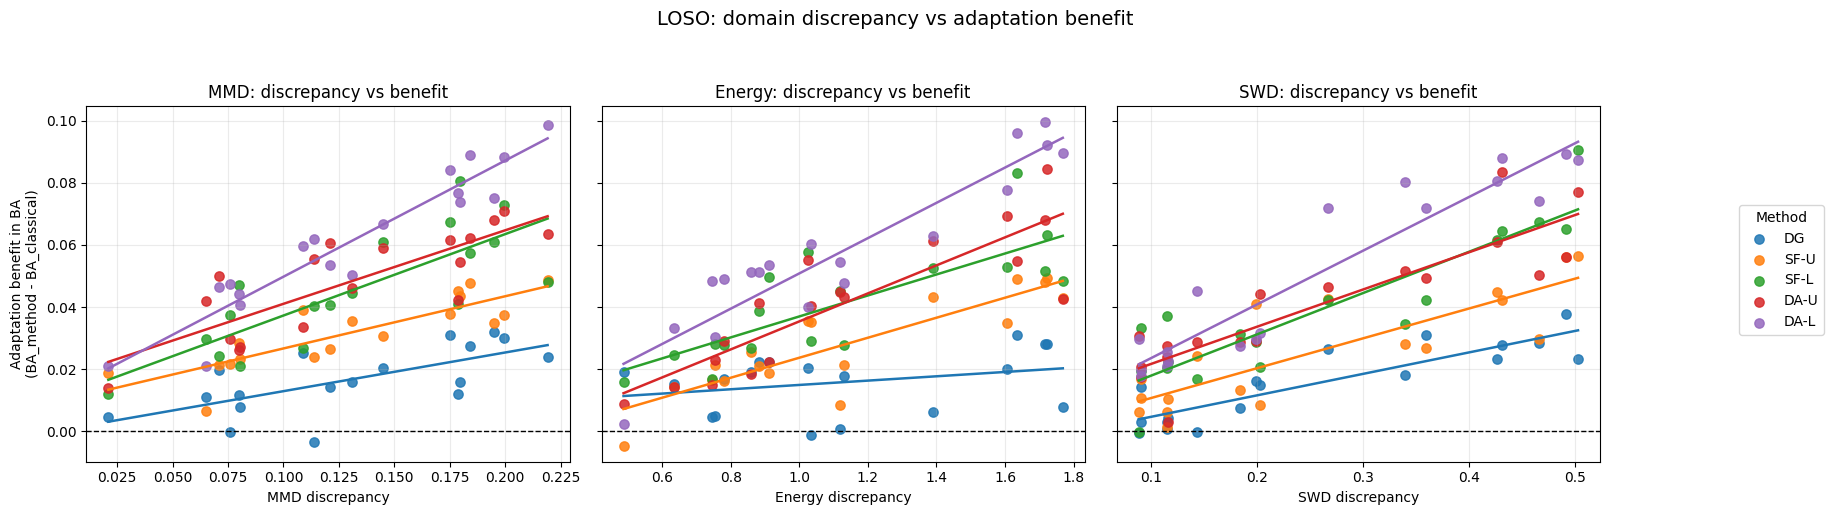

metric,Energy,MMD,SWD
method,,,
DA-L,0.928,0.950,0.942
DA-U,0.862,0.817,0.882
DG,0.297,0.674,0.875
SF-L,0.785,0.798,0.895
SF-U,0.864,0.841,0.833


In [95]:
# ============================================================
# Joint plot: discrepancy vs adaptation benefit
# Illustrative version with dummy data
# LOSO setting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dummy data generation
# ------------------------------------------------------------

rng = np.random.default_rng(7)

methods = [
    "domain_generalization",
    "source_free_unlabeled",
    "source_free_labeled",
    "domain_adaptation_unlabeled",
    "domain_adaptation_labeled",
]

method_labels = {
    "domain_generalization": "DG",
    "source_free_unlabeled": "SF-U",
    "source_free_labeled": "SF-L",
    "domain_adaptation_unlabeled": "DA-U",
    "domain_adaptation_labeled": "DA-L",
}

metric_specs = {
    "MMD": (0.02, 0.22),
    "Energy": (0.20, 1.80),
    "SWD": (0.05, 0.55),
}

n_domains = 18

rows = []

for metric_name, (low, high) in metric_specs.items():

    discrepancy_values = np.sort(
        rng.uniform(low, high, size=n_domains)
    )

    # Simulated classical performance drops slightly as discrepancy increases
    discrepancy_norm = (
        discrepancy_values - discrepancy_values.min()
    ) / (
        discrepancy_values.max() - discrepancy_values.min() + 1e-12
    )

    classical_ba = (
        0.74
        - 0.10 * discrepancy_norm
        + rng.normal(0, 0.01, size=n_domains)
    )

    for i, discrepancy_value in enumerate(discrepancy_values):

        rows.append({
            "target_domain": f"D{i+1:02d}",
            "metric": metric_name,
            "method": "classical",
            "discrepancy": discrepancy_value,
            "ba": classical_ba[i],
            "adaptation_benefit": 0.0,
        })

        # Different methods gain different amounts as discrepancy increases
        method_params = {
            "domain_generalization":         {"base": 0.005, "slope": 0.025, "noise": 0.010},
            "source_free_unlabeled":         {"base": 0.010, "slope": 0.040, "noise": 0.010},
            "source_free_labeled":           {"base": 0.018, "slope": 0.050, "noise": 0.010},
            "domain_adaptation_unlabeled":   {"base": 0.015, "slope": 0.060, "noise": 0.010},
            "domain_adaptation_labeled":     {"base": 0.020, "slope": 0.075, "noise": 0.010},
        }

        for method_name, params in method_params.items():
            benefit = (
                params["base"]
                + params["slope"] * discrepancy_norm[i]
                + rng.normal(0, params["noise"])
            )

            benefit = max(benefit, -0.01)

            rows.append({
                "target_domain": f"D{i+1:02d}",
                "metric": metric_name,
                "method": method_name,
                "discrepancy": discrepancy_value,
                "ba": classical_ba[i] + benefit,
                "adaptation_benefit": benefit,
            })

results_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_df = results_df[
    results_df["method"] != "classical"
].copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True,
)

for ax, metric_name in zip(axes, metric_specs.keys()):

    metric_df = plot_df[
        plot_df["metric"] == metric_name
    ].copy()

    for method_name in methods:
        method_df = metric_df[
            metric_df["method"] == method_name
        ].copy()

        ax.scatter(
            method_df["discrepancy"],
            method_df["adaptation_benefit"],
            s=45,
            alpha=0.85,
            label=method_labels[method_name],
        )

        # Simple linear tendency line
        if len(method_df) >= 2:
            coeffs = np.polyfit(
                method_df["discrepancy"],
                method_df["adaptation_benefit"],
                deg=1,
            )

            x_line = np.linspace(
                method_df["discrepancy"].min(),
                method_df["discrepancy"].max(),
                100,
            )

            y_line = coeffs[0] * x_line + coeffs[1]

            ax.plot(
                x_line,
                y_line,
                linewidth=1.8,
            )

    ax.axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_title(
        f"{metric_name}: discrepancy vs benefit"
    )
    ax.set_xlabel(f"{metric_name} discrepancy")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(
    "Adaptation benefit in BA\n(BA_method - BA_classical)"
)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Method",
)

fig.suptitle(
    "LOSO: domain discrepancy vs adaptation benefit",
    fontsize=14,
    y=1.02,
)

fig.tight_layout(
    rect=[0, 0, 0.90, 0.97]
)

plt.show()

# ------------------------------------------------------------
# Optional correlation summary
# ------------------------------------------------------------

summary_rows = []

for metric_name in metric_specs.keys():
    for method_name in methods:
        aux = plot_df[
            (plot_df["metric"] == metric_name)
            & (plot_df["method"] == method_name)
        ]

        r = aux["discrepancy"].corr(
            aux["adaptation_benefit"]
        )

        summary_rows.append({
            "metric": metric_name,
            "method": method_labels[method_name],
            "pearson_r": r,
        })

correlation_df = pd.DataFrame(summary_rows)

display(
    correlation_df
    .pivot(
        index="method",
        columns="metric",
        values="pearson_r",
    )
    .round(3)
)